In [1]:
# %% ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import ks_2samp, chi2_contingency
from sklearn.metrics import accuracy_score
from sklearn.kernel_ridge import KernelRidge
import os
import matplotlib.colors as mcolors

def get_palette(names):
    # AA系は青系、CC系はオレンジ系でグラデーション
    aa_colors = sns.color_palette("Blues", n_colors=sum([n.startswith("AA") for n in names]))
    cc_colors = sns.color_palette("Oranges", n_colors=sum([n.startswith("CC") for n in names]))
    palette = {}
    aa_idx, cc_idx = 0, 0
    for name in names:
        if name.startswith("AA"):
            palette[name] = aa_colors[aa_idx]
            aa_idx += 1
        elif name.startswith("CC"):
            palette[name] = cc_colors[cc_idx]
            cc_idx += 1
        else:
            palette[name] = "#2ca02c"  # その他（緑系）
    return palette


In [2]:
input_dir = os.path.join("in", "PWSCUP2025_Main_Data_for_Attack")
files = []
for id in range(1, 25):
    if id == 21:
        continue
    aa = f"AA{id:02d}.csv"
    cc = f"CC{id:02d}.csv"
    if aa in os.listdir(input_dir) and cc in os.listdir(input_dir):
        files.append((aa, cc))

result = []
for aa, cc in files:
    result.append(os.path.join(input_dir, aa))
    result.append(os.path.join(input_dir, cc))

if not result:
    raise FileNotFoundError("No AA/CC CSV pairs found in in/PWSCUP2025_Main_Data_for_Attack.")


In [3]:
result

['in\\PWSCUP2025_Main_Data_for_Attack\\AA01.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC01.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA02.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC02.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA03.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC03.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA04.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC04.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA05.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC05.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA06.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC06.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA07.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC07.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA08.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC08.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA09.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC09.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA10.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\CC10.csv',


In [4]:
MAX_SAMPLE_PER_DATASET = 5000

# データセットのロード部分もペアで管理
datasets = []
dataset_names = []
for aa, cc in files:
    df_aa = pd.read_csv(os.path.join(input_dir, aa))
    df_cc = pd.read_csv(os.path.join(input_dir, cc))
    if MAX_SAMPLE_PER_DATASET is not None and len(df_aa) > MAX_SAMPLE_PER_DATASET:
        df_aa = df_aa.sample(n=MAX_SAMPLE_PER_DATASET, random_state=42)
    if MAX_SAMPLE_PER_DATASET is not None and len(df_cc) > MAX_SAMPLE_PER_DATASET:
        df_cc = df_cc.sample(n=MAX_SAMPLE_PER_DATASET, random_state=42)
    datasets.append((df_aa.reset_index(drop=True), df_cc.reset_index(drop=True)))
    dataset_names.append((os.path.splitext(aa)[0], os.path.splitext(cc)[0]))

if not datasets:
    raise ValueError("No AA/CC dataset pairs were loaded. Confirm that the file list is correct.")



=== AA01: 基本統計量 ===
       GENDER         AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.00000   5000         5000      5000.000000   
unique      2         NaN      6            2              NaN   
top         M         NaN  white  nonhispanic              NaN   
freq     2639         NaN   4391         3878              NaN   
mean      NaN    46.55280    NaN          NaN        61.691200   
std       NaN    25.57814    NaN          NaN        94.180762   
min       NaN     2.00000    NaN          NaN         8.000000   
25%       NaN    23.00000    NaN          NaN        25.000000   
50%       NaN    49.00000    NaN          NaN        36.000000   
75%       NaN    64.00000    NaN          NaN        58.000000   
max       NaN   110.00000    NaN          NaN       874.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             NaN          

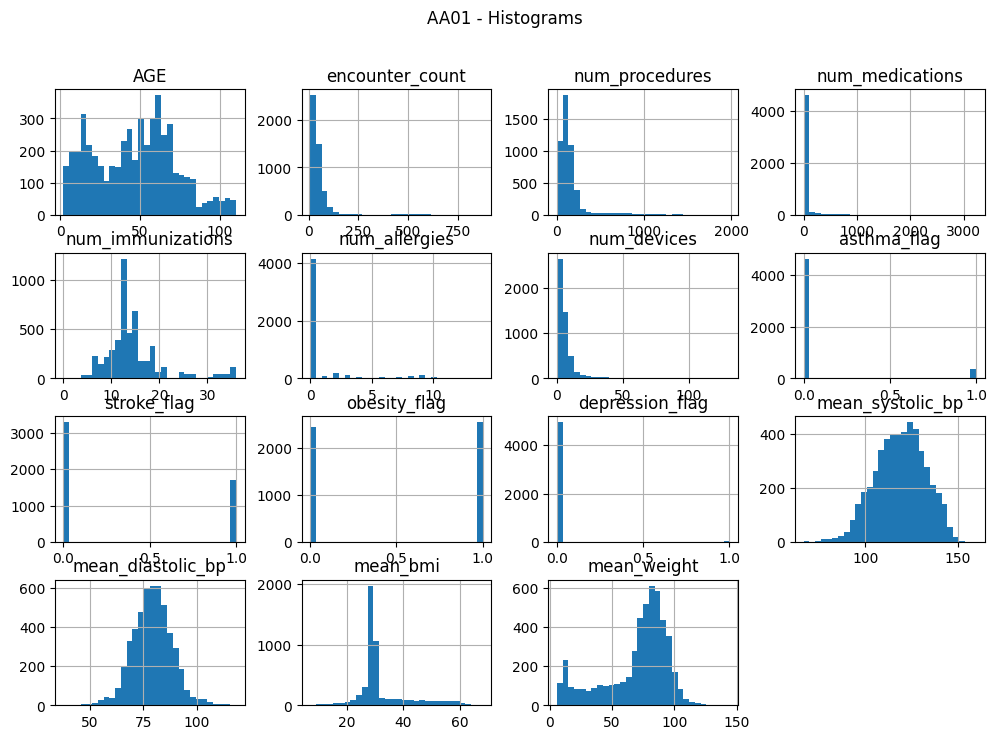


=== CC01: 基本統計量 ===
       GENDER         AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.00000   5000         5000      5000.000000   
unique      2         NaN      6            2              NaN   
top         M         NaN  white  nonhispanic              NaN   
freq     2528         NaN   4335         3727              NaN   
mean      NaN    47.04320    NaN          NaN        61.415600   
std       NaN    25.54251    NaN          NaN        91.255604   
min       NaN     2.00000    NaN          NaN         6.000000   
25%       NaN    26.00000    NaN          NaN        26.000000   
50%       NaN    48.00000    NaN          NaN        38.000000   
75%       NaN    66.00000    NaN          NaN        60.000000   
max       NaN   110.00000    NaN          NaN       914.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             NaN          

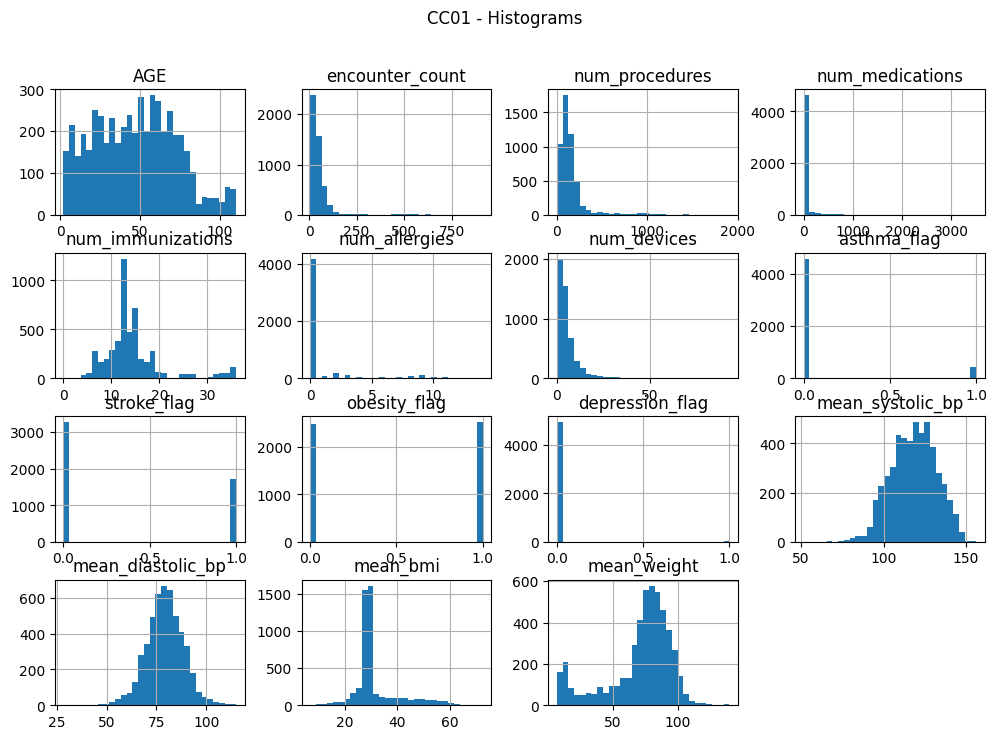


=== AA02: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2578          NaN   3688         4895              NaN   
mean      NaN    45.936400    NaN          NaN        63.417600   
std       NaN    27.067325    NaN          NaN        96.436578   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    22.000000    NaN          NaN        25.000000   
50%       NaN    47.000000    NaN          NaN        37.000000   
75%       NaN    66.000000    NaN          NaN        61.000000   
max       NaN   110.000000    NaN          NaN       862.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

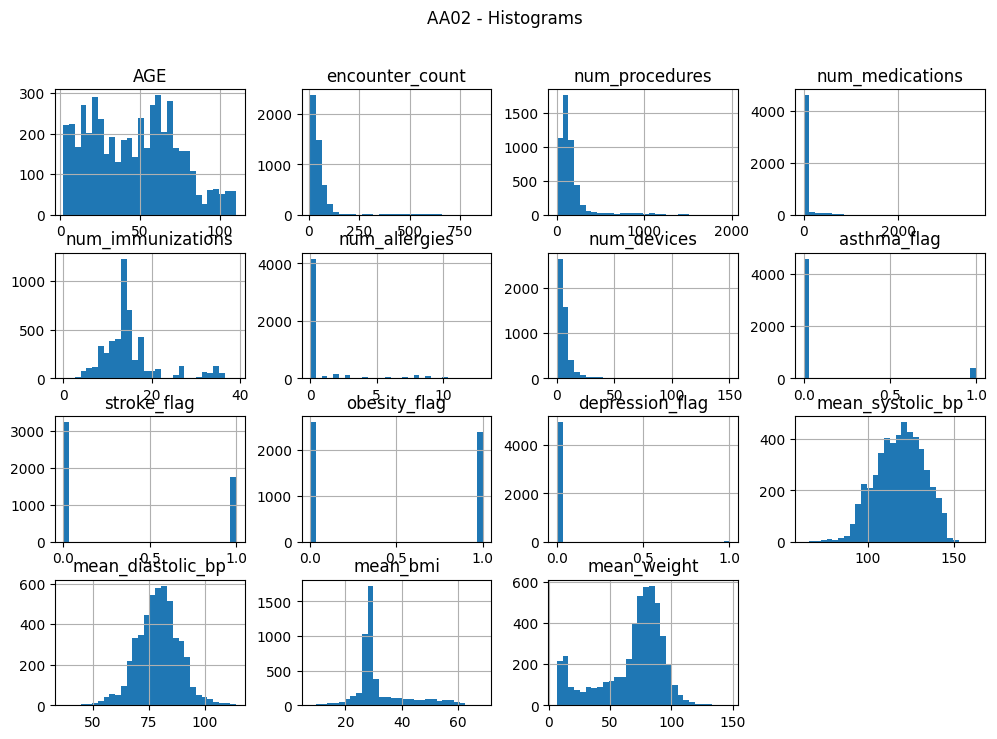


=== CC02: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2608          NaN   3677         4869              NaN   
mean      NaN    45.076200    NaN          NaN        62.731200   
std       NaN    26.484446    NaN          NaN        97.233411   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    21.000000    NaN          NaN        24.000000   
50%       NaN    45.000000    NaN          NaN        36.000000   
75%       NaN    65.000000    NaN          NaN        59.000000   
max       NaN   110.000000    NaN          NaN      1202.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000     5000.00000   
unique             N

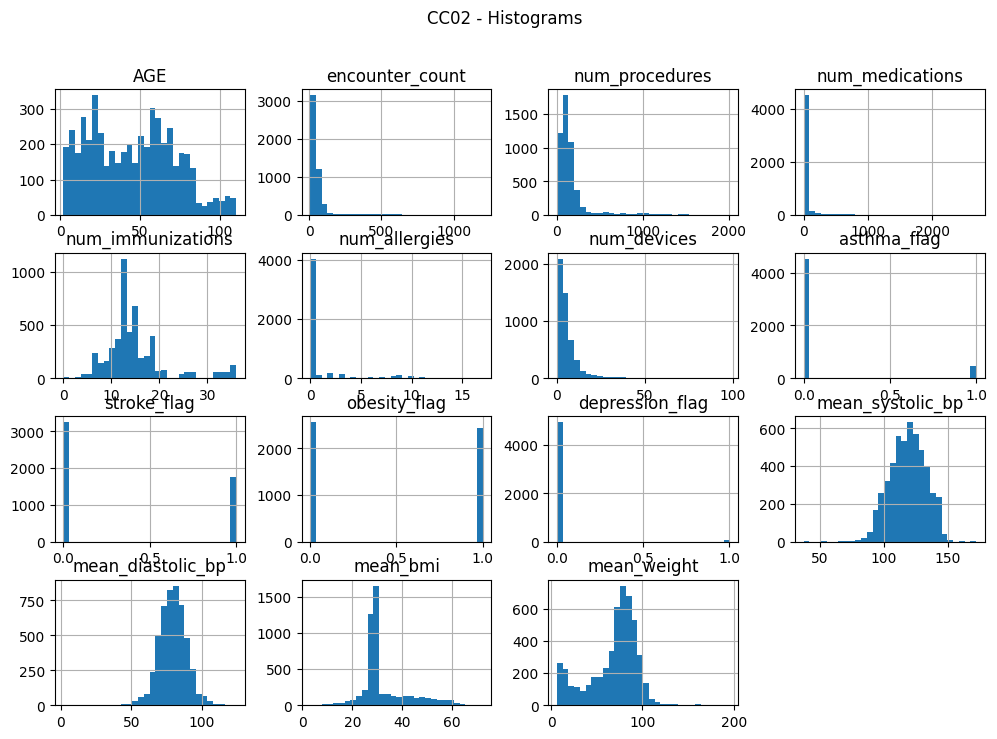


=== AA03: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2676          NaN   4761         4899              NaN   
mean      NaN    47.642000    NaN          NaN         63.38060   
std       NaN    25.719598    NaN          NaN         95.64737   
min       NaN     2.000000    NaN          NaN          8.00000   
25%       NaN    26.000000    NaN          NaN         25.00000   
50%       NaN    50.000000    NaN          NaN         37.00000   
75%       NaN    65.000000    NaN          NaN         60.00000   
max       NaN   110.000000    NaN          NaN        888.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

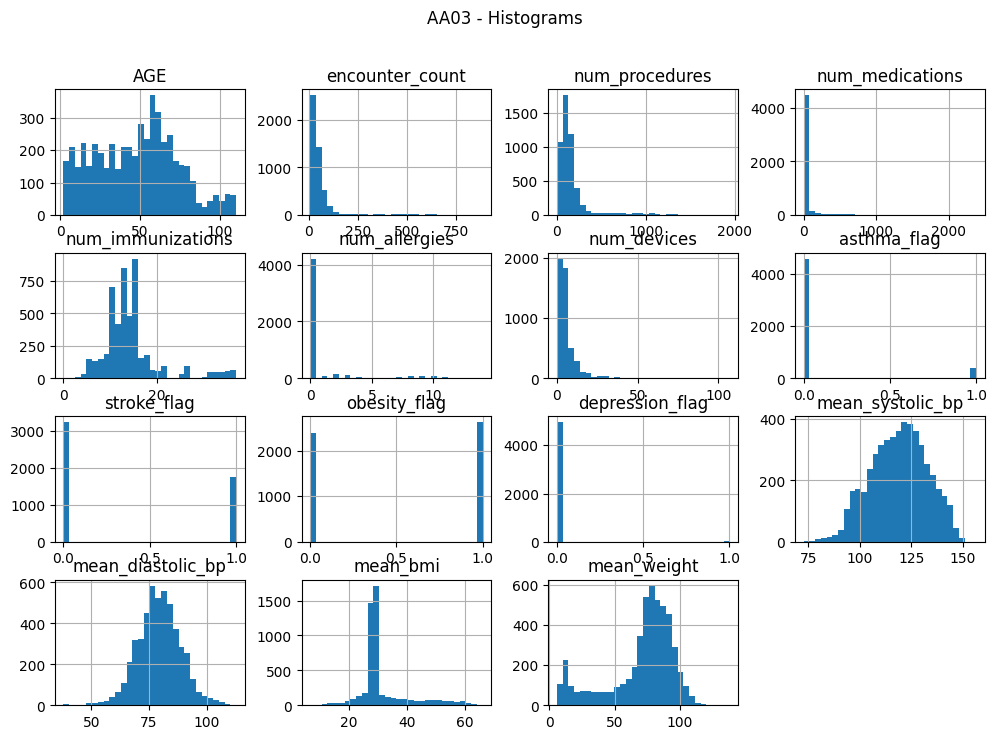


=== CC03: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2611          NaN   4768         4891              NaN   
mean      NaN    47.438800    NaN          NaN        64.090200   
std       NaN    25.771028    NaN          NaN        73.168756   
min       NaN     2.000000    NaN          NaN        10.000000   
25%       NaN    26.000000    NaN          NaN        29.000000   
50%       NaN    49.000000    NaN          NaN        42.000000   
75%       NaN    66.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       778.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

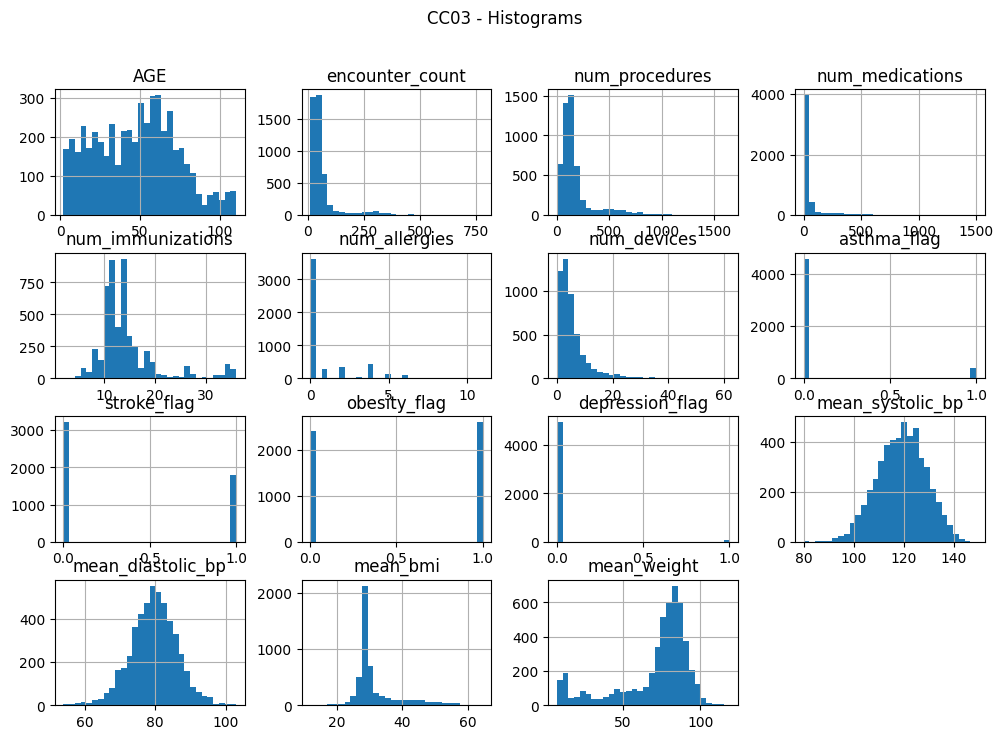


=== AA04: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2574          NaN   4436         4742              NaN   
mean      NaN    56.143000    NaN          NaN        75.604800   
std       NaN    26.934573    NaN          NaN       113.297113   
min       NaN     2.000000    NaN          NaN         9.000000   
25%       NaN    38.000000    NaN          NaN        29.000000   
50%       NaN    62.000000    NaN          NaN        42.000000   
75%       NaN    74.000000    NaN          NaN        67.000000   
max       NaN   110.000000    NaN          NaN       814.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

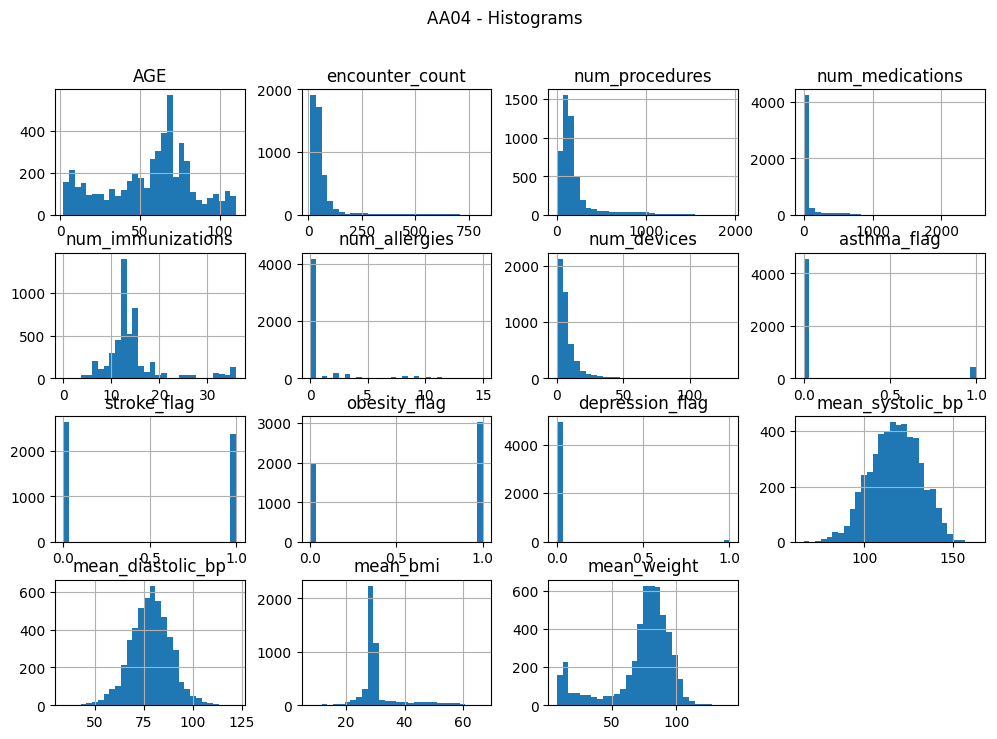


=== CC04: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2563          NaN   4159         4223              NaN   
mean      NaN    53.327600    NaN          NaN         79.75000   
std       NaN    27.584758    NaN          NaN        119.70332   
min       NaN     2.000000    NaN          NaN          7.00000   
25%       NaN    32.000000    NaN          NaN         28.00000   
50%       NaN    53.000000    NaN          NaN         41.00000   
75%       NaN    71.000000    NaN          NaN         69.00000   
max       NaN   110.000000    NaN          NaN        860.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

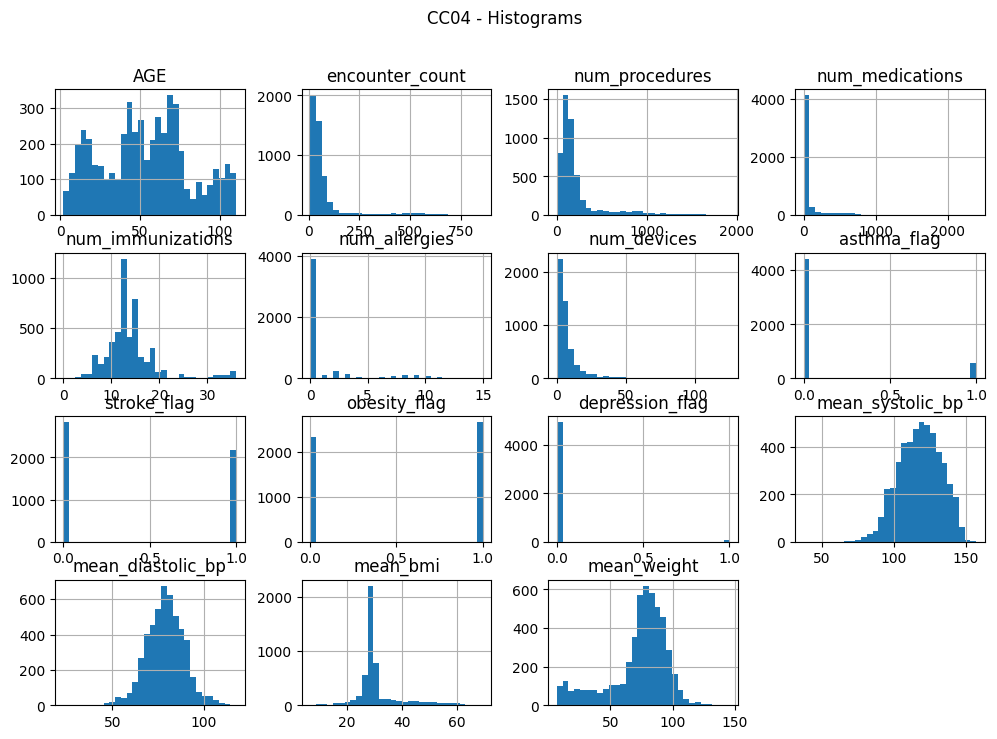


=== AA05: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2573          NaN   4822         4919              NaN   
mean      NaN    47.036600    NaN          NaN        63.372000   
std       NaN    25.913154    NaN          NaN        95.230652   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    25.000000    NaN          NaN        25.000000   
50%       NaN    49.000000    NaN          NaN        37.000000   
75%       NaN    65.000000    NaN          NaN        61.000000   
max       NaN   110.000000    NaN          NaN       797.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

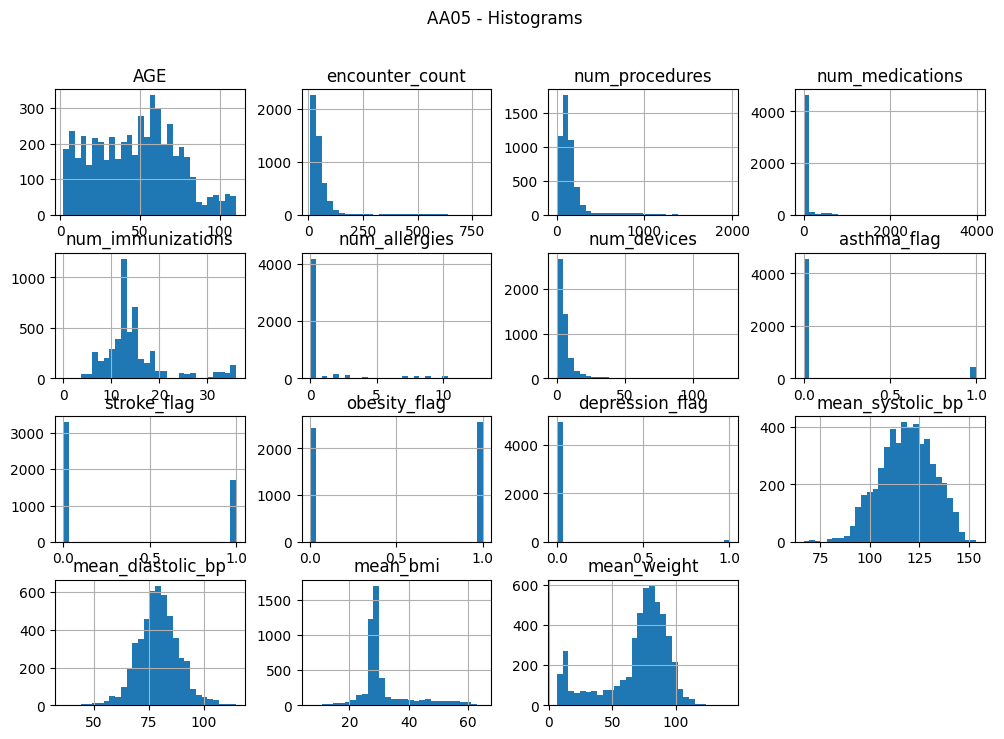


=== CC05: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2544          NaN   4837         4862              NaN   
mean      NaN    48.385000    NaN          NaN        63.939800   
std       NaN    25.946865    NaN          NaN        95.075404   
min       NaN     2.000000    NaN          NaN         4.000000   
25%       NaN    26.000000    NaN          NaN        26.000000   
50%       NaN    52.000000    NaN          NaN        39.000000   
75%       NaN    67.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       825.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000         5000.00000    5000.000000   
unique             N

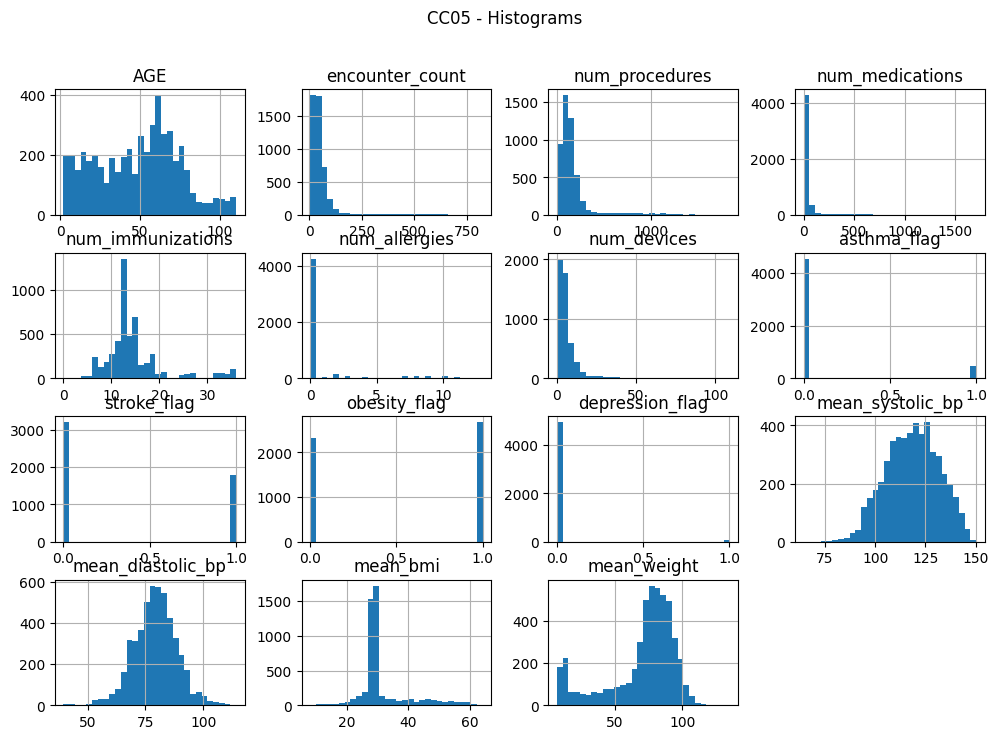


=== AA06: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2545          NaN   3970         4767              NaN   
mean      NaN    43.540400    NaN          NaN        59.956800   
std       NaN    25.866035    NaN          NaN        94.175241   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    22.000000    NaN          NaN        24.000000   
50%       NaN    42.000000    NaN          NaN        35.000000   
75%       NaN    62.000000    NaN          NaN        56.000000   
max       NaN   110.000000    NaN          NaN       921.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

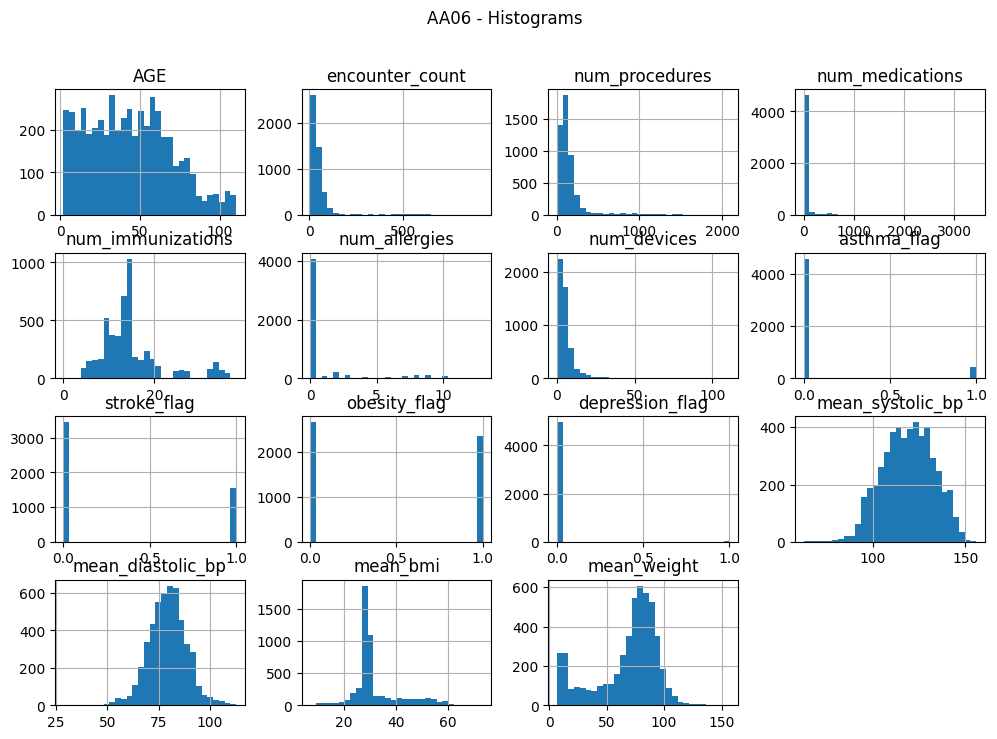


=== CC06: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2520          NaN   4029         4776              NaN   
mean      NaN    42.634800    NaN          NaN        56.286800   
std       NaN    25.569791    NaN          NaN        84.971031   
min       NaN     2.000000    NaN          NaN         4.000000   
25%       NaN    22.000000    NaN          NaN        23.000000   
50%       NaN    41.000000    NaN          NaN        35.000000   
75%       NaN    61.000000    NaN          NaN        56.000000   
max       NaN   110.000000    NaN          NaN       832.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

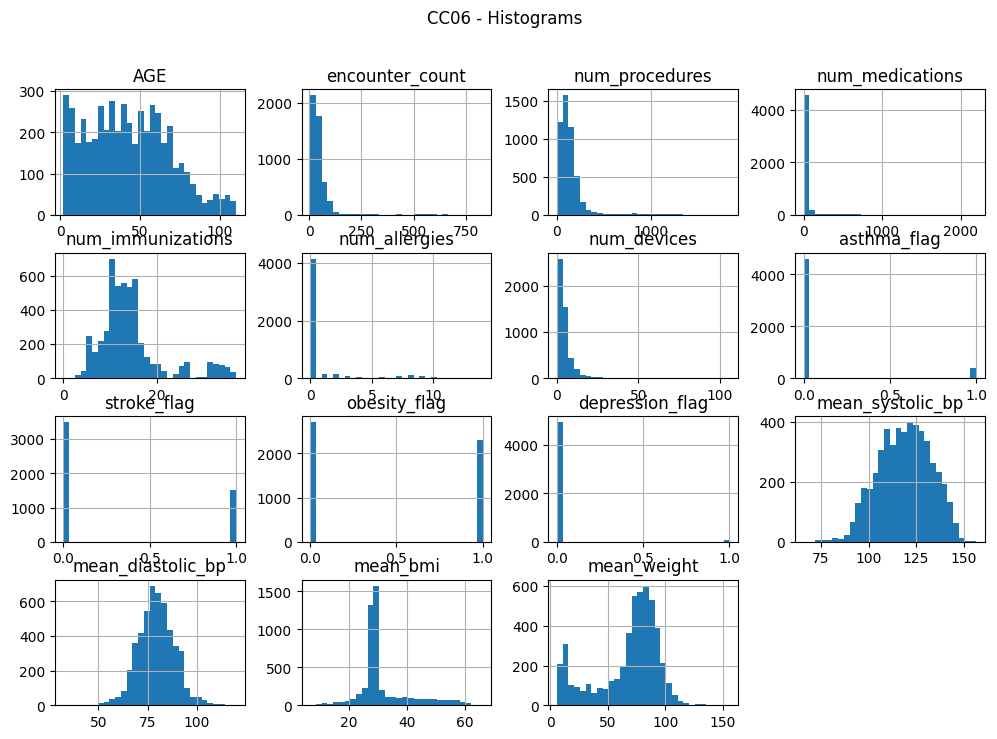


=== AA07: 基本統計量 ===
       GENDER         AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.00000   5000         5000      5000.000000   
unique      2         NaN      6            2              NaN   
top         M         NaN  white  nonhispanic              NaN   
freq     2594         NaN   4417         4664              NaN   
mean      NaN    48.76520    NaN          NaN        67.135600   
std       NaN    25.17239    NaN          NaN        98.673535   
min       NaN     2.00000    NaN          NaN         8.000000   
25%       NaN    29.00000    NaN          NaN        26.000000   
50%       NaN    51.00000    NaN          NaN        40.000000   
75%       NaN    66.00000    NaN          NaN        66.000000   
max       NaN   110.00000    NaN          NaN       829.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             NaN          

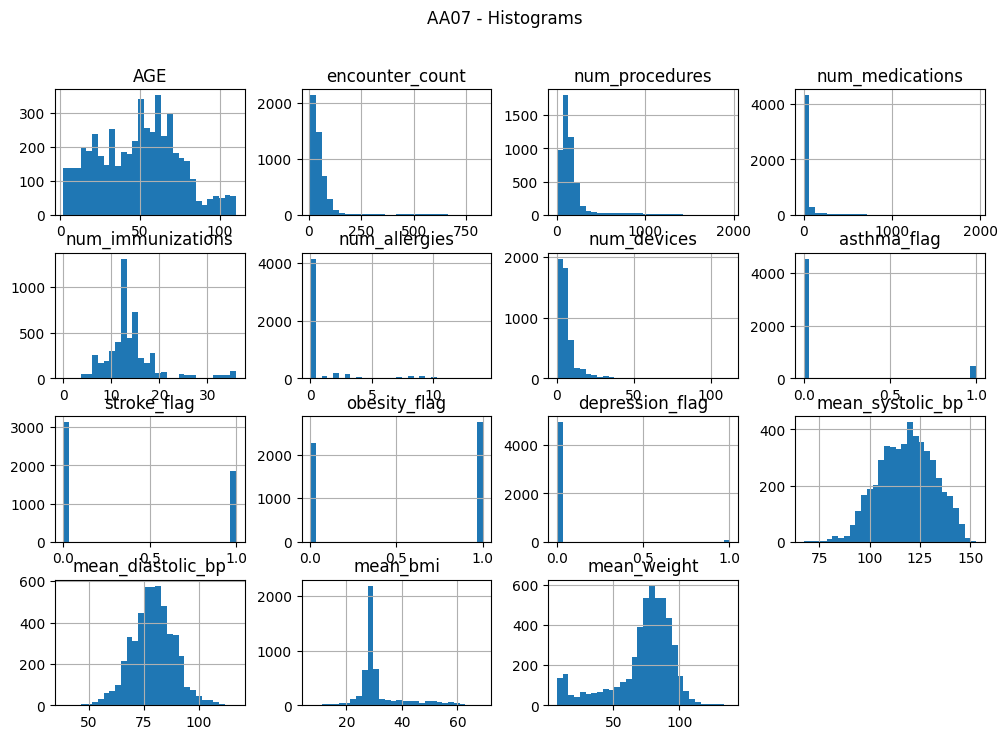


=== CC07: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2556          NaN   4375         4645              NaN   
mean      NaN    49.237400    NaN          NaN        65.760400   
std       NaN    25.124571    NaN          NaN        93.209046   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    28.000000    NaN          NaN        27.000000   
50%       NaN    51.000000    NaN          NaN        40.000000   
75%       NaN    67.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       859.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

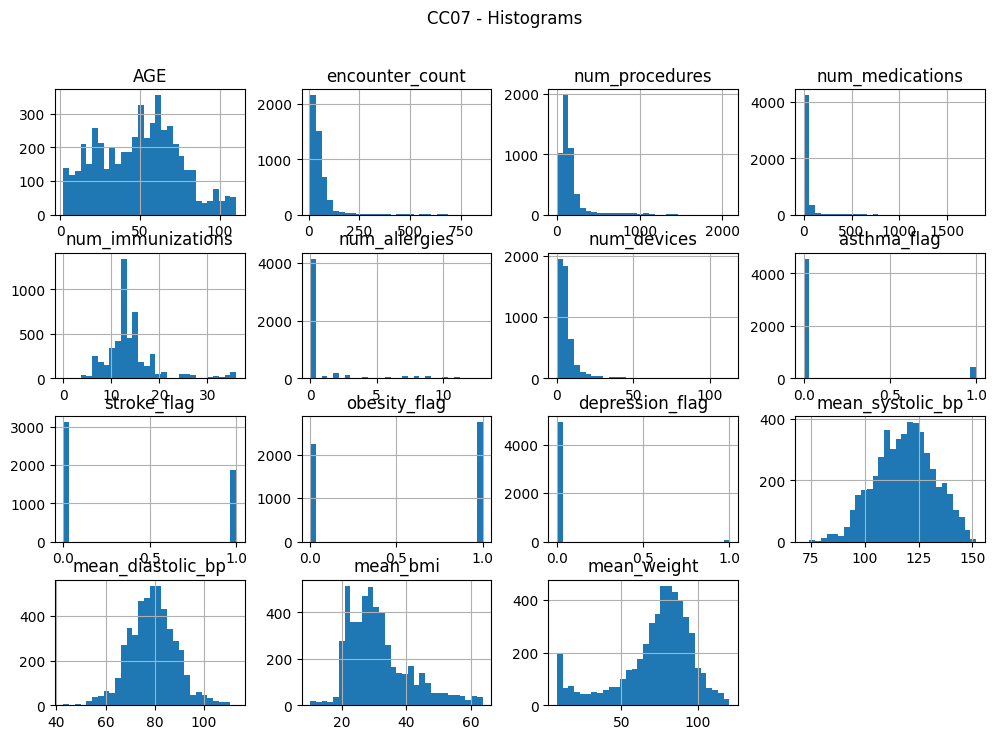


=== AA08: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2555          NaN   4498         4819              NaN   
mean      NaN    47.720200    NaN          NaN        65.923800   
std       NaN    26.154157    NaN          NaN        94.213239   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    26.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        40.000000   
75%       NaN    67.000000    NaN          NaN        67.000000   
max       NaN   110.000000    NaN          NaN       840.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

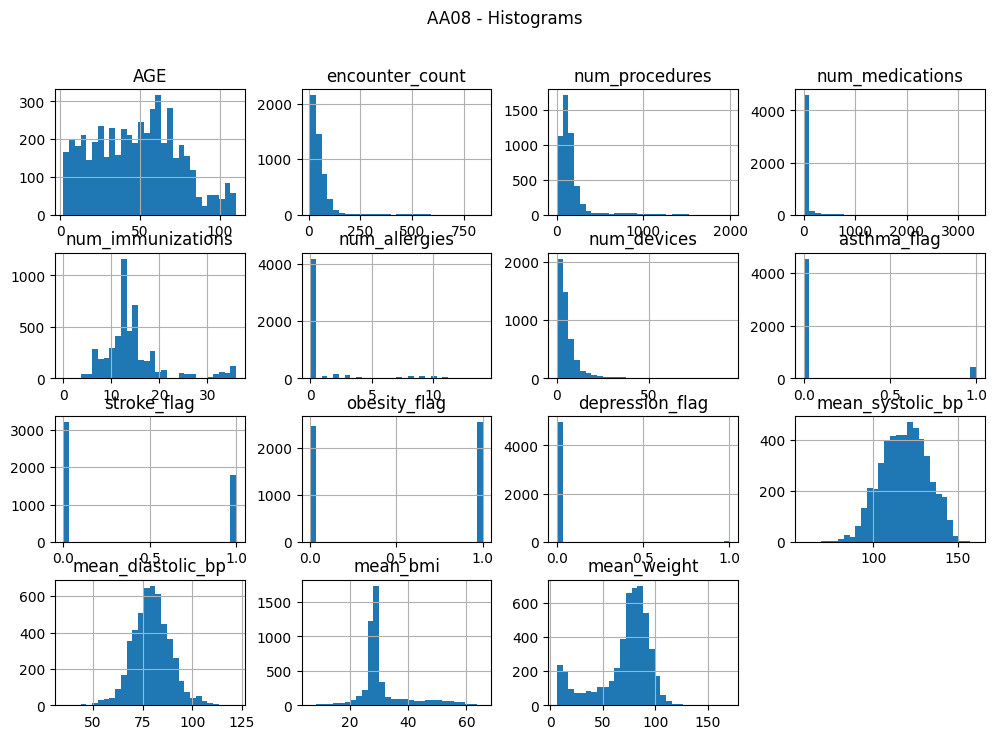


=== CC08: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2597          NaN   4241         4644              NaN   
mean      NaN    51.800800    NaN          NaN        71.140000   
std       NaN    26.294832    NaN          NaN       106.531983   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    31.750000    NaN          NaN        27.000000   
50%       NaN    55.000000    NaN          NaN        41.000000   
75%       NaN    70.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       959.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

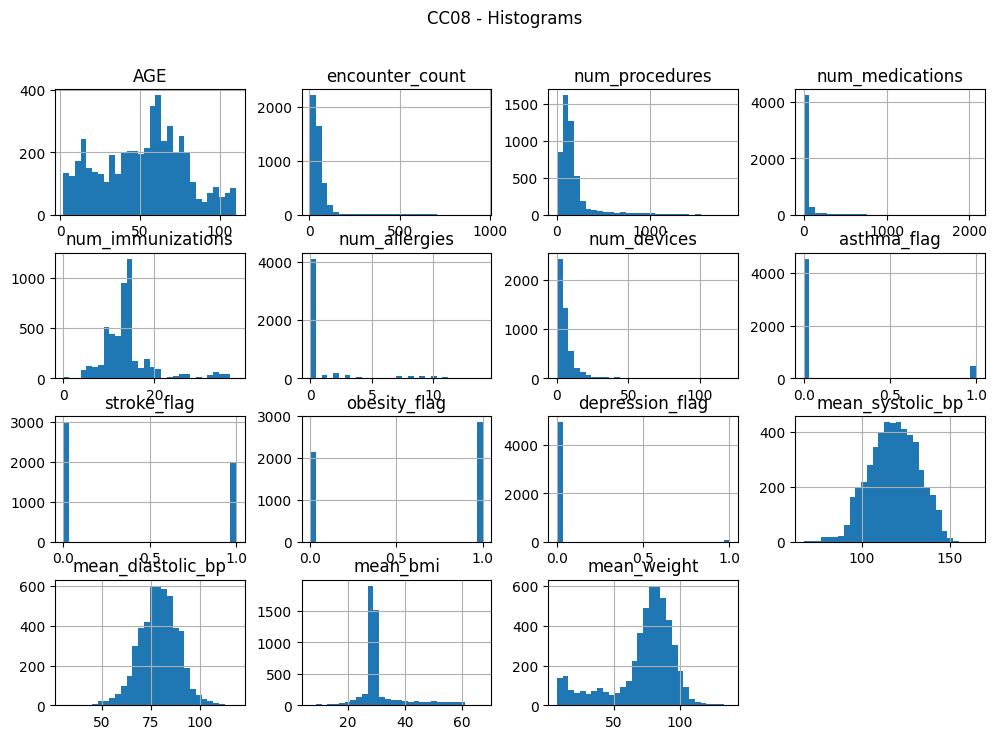


=== AA09: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2500          NaN   4459         4886              NaN   
mean      NaN    47.604000    NaN          NaN        62.860000   
std       NaN    25.558557    NaN          NaN        95.579451   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    26.000000    NaN          NaN        26.000000   
50%       NaN    50.000000    NaN          NaN        37.000000   
75%       NaN    65.000000    NaN          NaN        58.000000   
max       NaN   110.000000    NaN          NaN       819.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

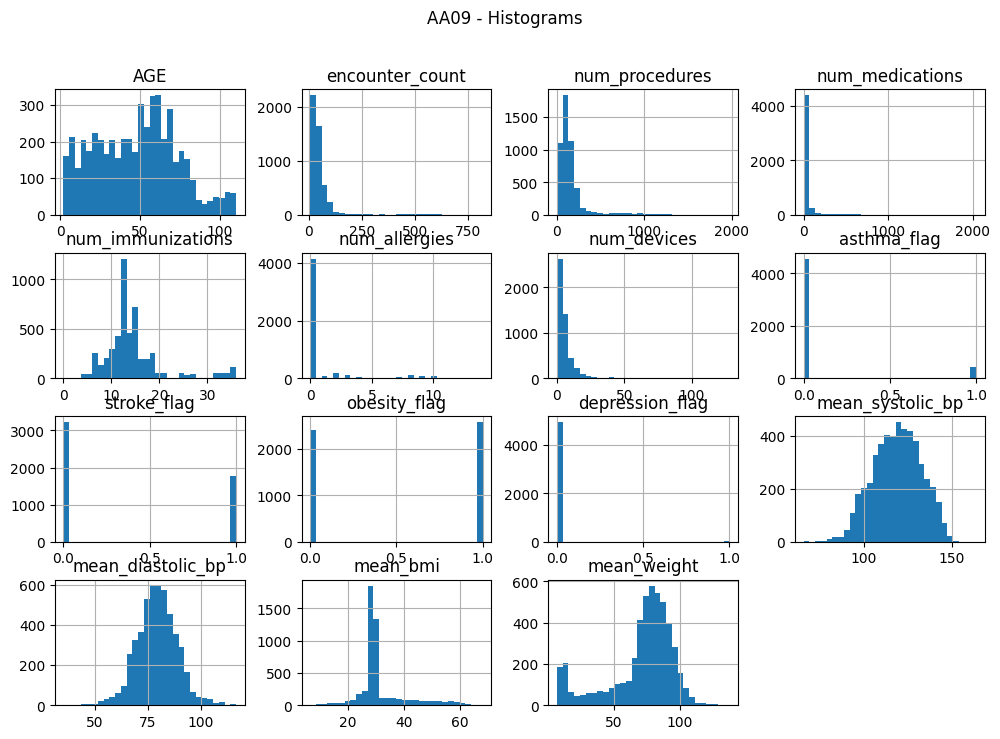


=== CC09: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2506          NaN   4362         4890              NaN   
mean      NaN    47.365600    NaN          NaN        63.455600   
std       NaN    25.694038    NaN          NaN        90.114643   
min       NaN     2.000000    NaN          NaN         4.000000   
25%       NaN    26.750000    NaN          NaN        28.000000   
50%       NaN    50.000000    NaN          NaN        42.000000   
75%       NaN    65.250000    NaN          NaN        64.000000   
max       NaN   110.000000    NaN          NaN       660.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000         5000.00000    5000.000000   
unique             N

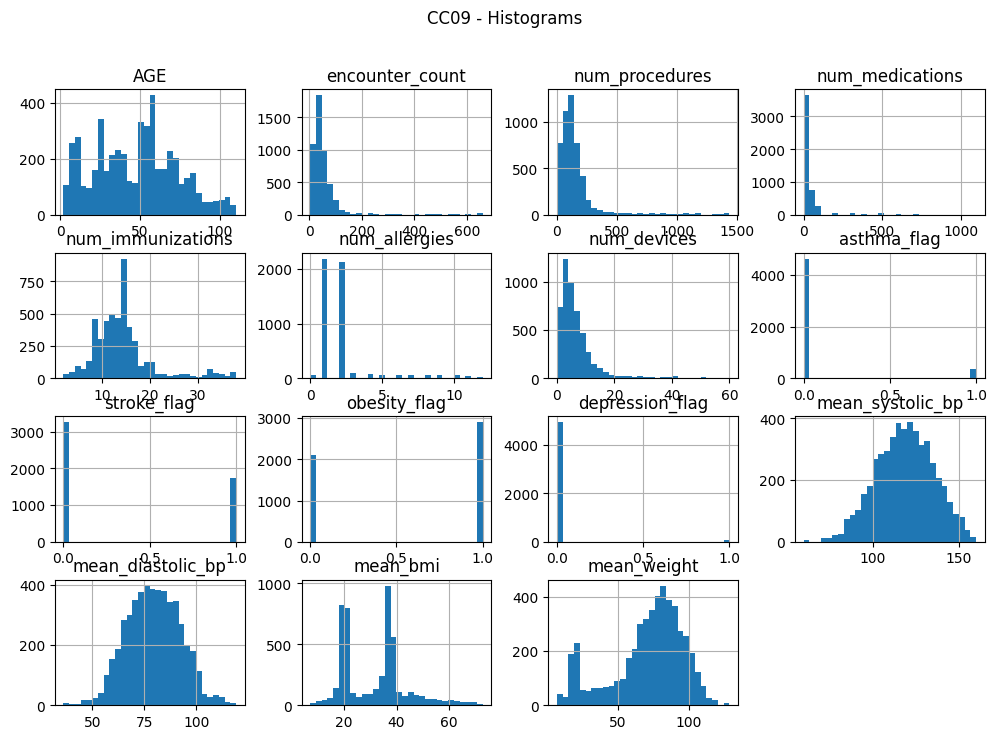


=== AA10: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2505          NaN   4664         4913              NaN   
mean      NaN    46.006200    NaN          NaN        61.439000   
std       NaN    26.034987    NaN          NaN        87.557729   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    46.000000    NaN          NaN        38.000000   
75%       NaN    64.250000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       778.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

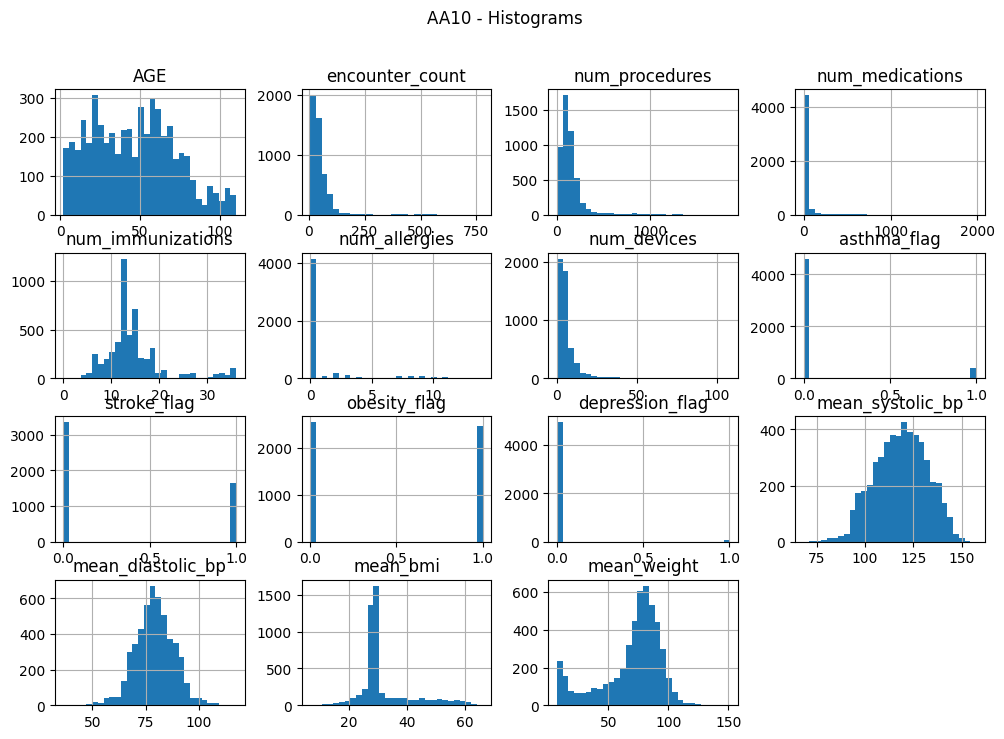


=== CC10: 基本統計量 ===
       GENDER         AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.00000   5000         5000      5000.000000   
unique      2         NaN      6            2              NaN   
top         F         NaN  white  nonhispanic              NaN   
freq     2541         NaN   4426         4943              NaN   
mean      NaN    47.62380    NaN          NaN        65.034200   
std       NaN    25.72432    NaN          NaN        99.470287   
min       NaN     2.00000    NaN          NaN         6.000000   
25%       NaN    26.00000    NaN          NaN        26.000000   
50%       NaN    49.00000    NaN          NaN        38.000000   
75%       NaN    66.00000    NaN          NaN        62.000000   
max       NaN   110.00000    NaN          NaN       975.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             NaN          

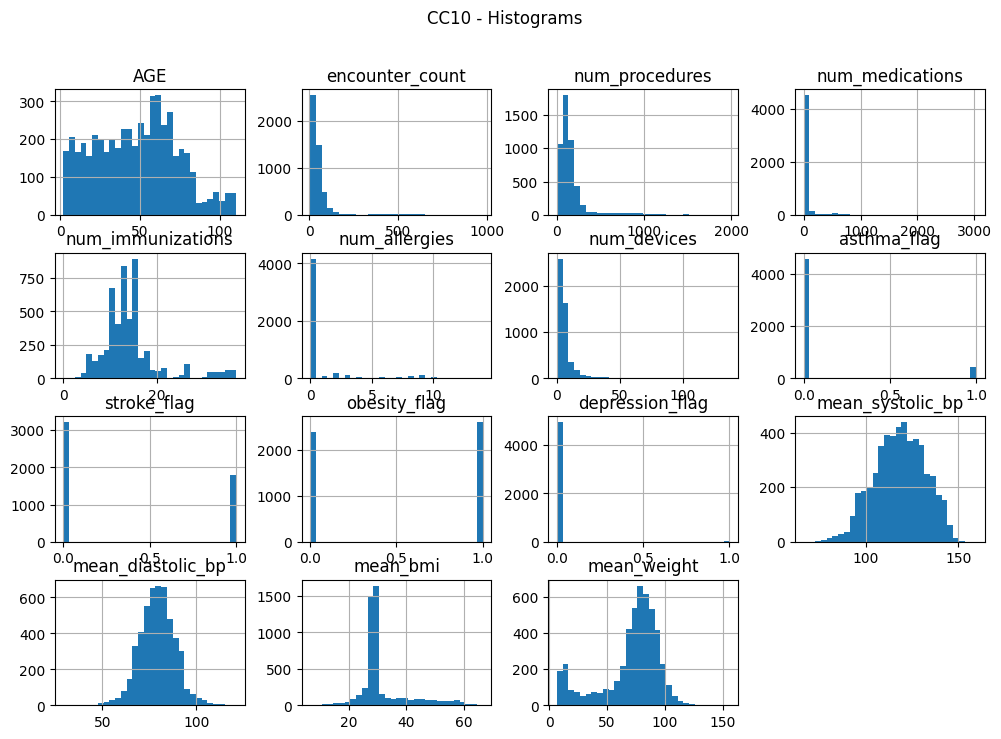


=== AA11: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2607          NaN   4627         4704              NaN   
mean      NaN    47.990400    NaN          NaN        63.270800   
std       NaN    25.974612    NaN          NaN        91.886837   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    25.000000    NaN          NaN        26.000000   
50%       NaN    50.000000    NaN          NaN        38.000000   
75%       NaN    67.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       807.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

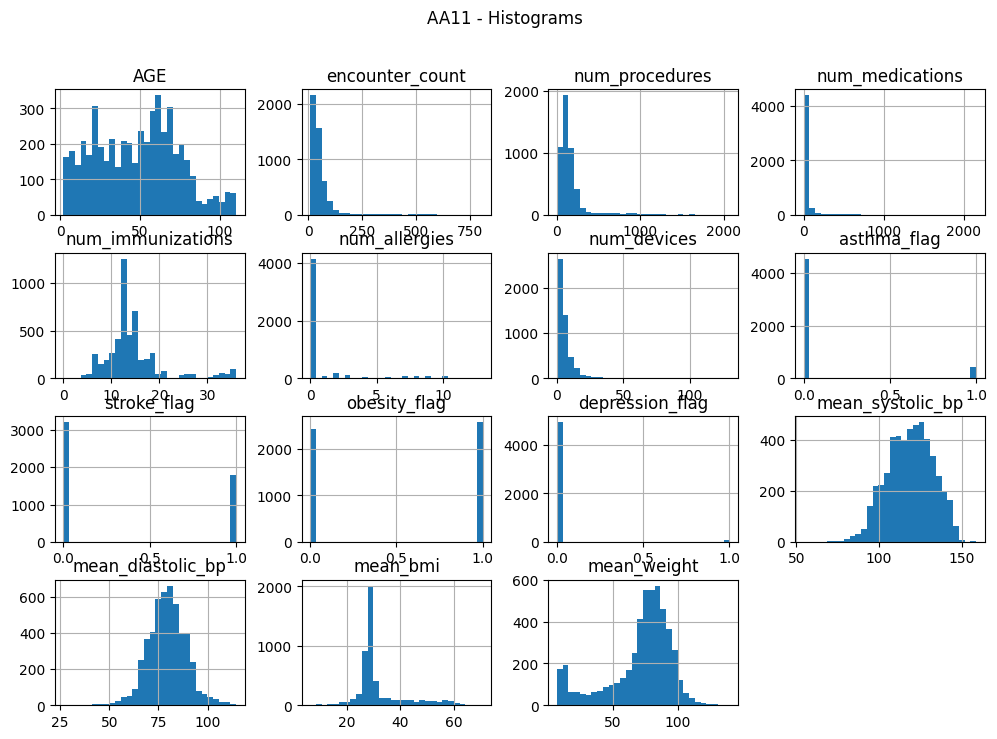


=== CC11: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2558          NaN   4408         4546              NaN   
mean      NaN    47.945200    NaN          NaN         62.72900   
std       NaN    26.672917    NaN          NaN         95.27961   
min       NaN     2.000000    NaN          NaN          7.00000   
25%       NaN    25.000000    NaN          NaN         25.00000   
50%       NaN    50.000000    NaN          NaN         38.00000   
75%       NaN    66.000000    NaN          NaN         60.00000   
max       NaN   110.000000    NaN          NaN        809.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000         5000.00000    5000.000000   
unique             N

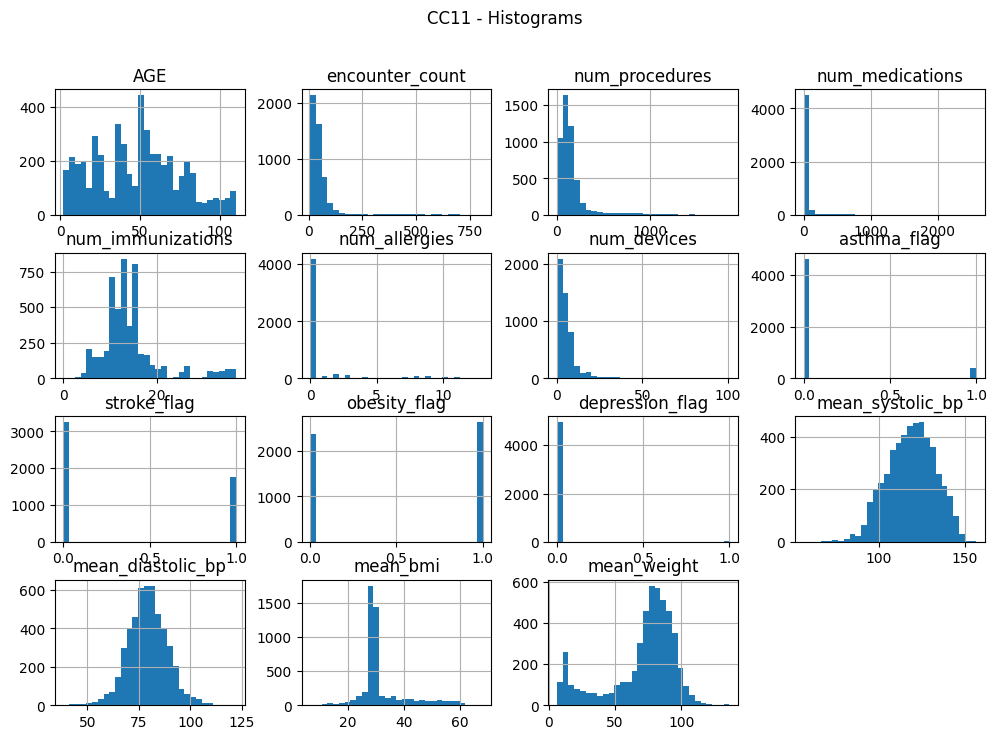


=== AA12: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2563          NaN   4575         4555              NaN   
mean      NaN    45.999000    NaN          NaN        62.186000   
std       NaN    25.018669    NaN          NaN        97.994949   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    25.000000    NaN          NaN        25.000000   
50%       NaN    46.000000    NaN          NaN        37.000000   
75%       NaN    64.000000    NaN          NaN        58.000000   
max       NaN   110.000000    NaN          NaN       818.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

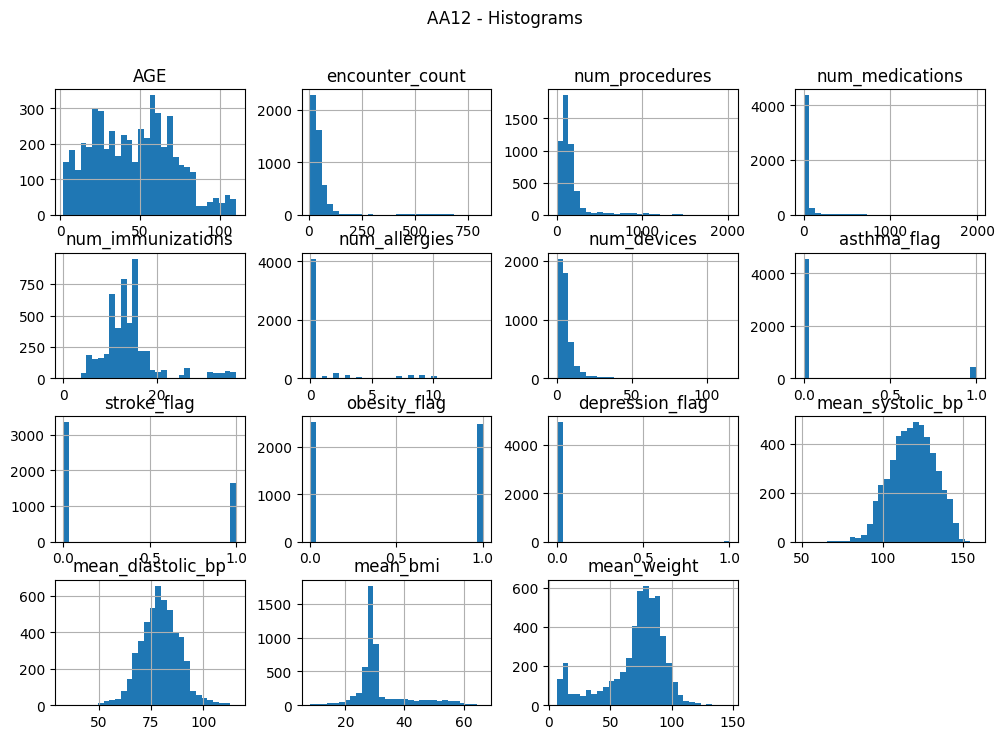


=== CC12: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2577          NaN   4541         4589              NaN   
mean      NaN    45.637400    NaN          NaN        59.233800   
std       NaN    25.244219    NaN          NaN        92.522233   
min       NaN     6.000000    NaN          NaN         6.000000   
25%       NaN    22.000000    NaN          NaN        21.000000   
50%       NaN    44.000000    NaN          NaN        36.000000   
75%       NaN    67.000000    NaN          NaN        61.000000   
max       NaN   106.000000    NaN          NaN       868.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

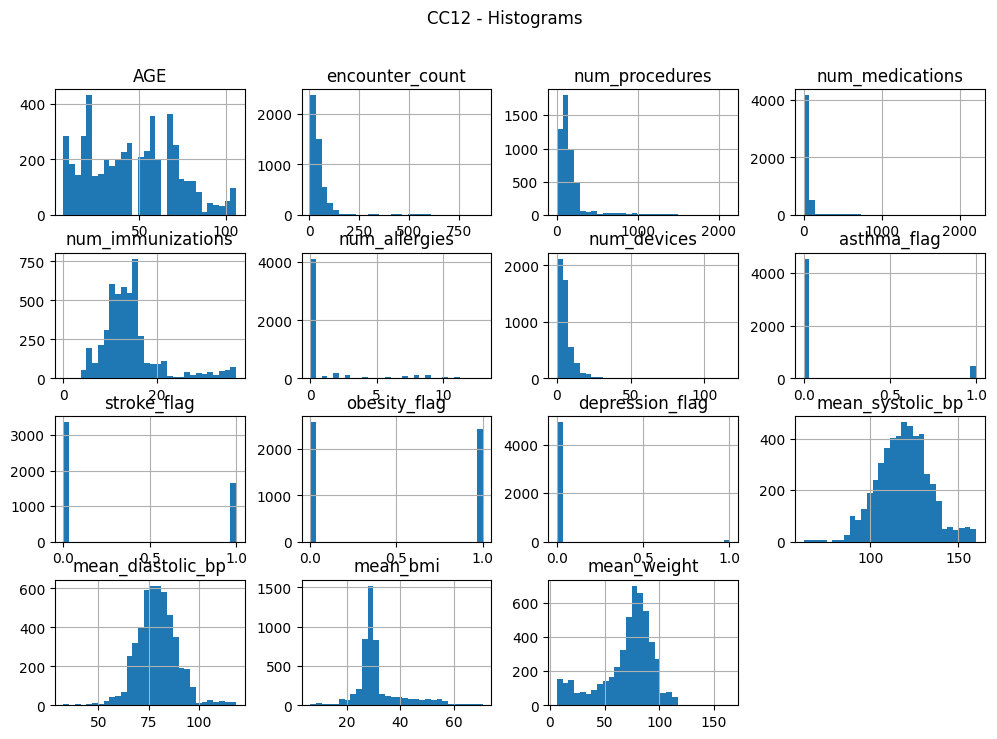


=== AA13: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2514          NaN   4183         4859              NaN   
mean      NaN    44.553000    NaN          NaN        60.269400   
std       NaN    25.470386    NaN          NaN        88.834846   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    44.000000    NaN          NaN        37.000000   
75%       NaN    63.000000    NaN          NaN        59.000000   
max       NaN   110.000000    NaN          NaN       897.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

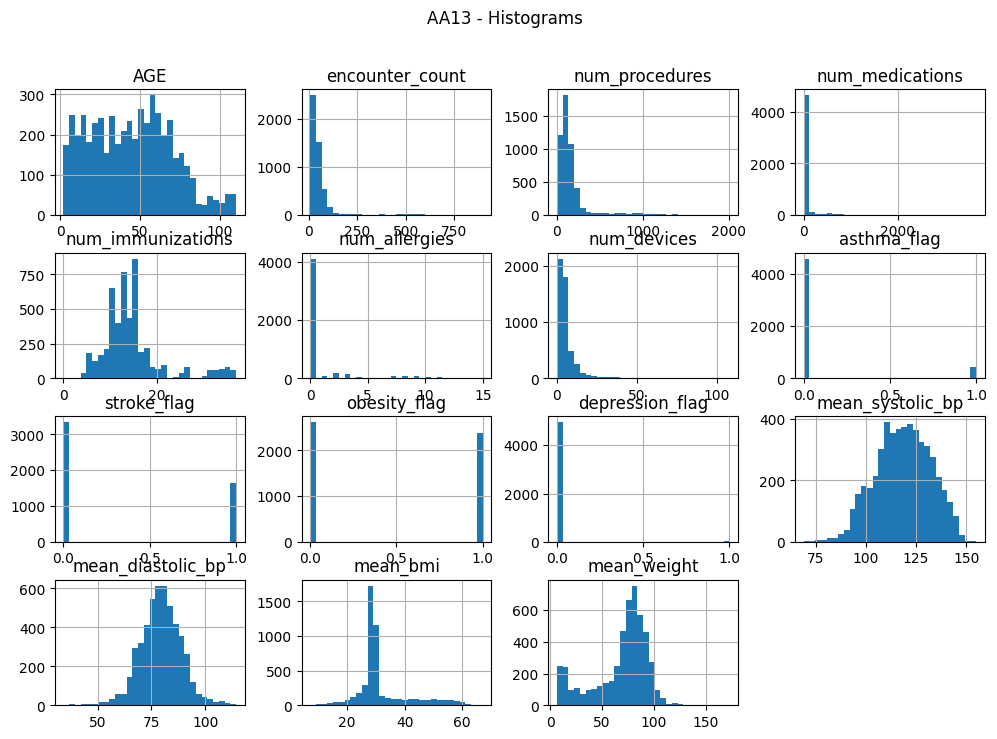


=== CC13: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2536          NaN   3647         4760              NaN   
mean      NaN    44.062600    NaN          NaN        58.757600   
std       NaN    25.662977    NaN          NaN        89.194942   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    22.000000    NaN          NaN        25.000000   
50%       NaN    43.000000    NaN          NaN        36.000000   
75%       NaN    62.000000    NaN          NaN        55.000000   
max       NaN   110.000000    NaN          NaN       766.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

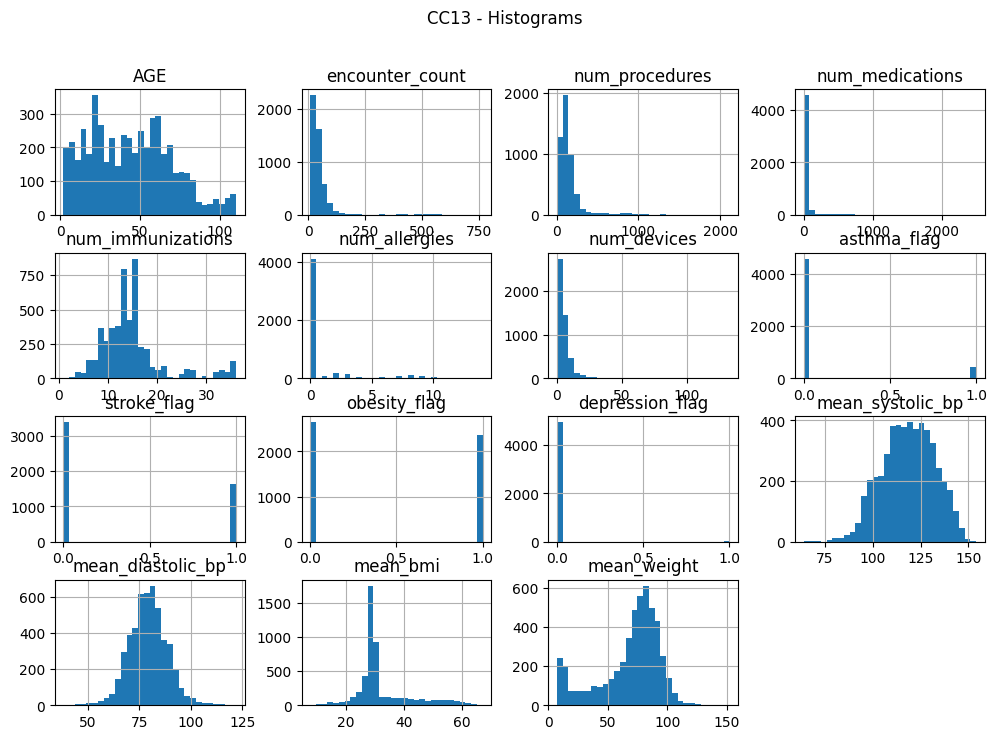


=== AA14: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2603          NaN   4179         4874              NaN   
mean      NaN    49.615800    NaN          NaN        68.699000   
std       NaN    26.009058    NaN          NaN       103.410048   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    28.000000    NaN          NaN        26.000000   
50%       NaN    52.000000    NaN          NaN        40.000000   
75%       NaN    69.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       881.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

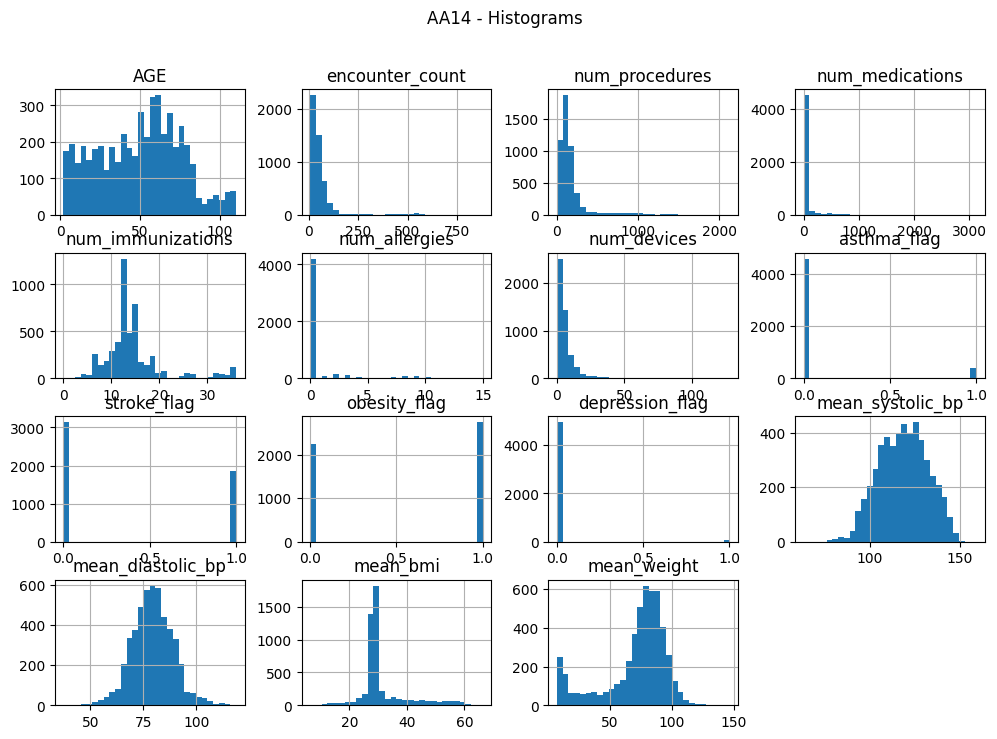


=== CC14: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2631          NaN   3959         4648              NaN   
mean      NaN    49.269800    NaN          NaN        68.368400   
std       NaN    26.251721    NaN          NaN       104.834536   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    28.000000    NaN          NaN        26.000000   
50%       NaN    51.000000    NaN          NaN        39.000000   
75%       NaN    69.000000    NaN          NaN        65.000000   
max       NaN   110.000000    NaN          NaN       893.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

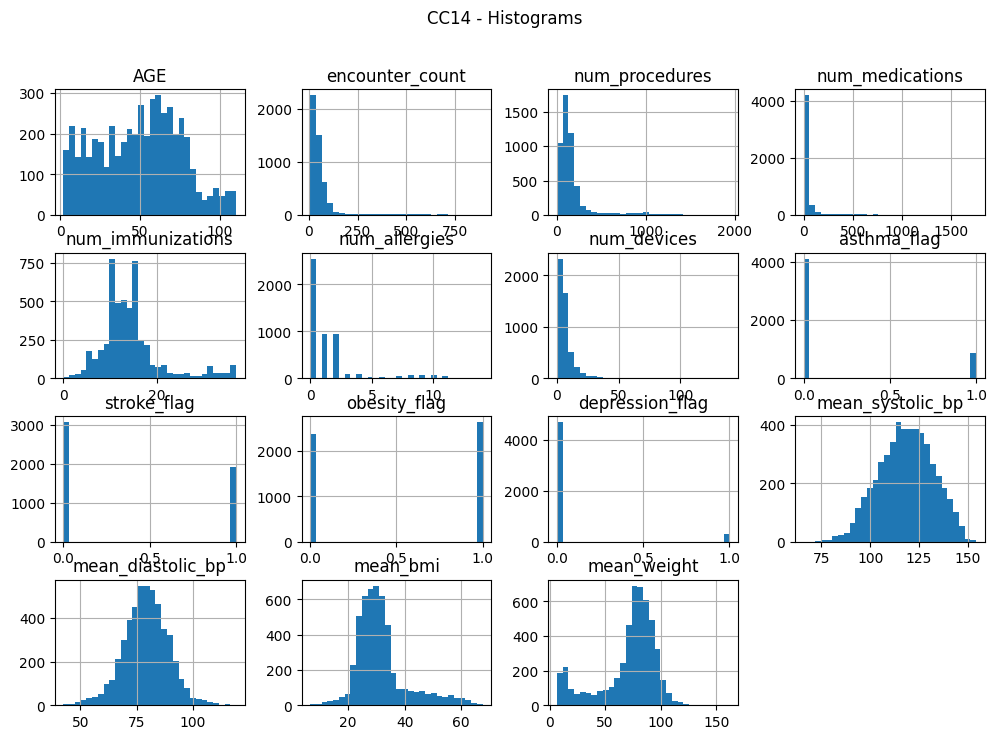


=== AA15: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2548          NaN   4306         4697              NaN   
mean      NaN    47.242800    NaN          NaN        66.672800   
std       NaN    27.046992    NaN          NaN        97.718268   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    24.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        39.000000   
75%       NaN    66.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       810.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

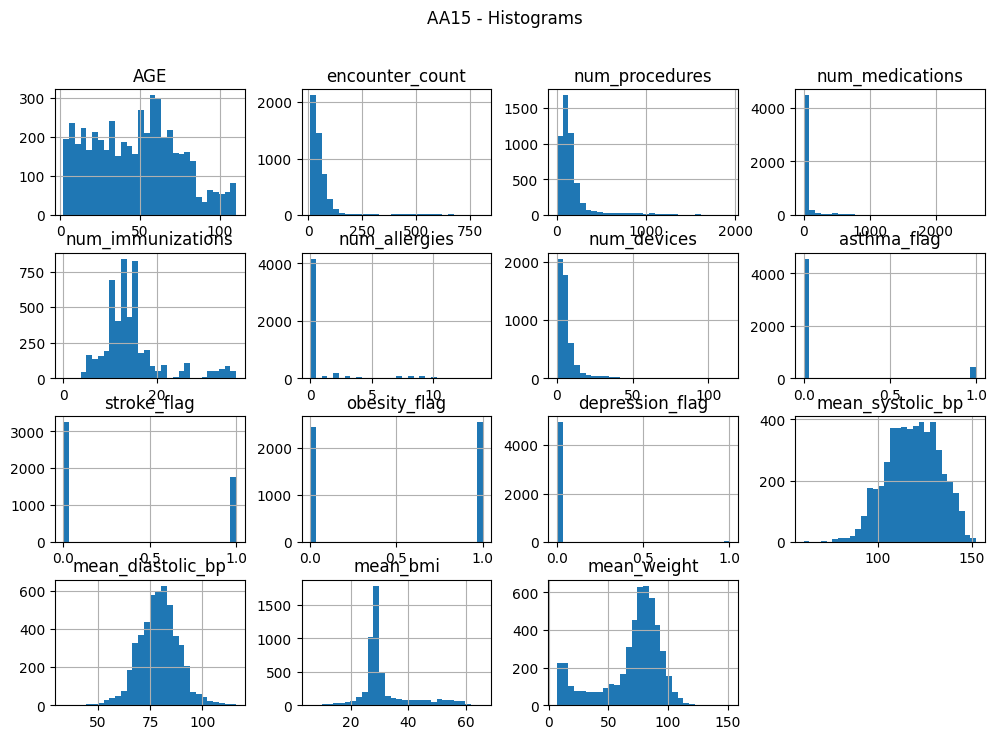


=== CC15: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2532          NaN   4093         4493              NaN   
mean      NaN    46.133400    NaN          NaN        55.064400   
std       NaN    22.143299    NaN          NaN        58.903774   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    29.000000    NaN          NaN        26.000000   
50%       NaN    47.000000    NaN          NaN        47.000000   
75%       NaN    62.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       766.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count        5000.0000      5000.000000        5000.000000    5000.000000   
unique             N

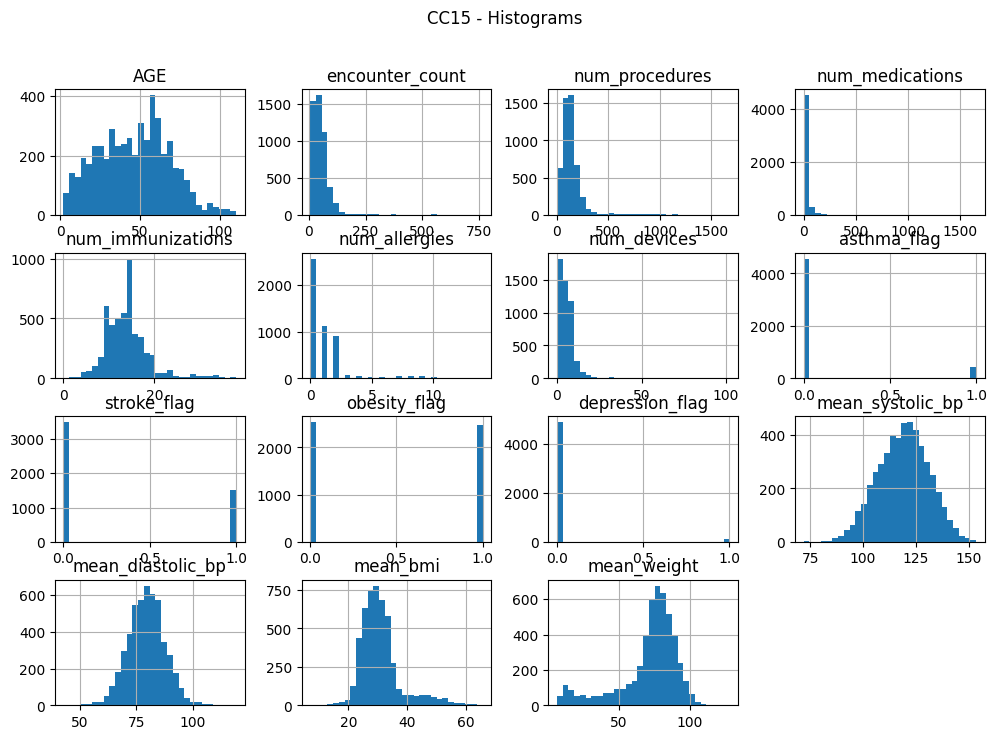


=== AA16: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2584          NaN   3850         4462              NaN   
mean      NaN    46.955600    NaN          NaN        61.750600   
std       NaN    23.914322    NaN          NaN        92.671126   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    28.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        38.000000   
75%       NaN    63.000000    NaN          NaN        60.000000   
max       NaN   110.000000    NaN          NaN       855.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

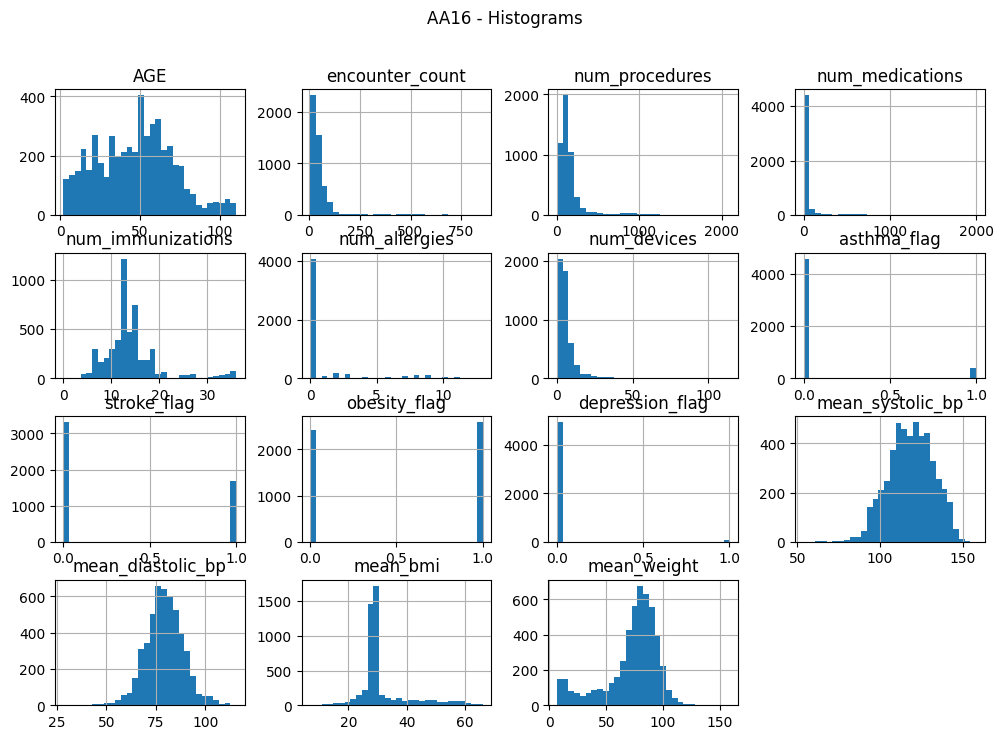


=== CC16: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2523          NaN   3011         3993              NaN   
mean      NaN    45.031000    NaN          NaN        55.283800   
std       NaN    22.319876    NaN          NaN        80.710766   
min       NaN     2.000000    NaN          NaN         4.000000   
25%       NaN    29.000000    NaN          NaN        25.000000   
50%       NaN    47.000000    NaN          NaN        34.000000   
75%       NaN    61.000000    NaN          NaN        55.000000   
max       NaN   110.000000    NaN          NaN       771.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

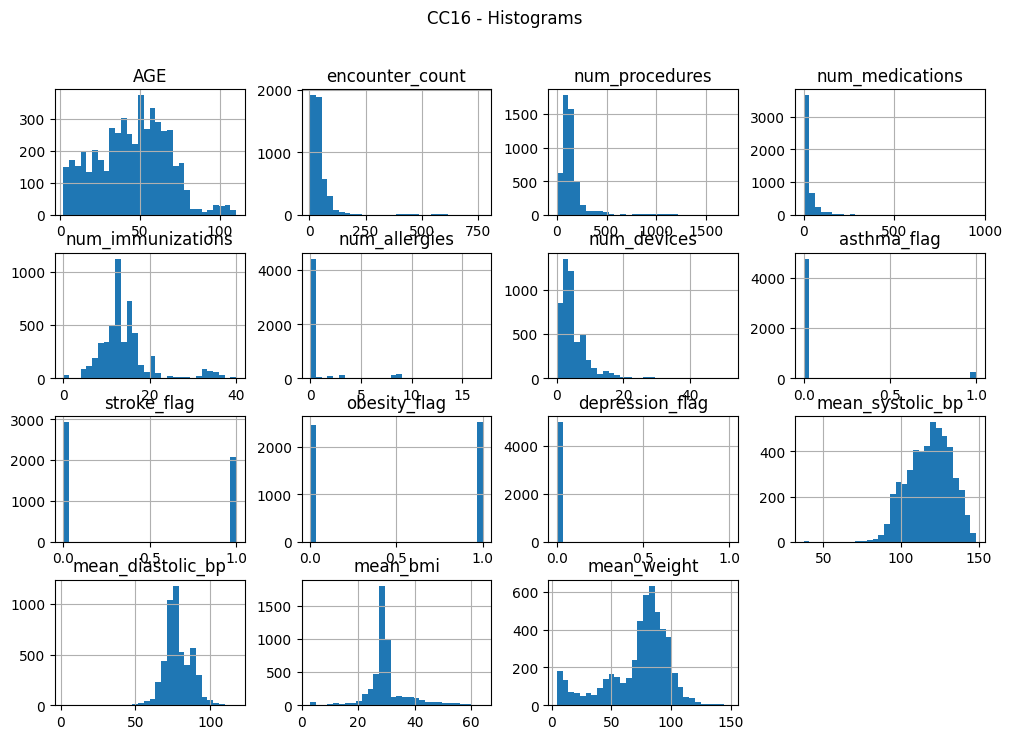


=== AA17: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2553          NaN   3333         4763              NaN   
mean      NaN    48.045800    NaN          NaN         70.35320   
std       NaN    29.333022    NaN          NaN        110.76594   
min       NaN     2.000000    NaN          NaN          7.00000   
25%       NaN    23.000000    NaN          NaN         25.00000   
50%       NaN    50.000000    NaN          NaN         38.00000   
75%       NaN    65.000000    NaN          NaN         63.00000   
max       NaN   110.000000    NaN          NaN        831.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count        5000.0000      5000.000000        5000.000000     5000.00000   
unique             N

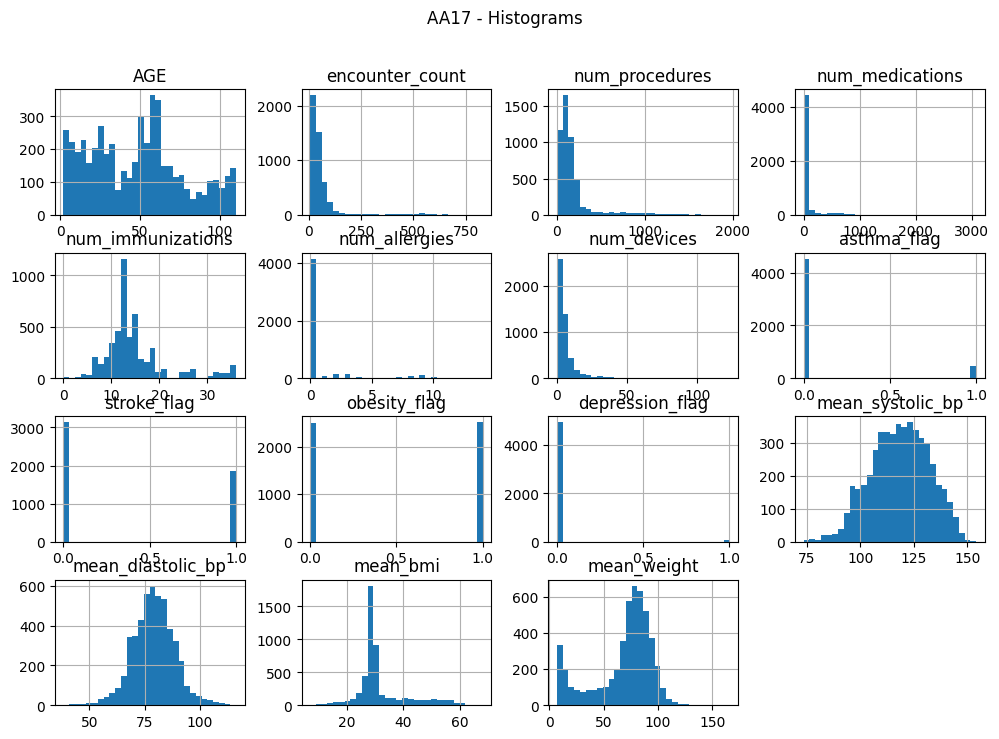


=== CC17: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2527          NaN   2892         4098              NaN   
mean      NaN    48.435400    NaN          NaN        69.766400   
std       NaN    29.242491    NaN          NaN       108.640981   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    24.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        39.000000   
75%       NaN    66.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       937.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000         5000.00000    5000.000000   
unique             N

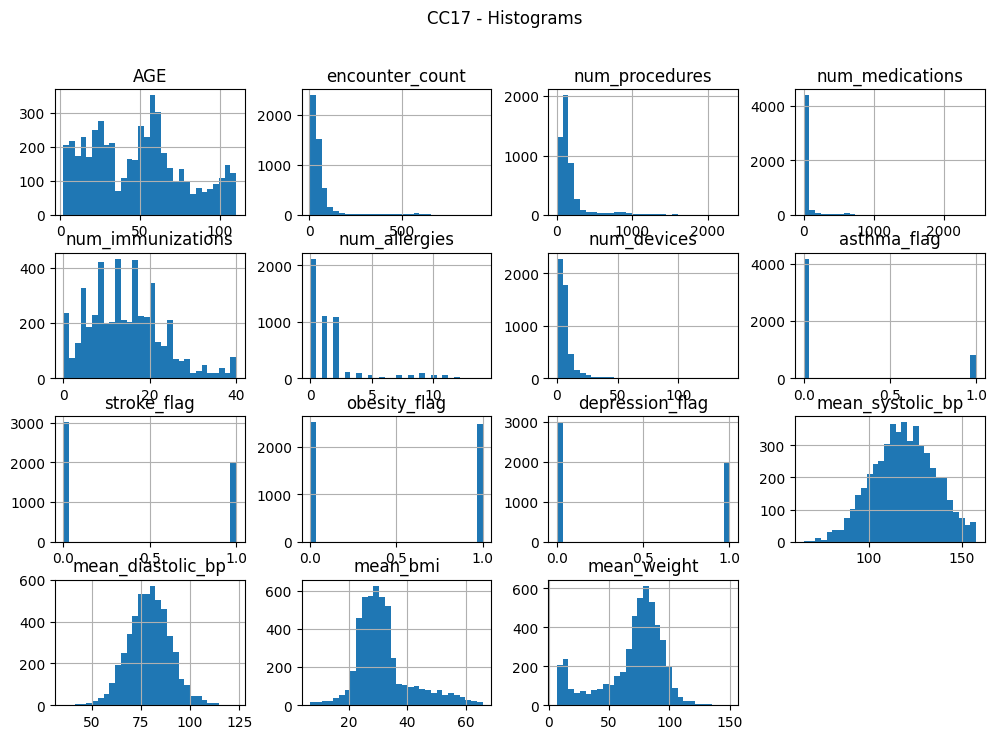


=== AA18: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2596          NaN   4135         3765              NaN   
mean      NaN    42.984000    NaN          NaN        57.323200   
std       NaN    25.178144    NaN          NaN        86.780803   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    21.000000    NaN          NaN        24.000000   
50%       NaN    43.000000    NaN          NaN        34.000000   
75%       NaN    61.000000    NaN          NaN        56.000000   
max       NaN   110.000000    NaN          NaN       814.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

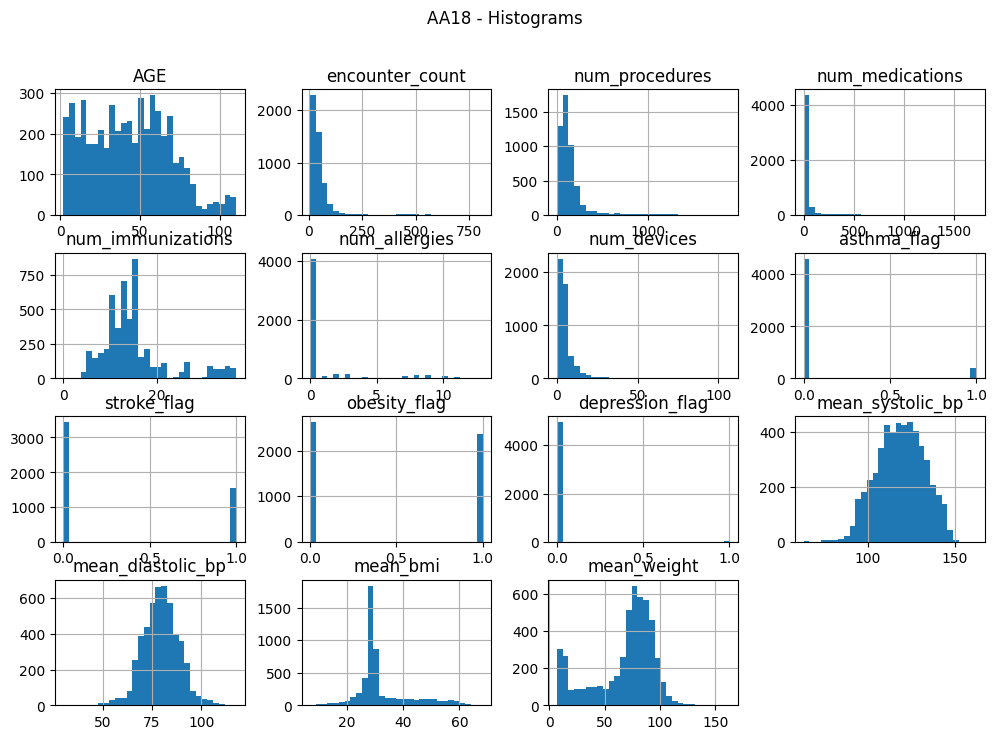


=== CC18: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2551          NaN   4253         4026              NaN   
mean      NaN    40.768600    NaN          NaN        55.921800   
std       NaN    24.269587    NaN          NaN        79.967352   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    20.000000    NaN          NaN        24.000000   
50%       NaN    40.000000    NaN          NaN        35.000000   
75%       NaN    58.000000    NaN          NaN        57.000000   
max       NaN   110.000000    NaN          NaN       811.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000         5000.00000    5000.000000   
unique             N

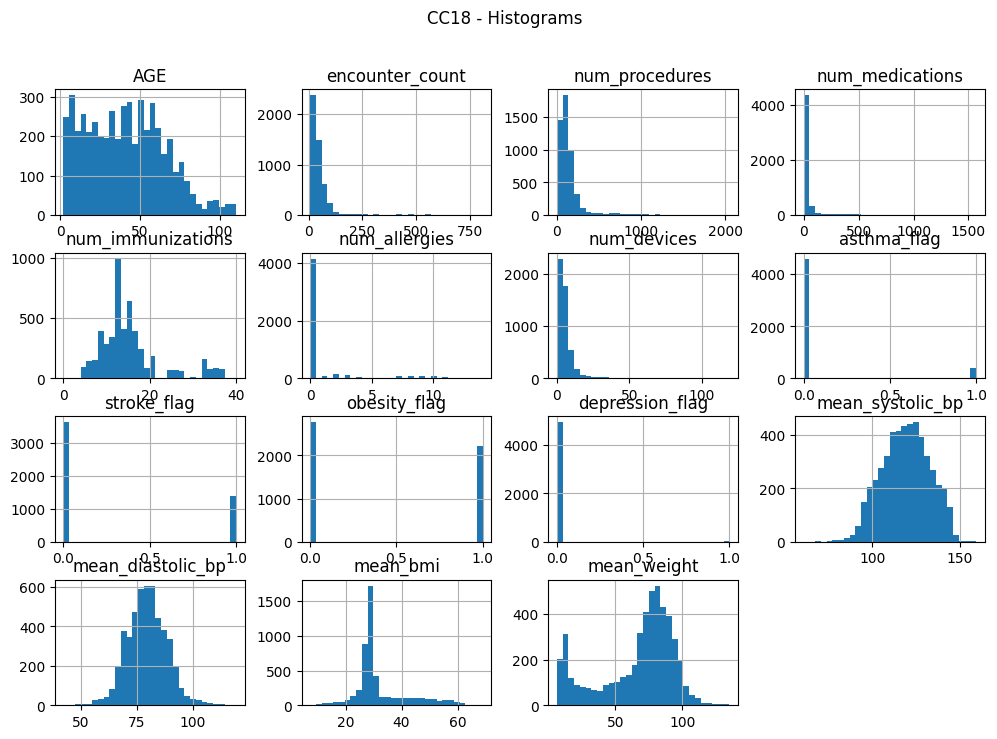


=== AA19: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2520          NaN   4762         4914              NaN   
mean      NaN    46.730600    NaN          NaN         59.63660   
std       NaN    25.749171    NaN          NaN         89.06173   
min       NaN     2.000000    NaN          NaN          7.00000   
25%       NaN    25.000000    NaN          NaN         25.00000   
50%       NaN    48.000000    NaN          NaN         36.00000   
75%       NaN    65.000000    NaN          NaN         57.00000   
max       NaN   110.000000    NaN          NaN        779.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

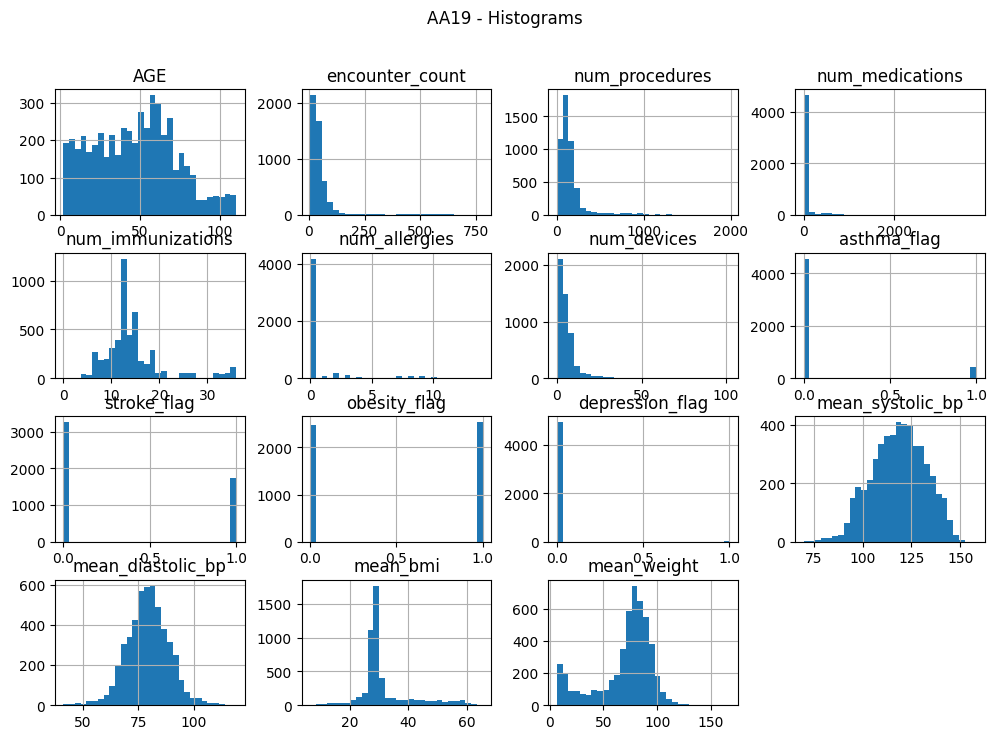


=== CC19: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2525          NaN   4726         4931              NaN   
mean      NaN    46.908800    NaN          NaN        65.134800   
std       NaN    24.982028    NaN          NaN        95.140161   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    27.000000    NaN          NaN        12.000000   
50%       NaN    47.000000    NaN          NaN        31.000000   
75%       NaN    64.000000    NaN          NaN        65.250000   
max       NaN   110.000000    NaN          NaN       691.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

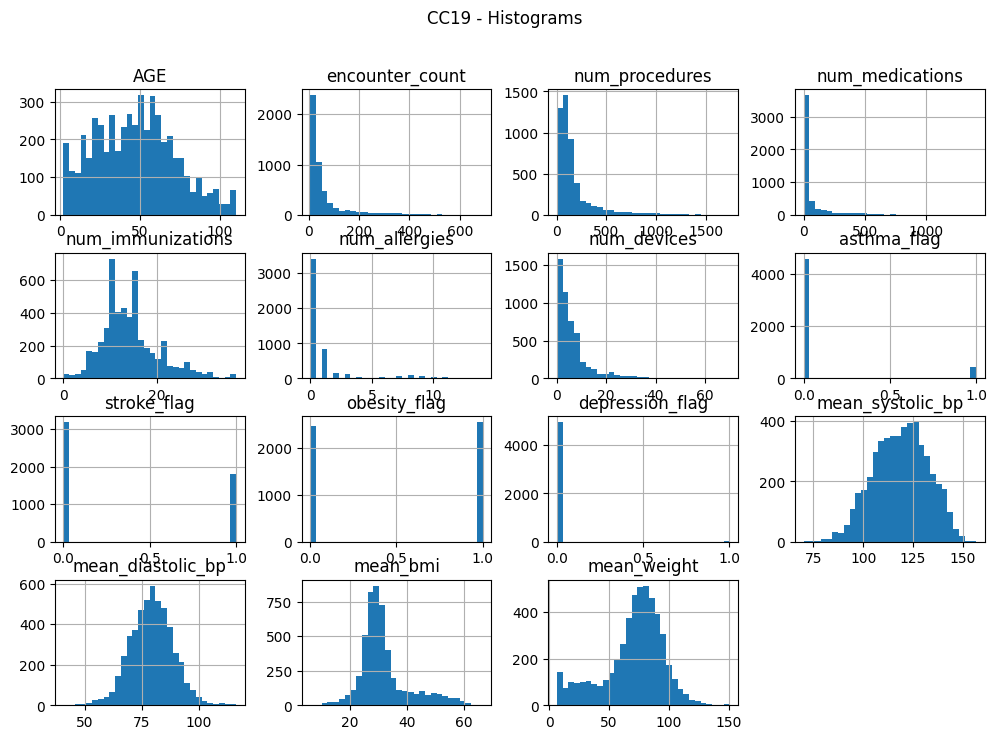


=== AA20: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2588          NaN   3776         4704              NaN   
mean      NaN    45.400800    NaN          NaN        62.853600   
std       NaN    25.054614    NaN          NaN        92.387532   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    25.000000    NaN          NaN        25.000000   
50%       NaN    45.000000    NaN          NaN        38.000000   
75%       NaN    63.000000    NaN          NaN        62.250000   
max       NaN   110.000000    NaN          NaN       852.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

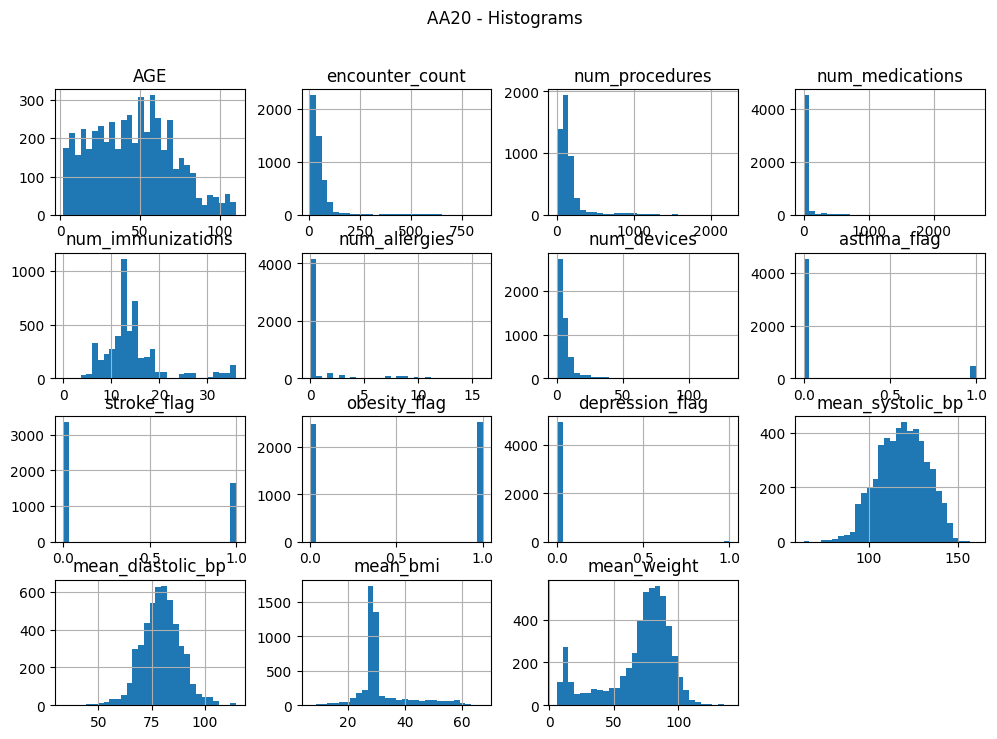


=== CC20: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2501          NaN   3748         4632              NaN   
mean      NaN    44.530800    NaN          NaN        61.794800   
std       NaN    25.572811    NaN          NaN        95.794681   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    44.000000    NaN          NaN        36.000000   
75%       NaN    63.000000    NaN          NaN        59.000000   
max       NaN   110.000000    NaN          NaN       848.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

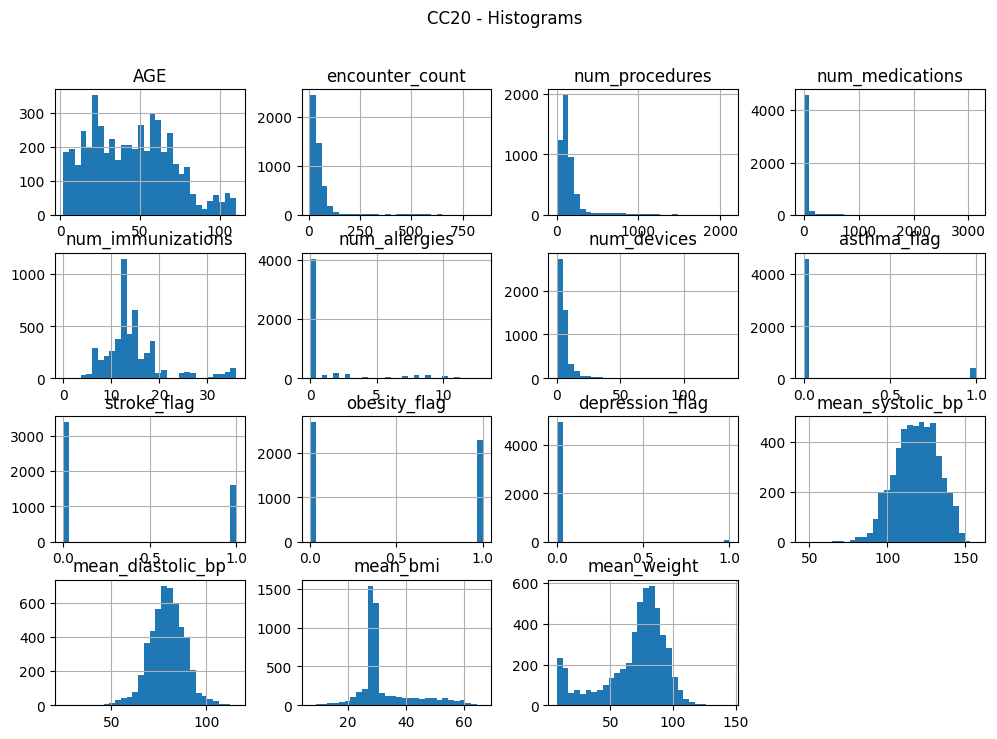


=== AA22: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2537          NaN   4783         4867              NaN   
mean      NaN    49.477800    NaN          NaN        67.355800   
std       NaN    26.242653    NaN          NaN        98.003372   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    27.000000    NaN          NaN        27.000000   
50%       NaN    52.000000    NaN          NaN        40.000000   
75%       NaN    69.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       828.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

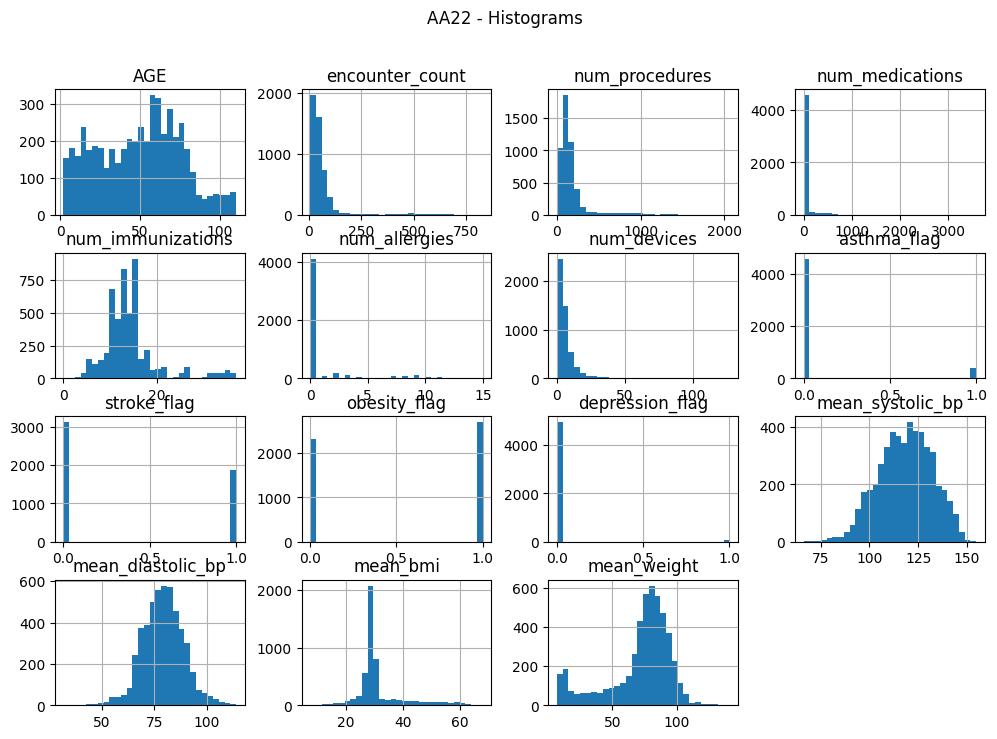


=== CC22: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2550          NaN   4772         4883              NaN   
mean      NaN    49.892200    NaN          NaN        68.889600   
std       NaN    25.680827    NaN          NaN        94.067373   
min       NaN     2.000000    NaN          NaN        11.000000   
25%       NaN    29.000000    NaN          NaN        29.000000   
50%       NaN    52.000000    NaN          NaN        44.000000   
75%       NaN    69.000000    NaN          NaN        65.000000   
max       NaN   109.000000    NaN          NaN       722.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000     5000.00000   
unique             N

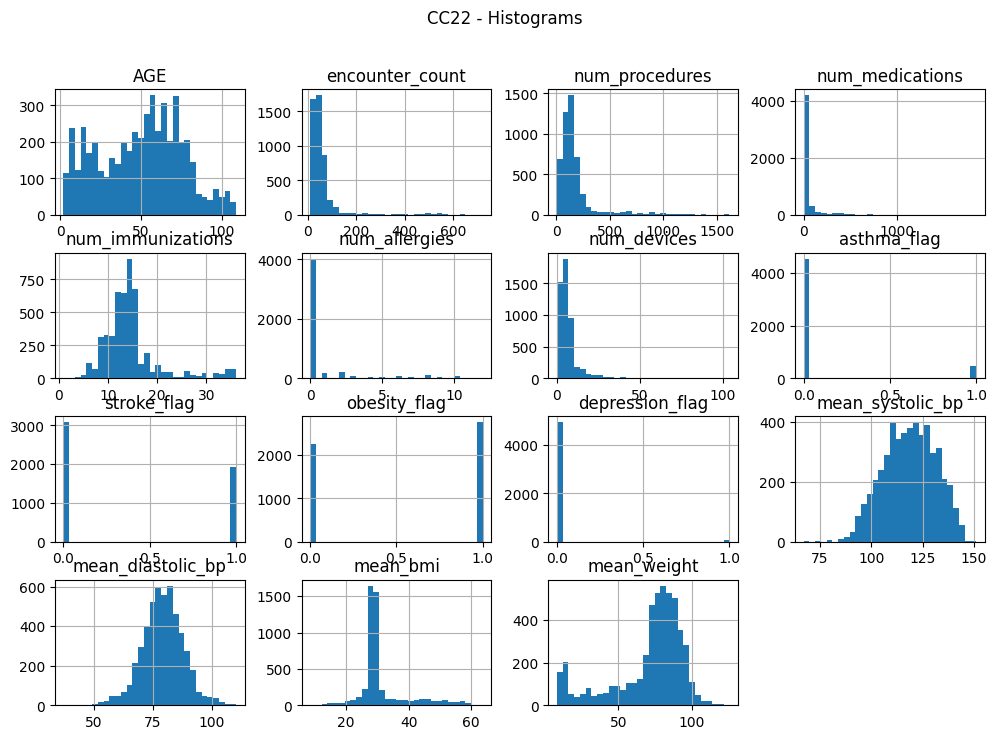


=== AA23: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2661          NaN   4473         4893              NaN   
mean      NaN    50.385400    NaN          NaN        65.919800   
std       NaN    25.195853    NaN          NaN        98.852454   
min       NaN     2.000000    NaN          NaN         9.000000   
25%       NaN    30.000000    NaN          NaN        27.000000   
50%       NaN    53.000000    NaN          NaN        39.000000   
75%       NaN    68.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       862.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

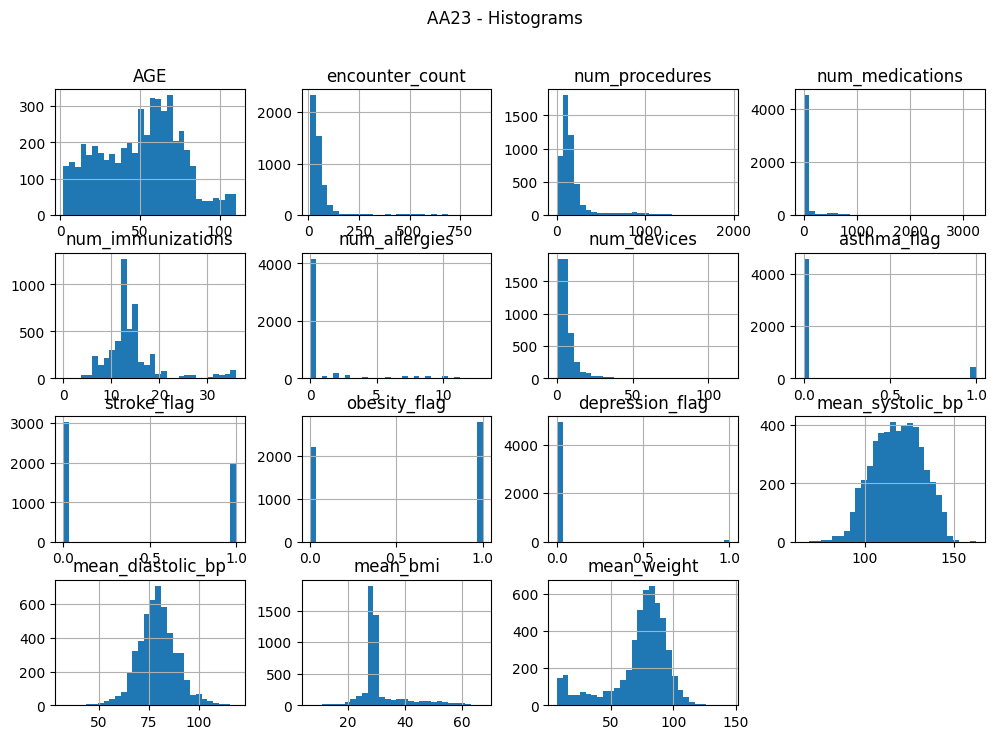


=== CC23: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2507          NaN   4455         4899              NaN   
mean      NaN    49.238800    NaN          NaN        46.648000   
std       NaN    21.031506    NaN          NaN        23.970862   
min       NaN    10.000000    NaN          NaN        14.000000   
25%       NaN    34.000000    NaN          NaN        28.000000   
50%       NaN    52.000000    NaN          NaN        42.000000   
75%       NaN    66.000000    NaN          NaN        58.000000   
max       NaN    80.000000    NaN          NaN       100.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

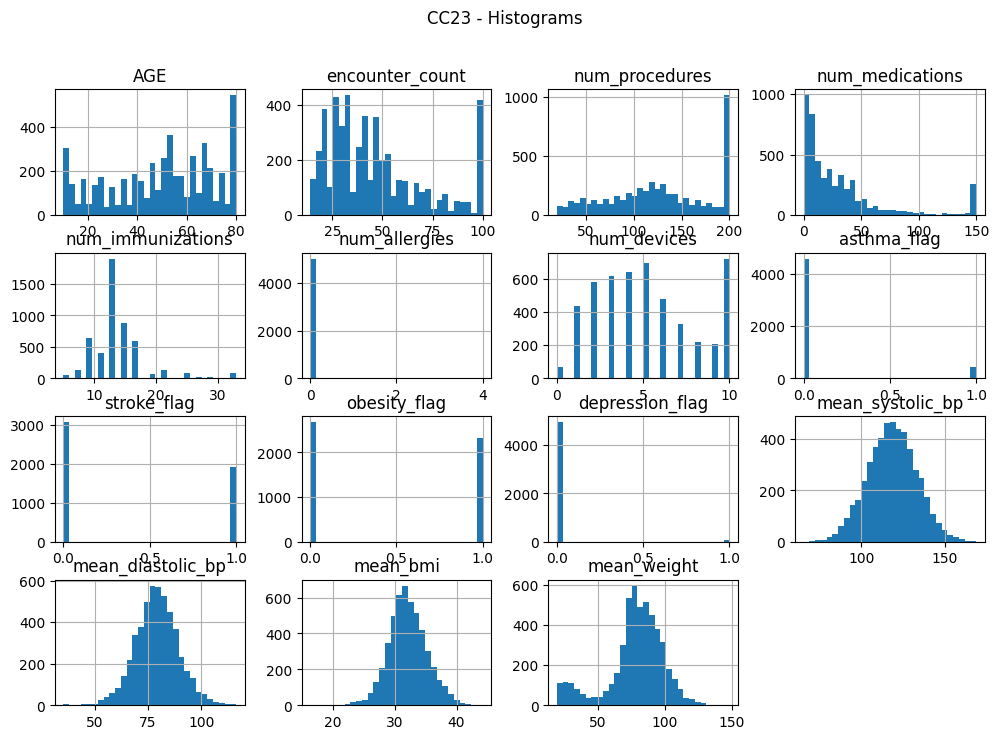


=== AA24: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2592          NaN   4505         4674              NaN   
mean      NaN    45.531000    NaN          NaN        61.904600   
std       NaN    26.094636    NaN          NaN        95.978182   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    45.000000    NaN          NaN        37.000000   
75%       NaN    64.000000    NaN          NaN        59.000000   
max       NaN   110.000000    NaN          NaN       820.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

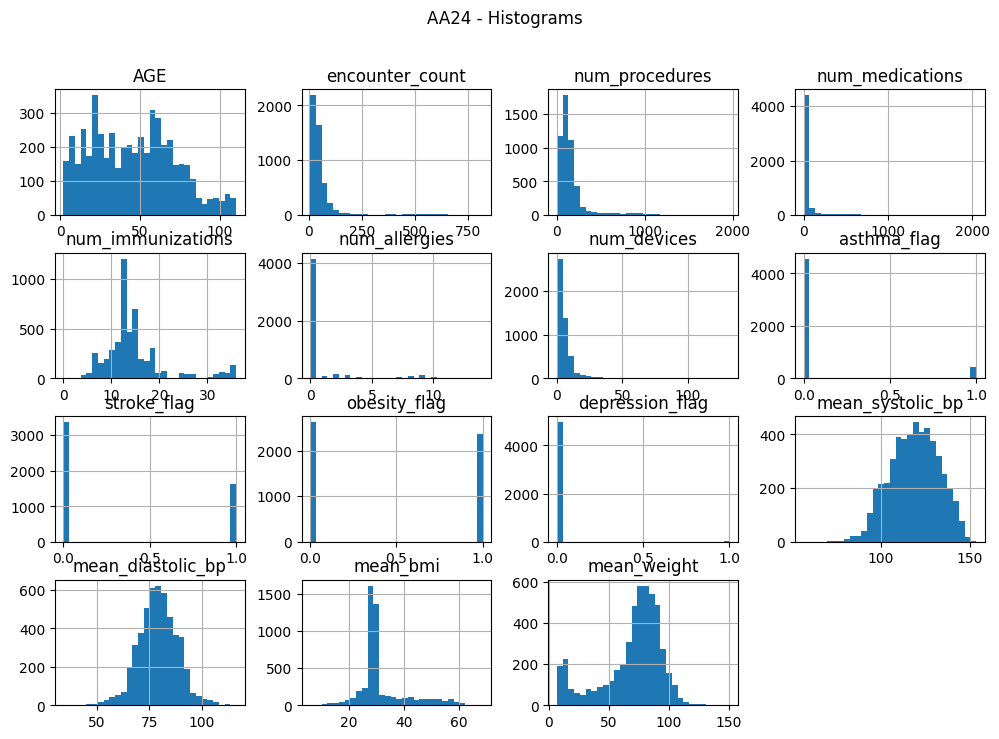


=== CC24: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2622          NaN   3241         3355              NaN   
mean      NaN    45.467800    NaN          NaN        60.106200   
std       NaN    24.703583    NaN          NaN        90.486716   
min       NaN     7.000000    NaN          NaN         6.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    46.000000    NaN          NaN        37.000000   
75%       NaN    65.000000    NaN          NaN        59.000000   
max       NaN    91.000000    NaN          NaN       839.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

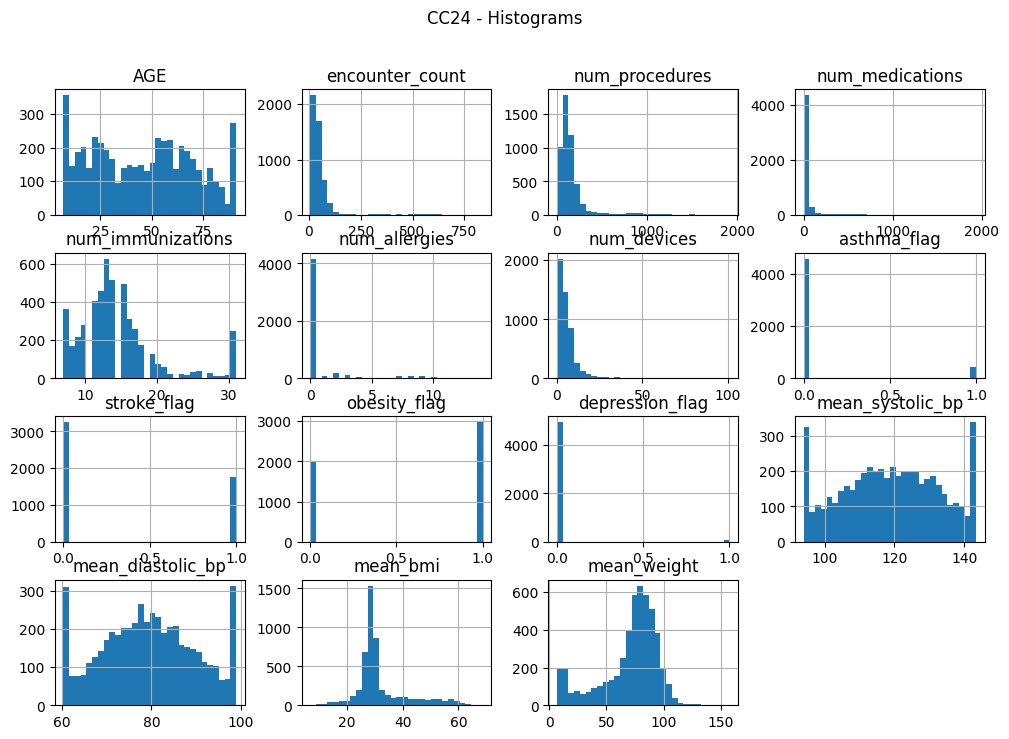

In [5]:
# %% 1. 基本統計量の比較
for (name_aa, name_cc), (df_aa, df_cc) in zip(dataset_names, datasets):
    print(f"\n=== {name_aa}: 基本統計量 ===")
    print(df_aa.describe(include="all"))
    df_aa.hist(figsize=(12, 8), bins=30)
    plt.suptitle(f"{name_aa} - Histograms")
    plt.show()

    print(f"\n=== {name_cc}: 基本統計量 ===")
    print(df_cc.describe(include="all"))
    df_cc.hist(figsize=(12, 8), bins=30)
    plt.suptitle(f"{name_cc} - Histograms")
    plt.show()


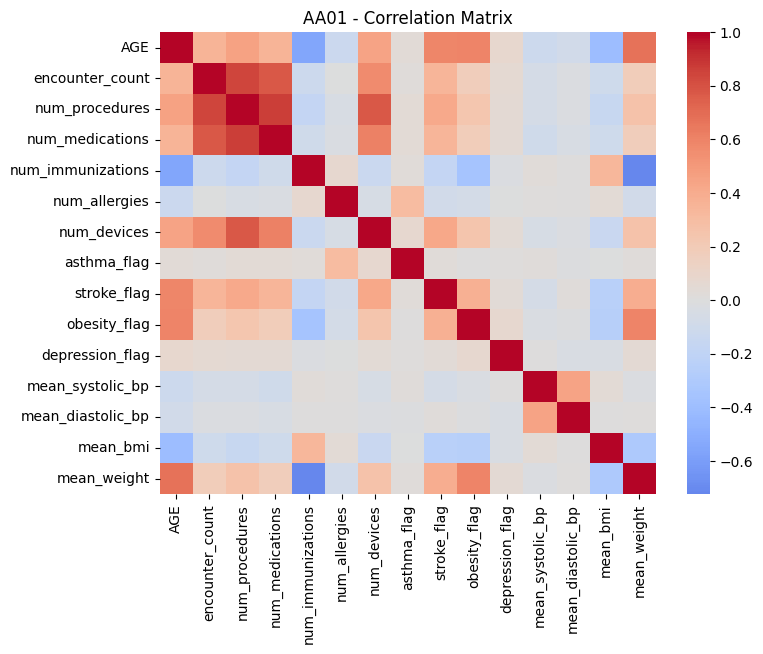

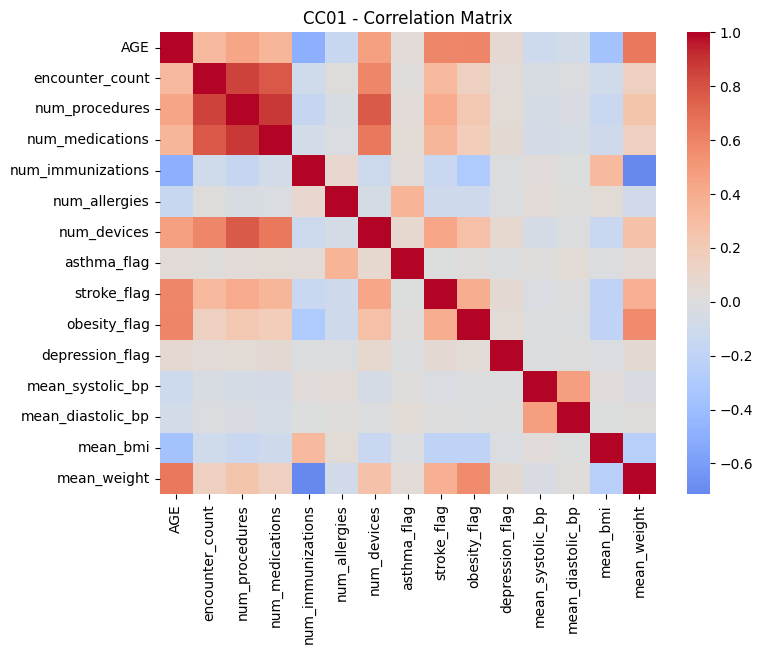

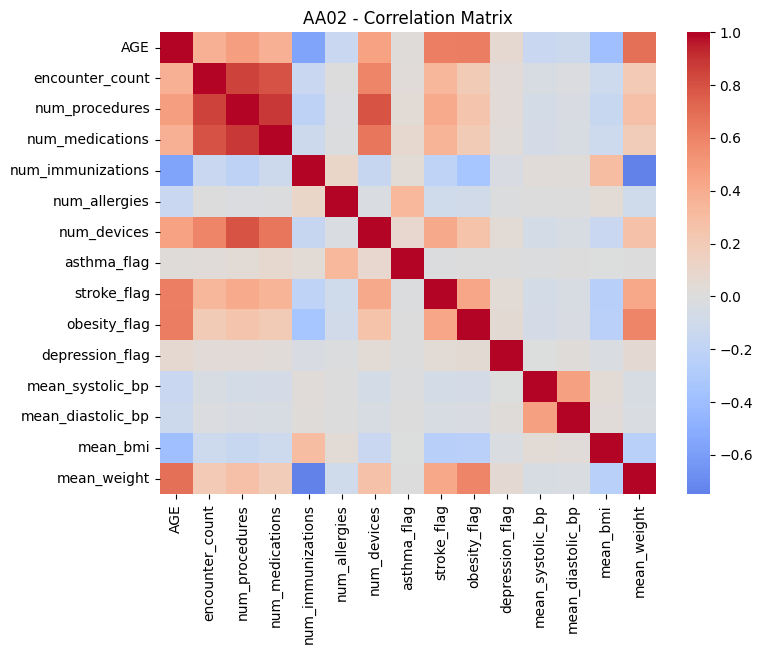

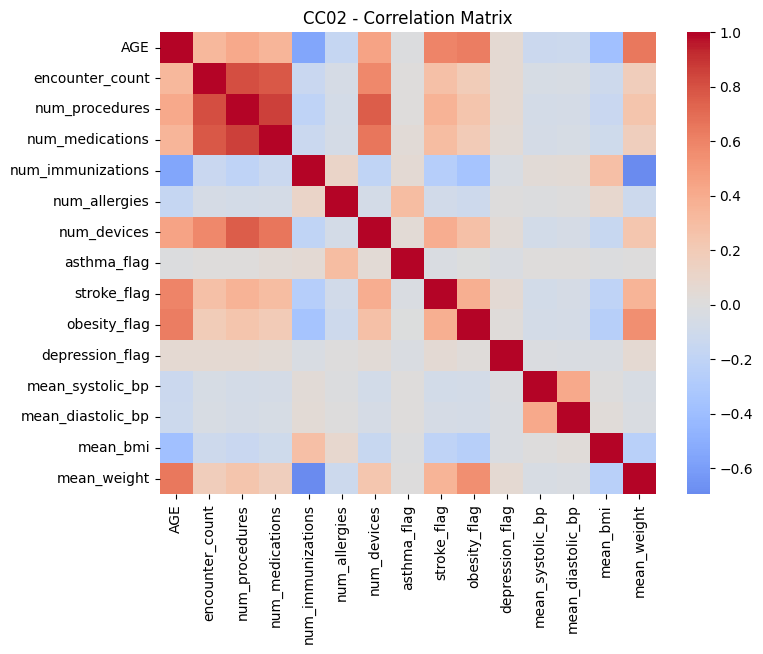

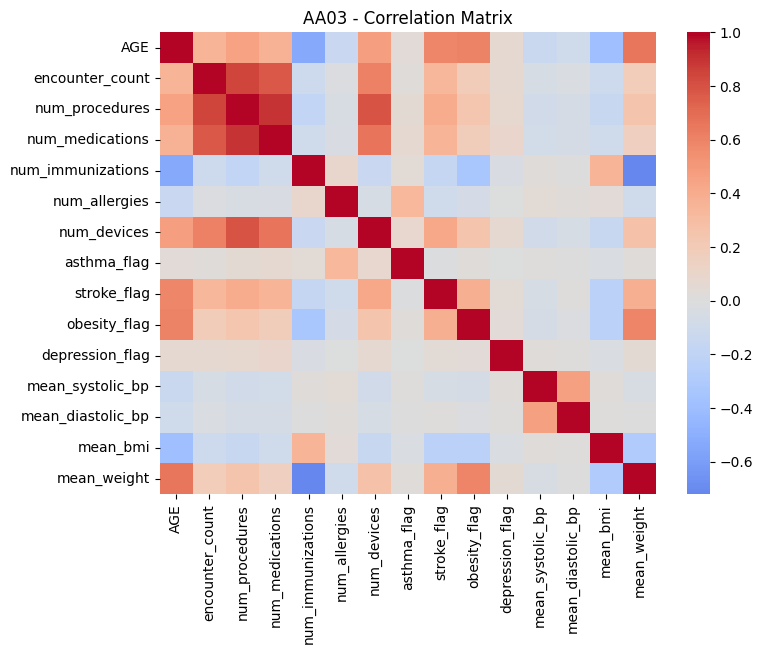

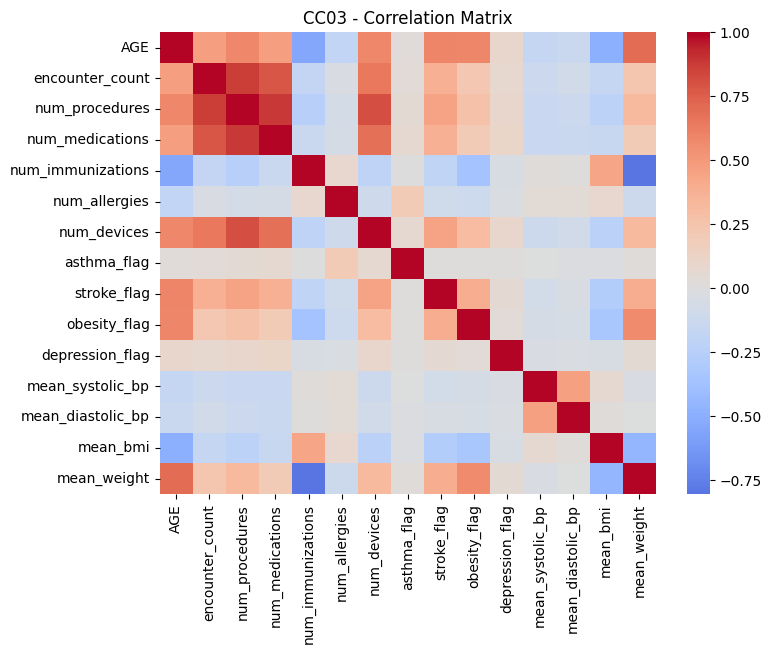

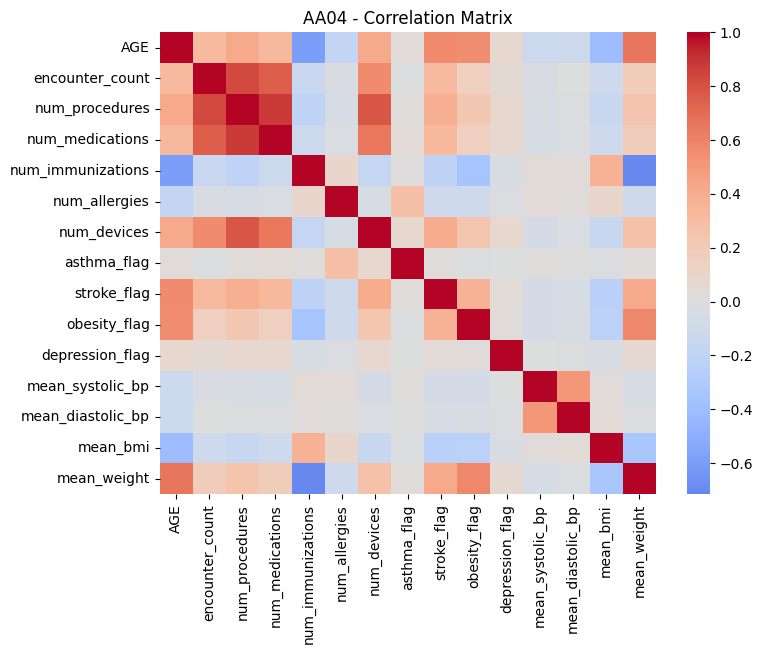

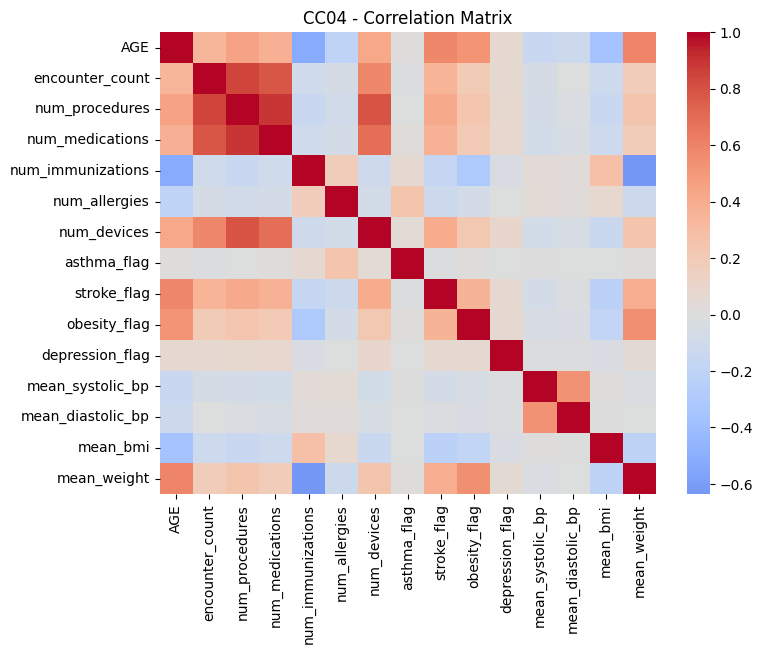

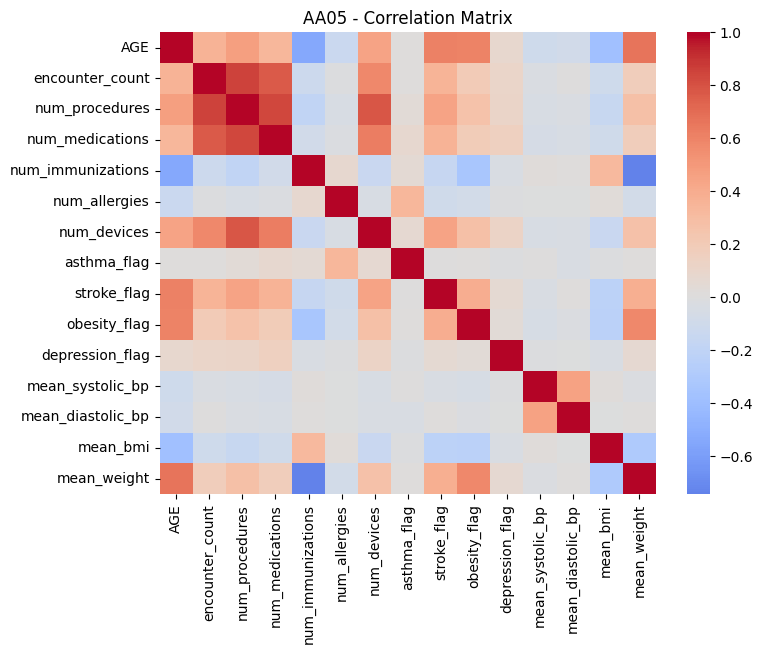

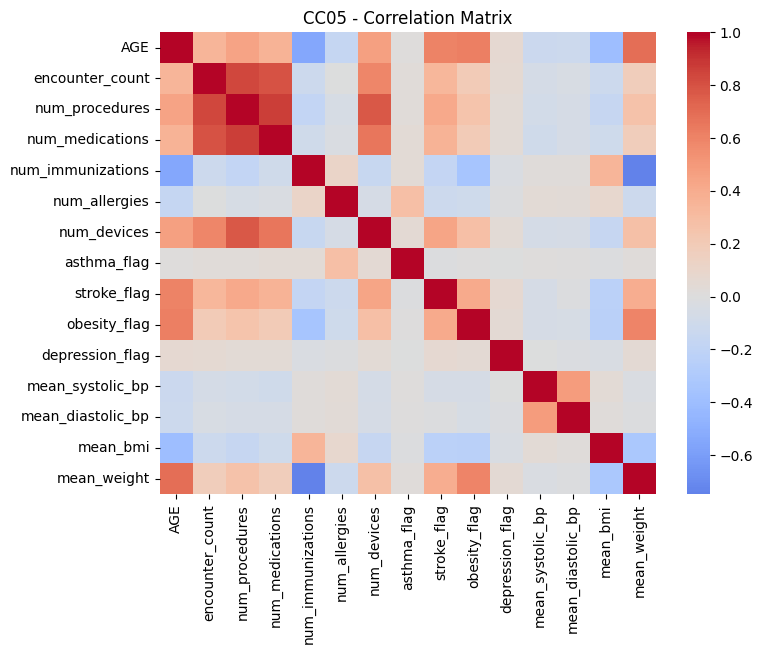

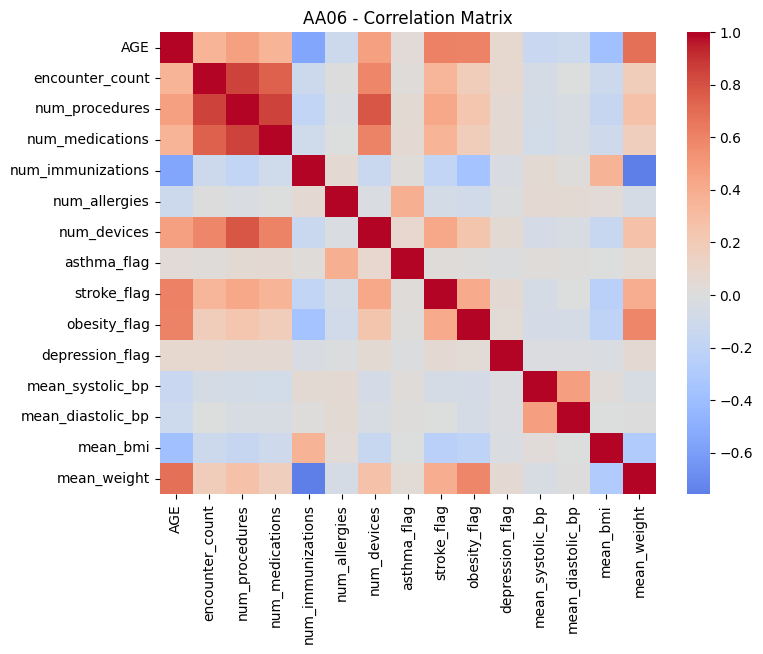

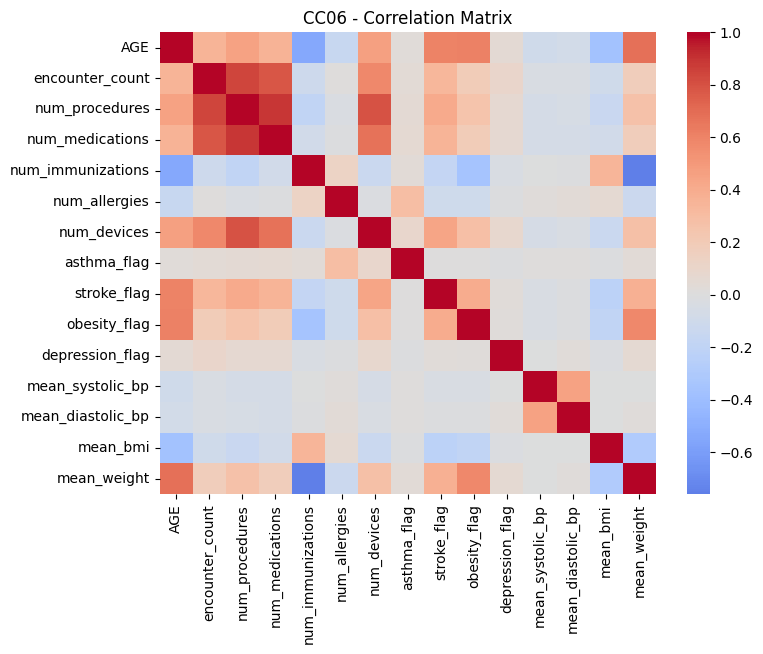

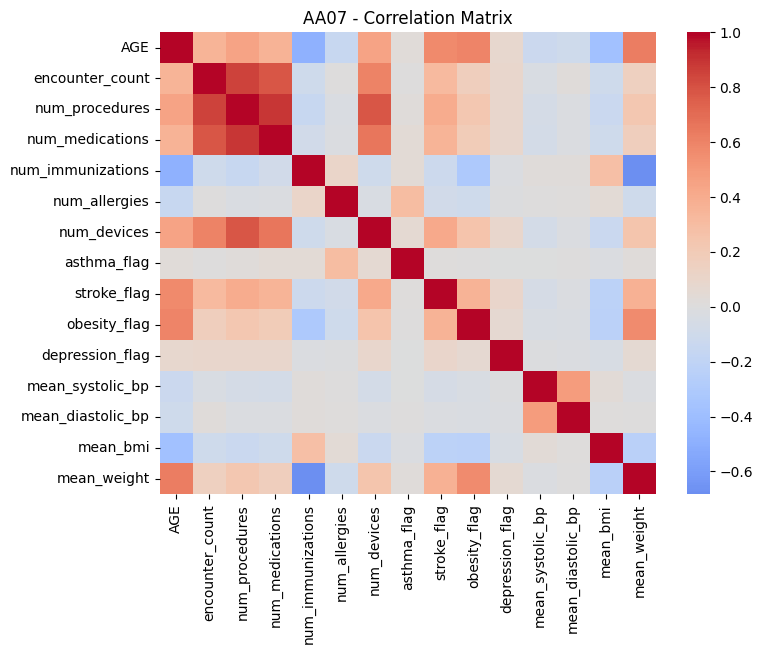

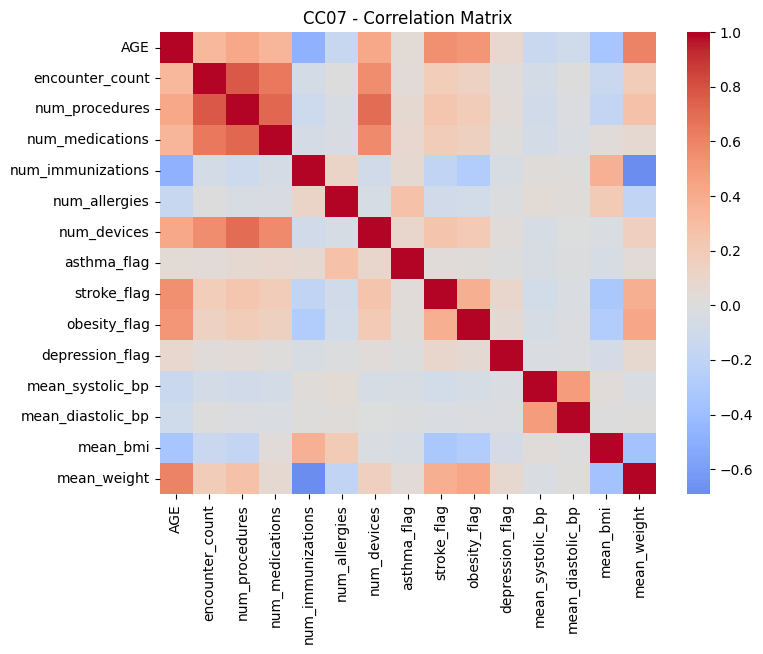

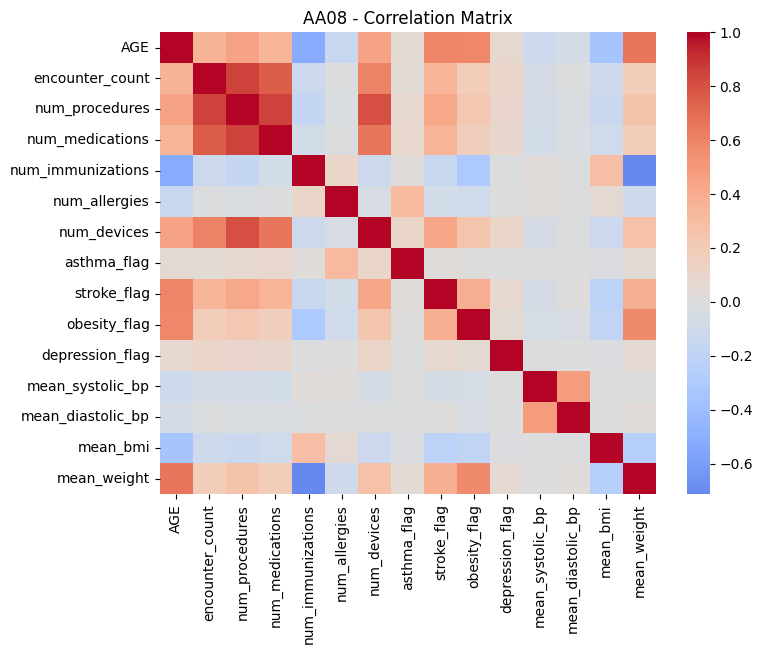

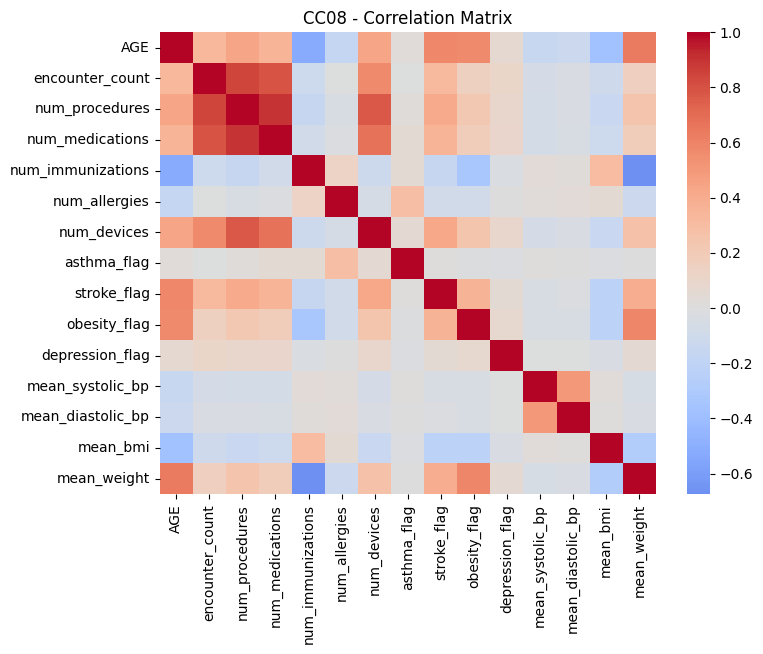

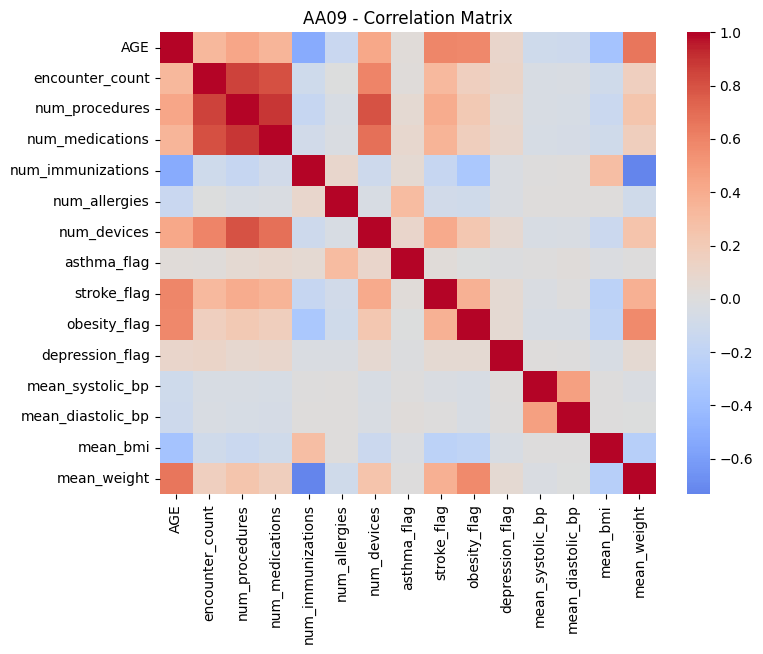

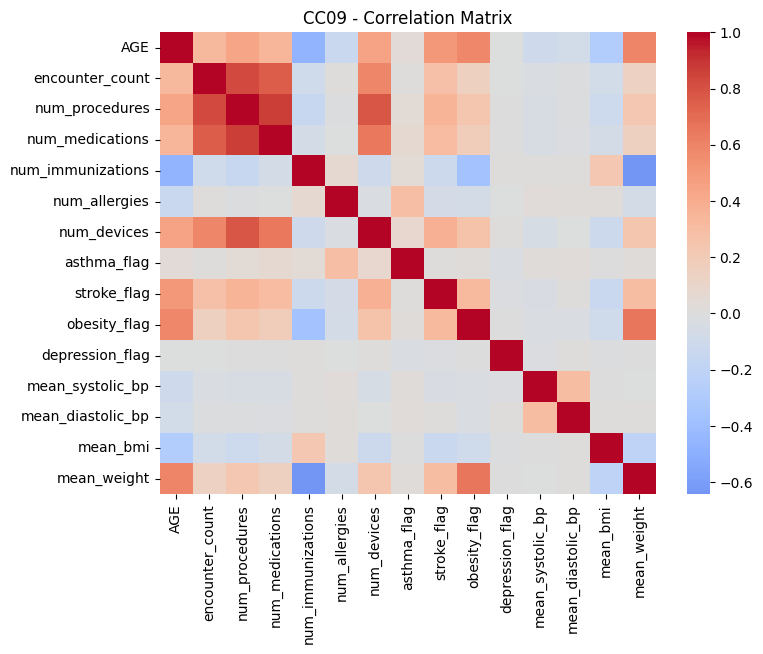

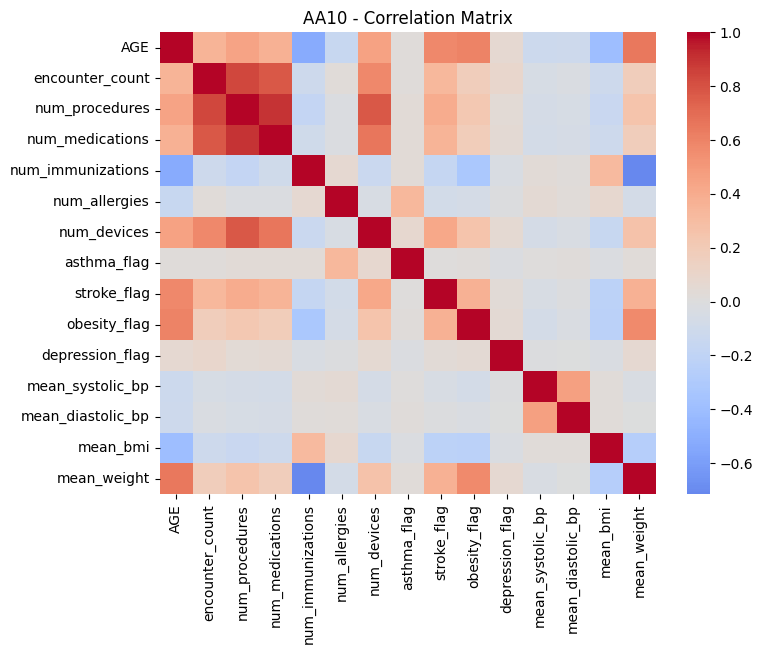

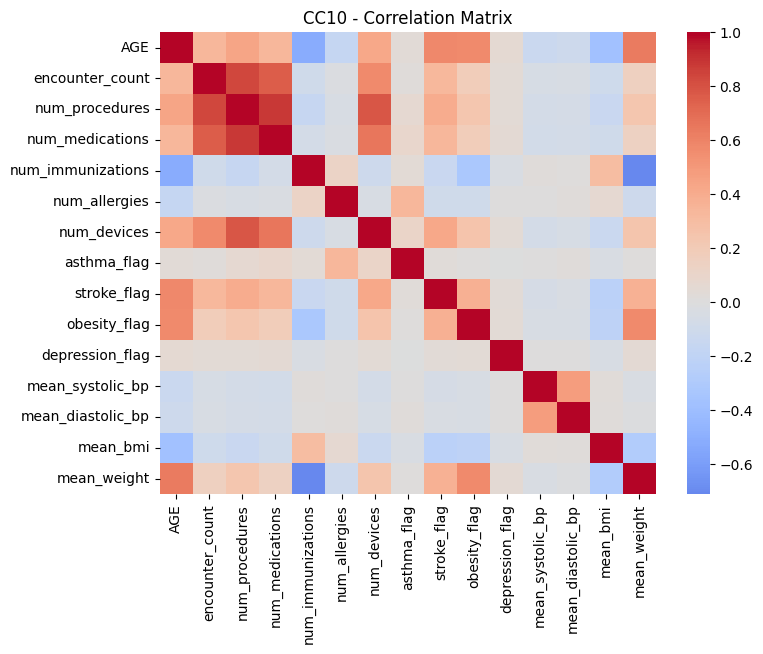

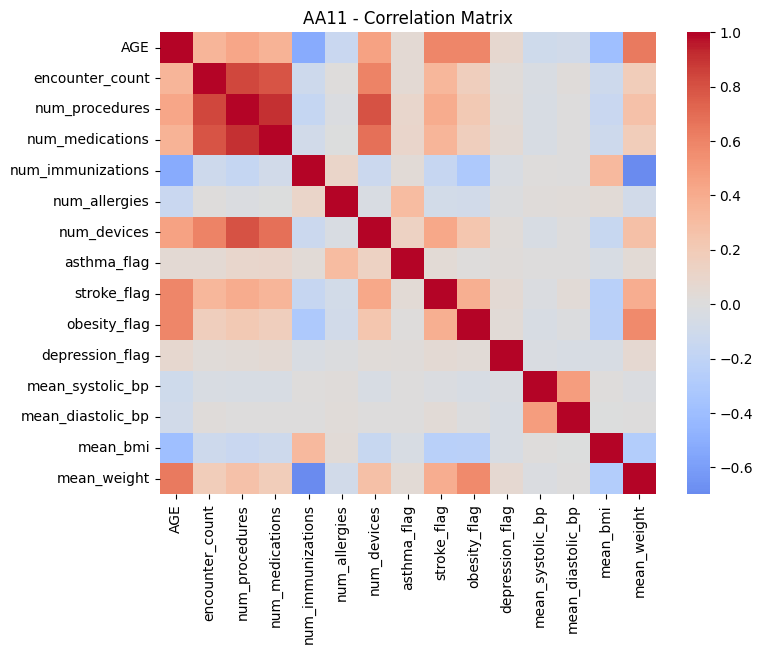

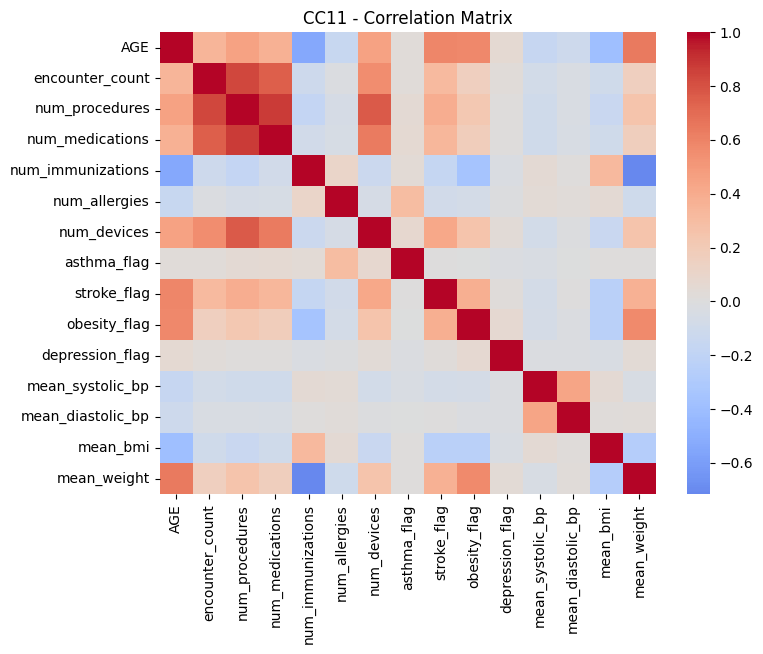

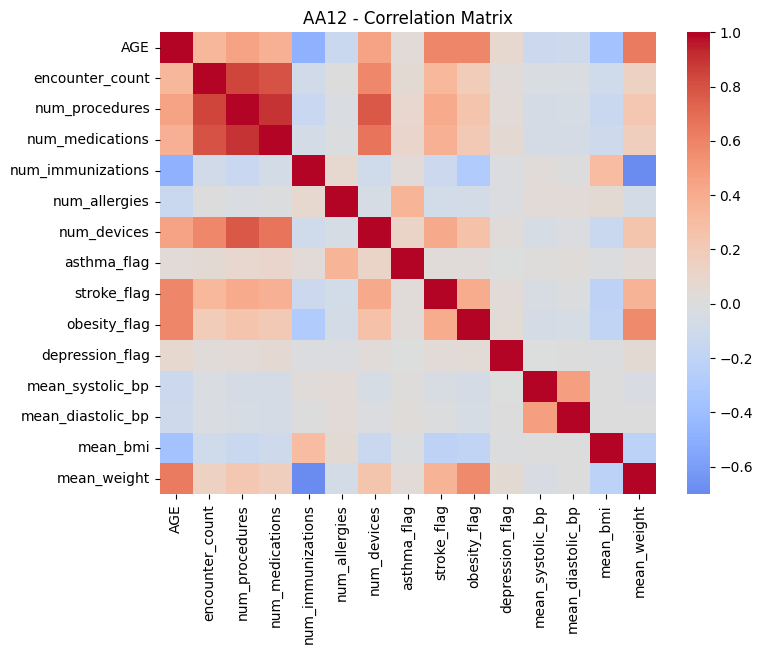

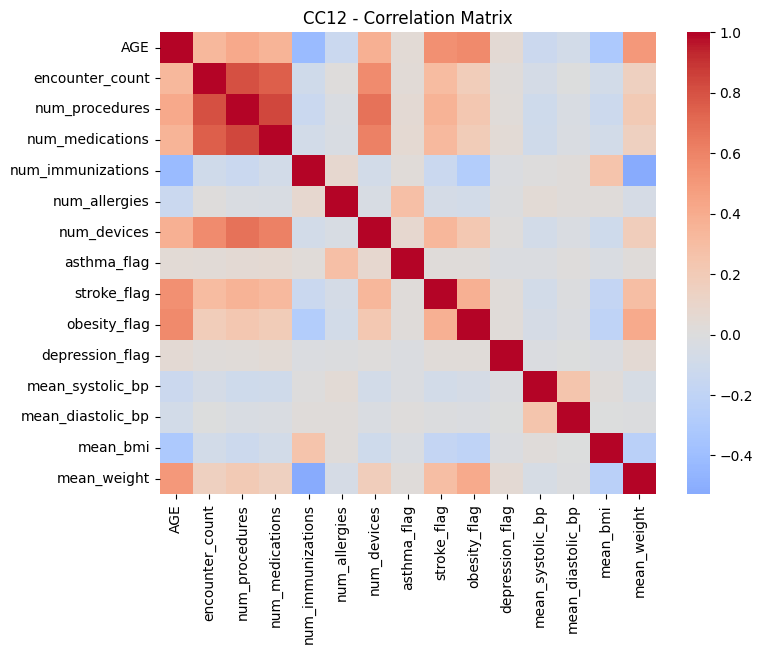

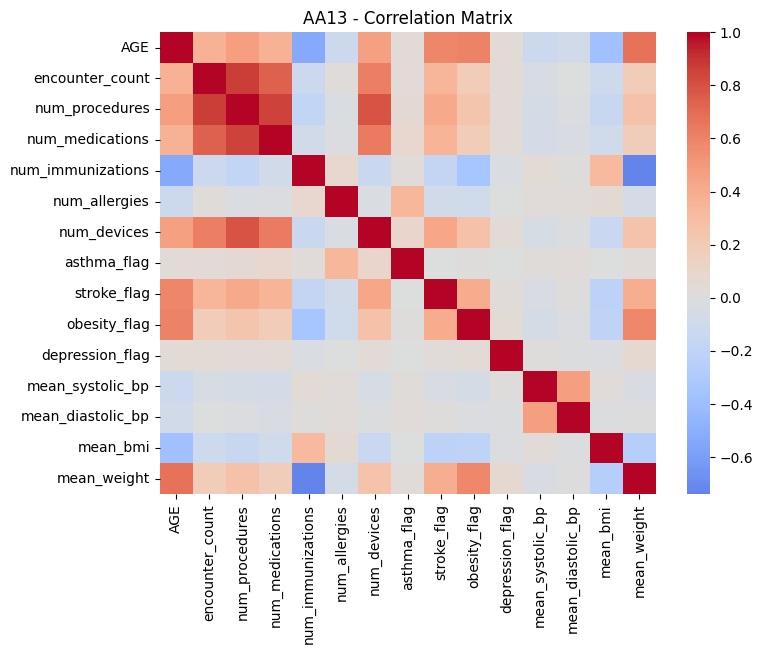

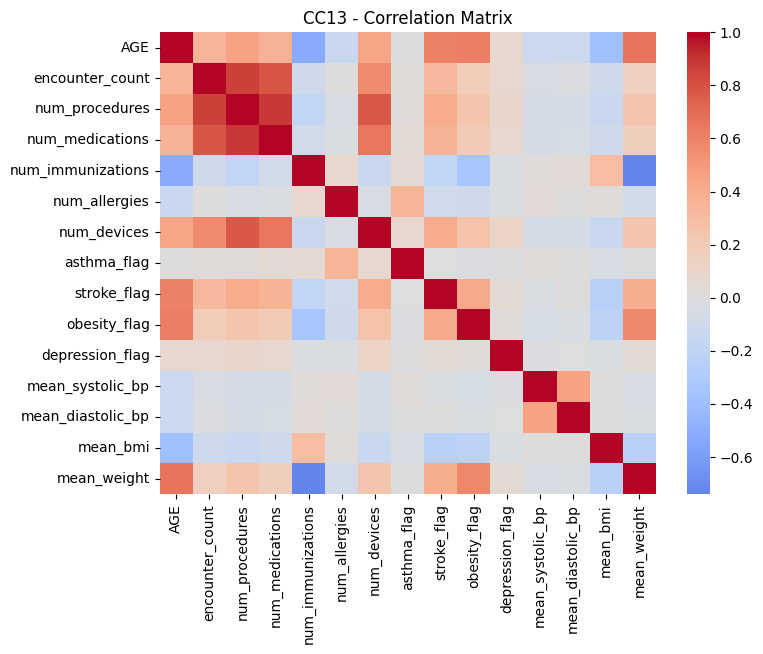

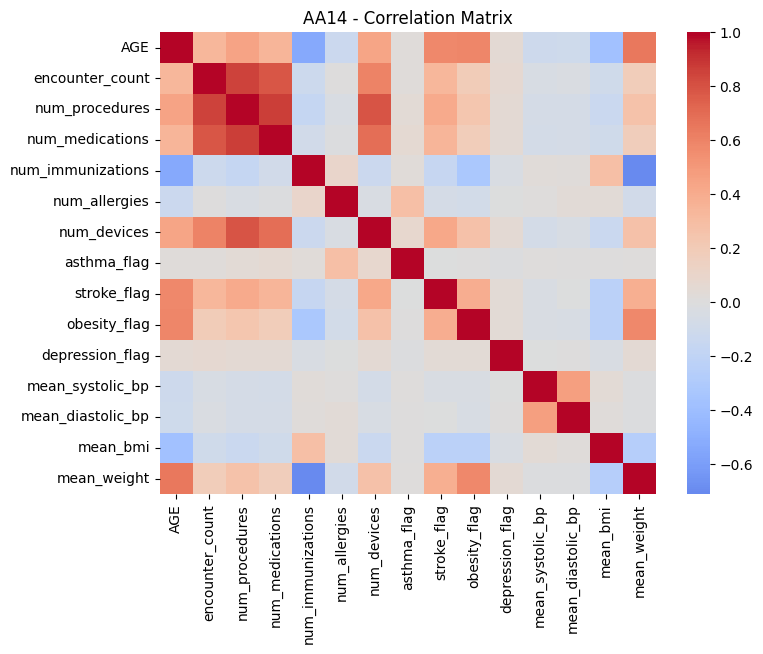

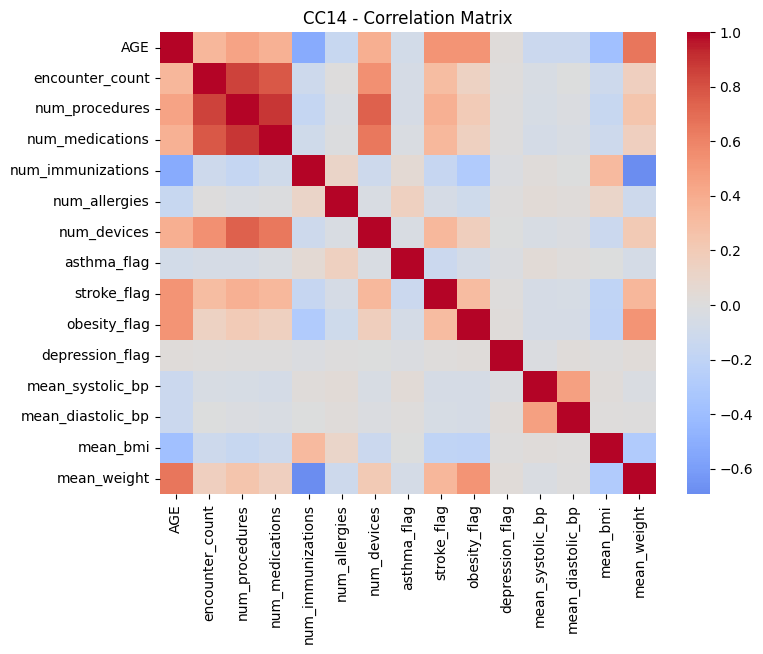

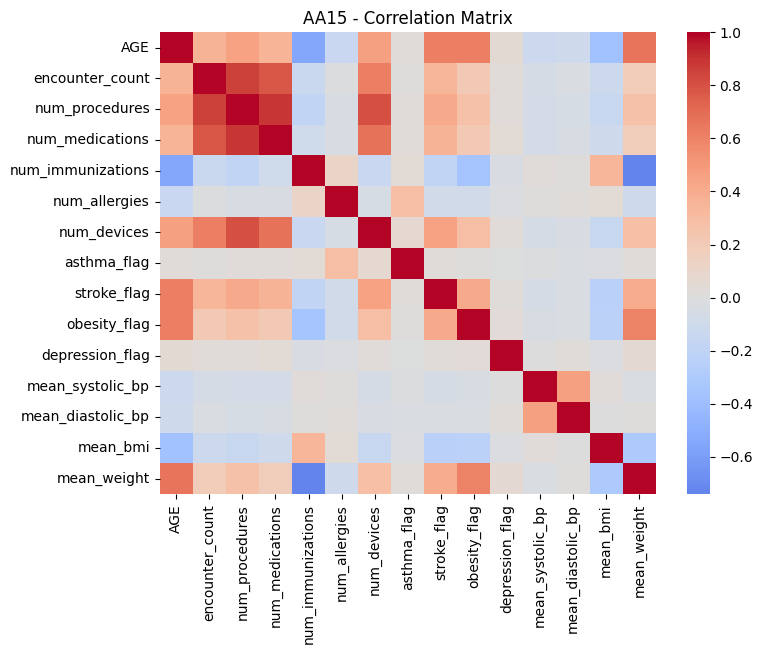

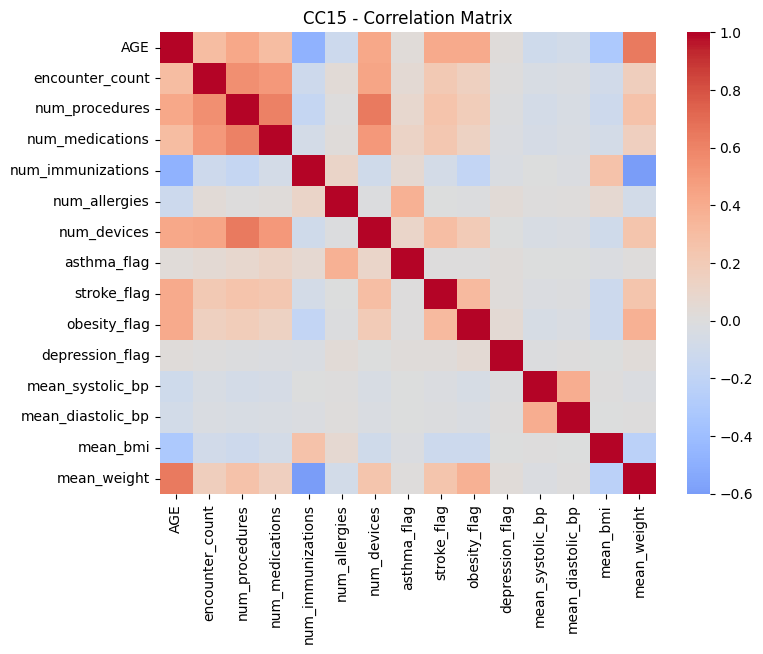

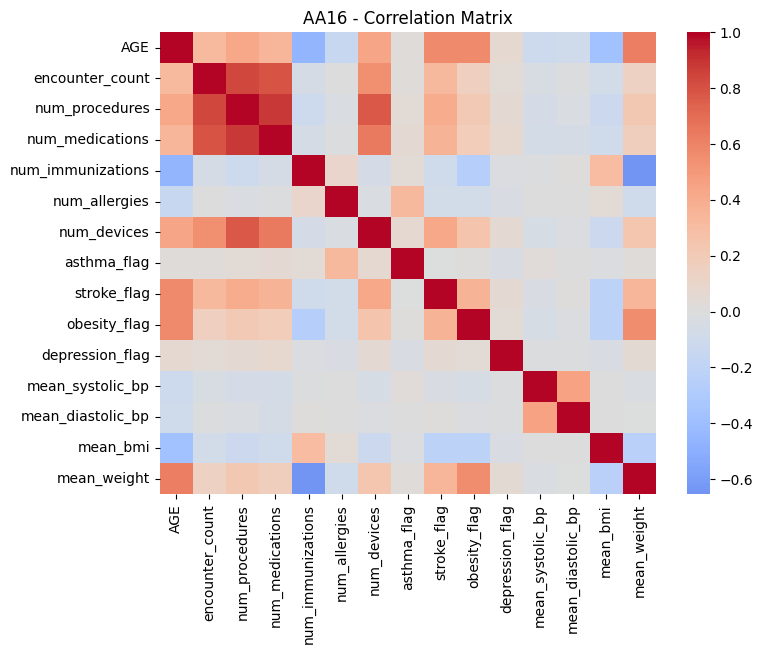

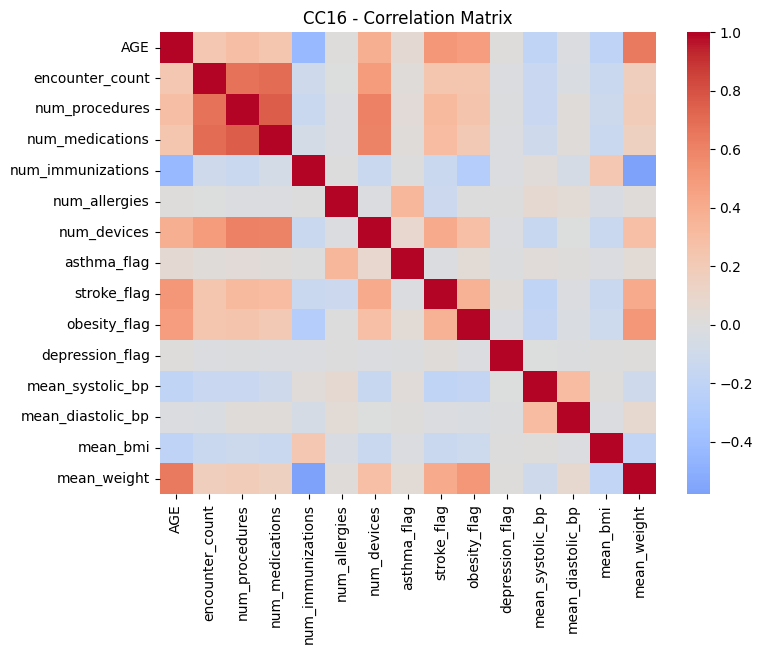

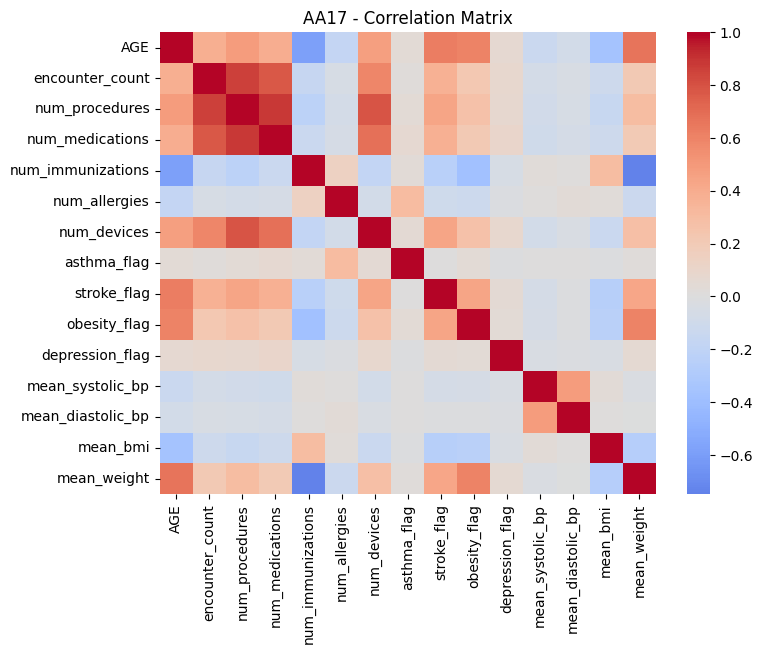

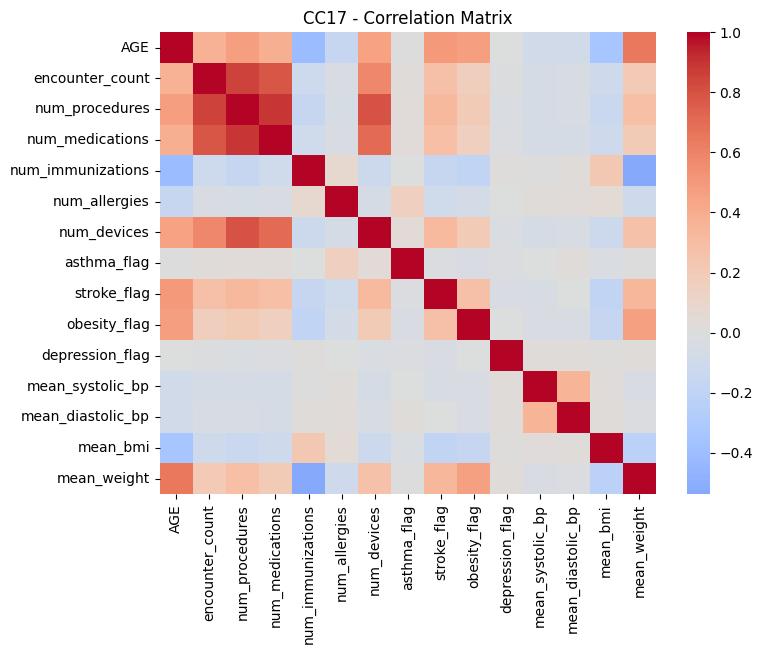

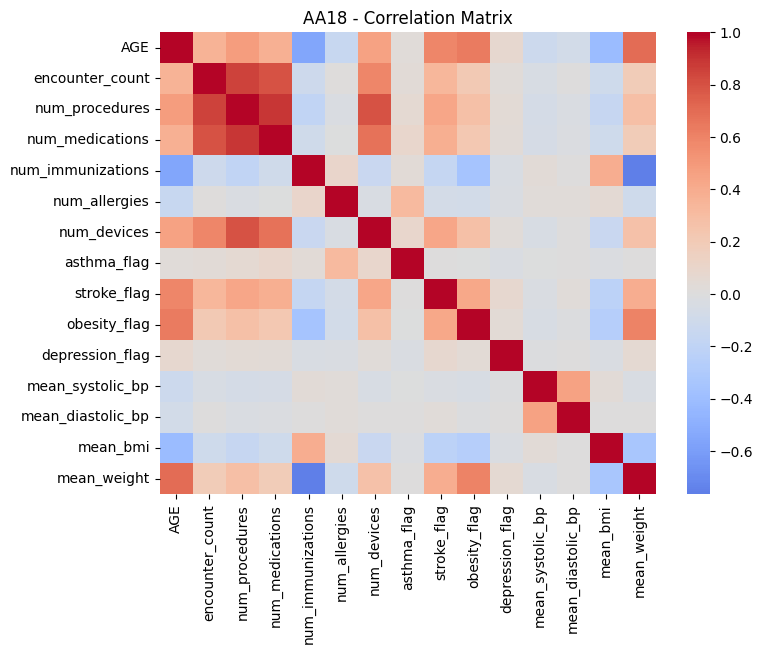

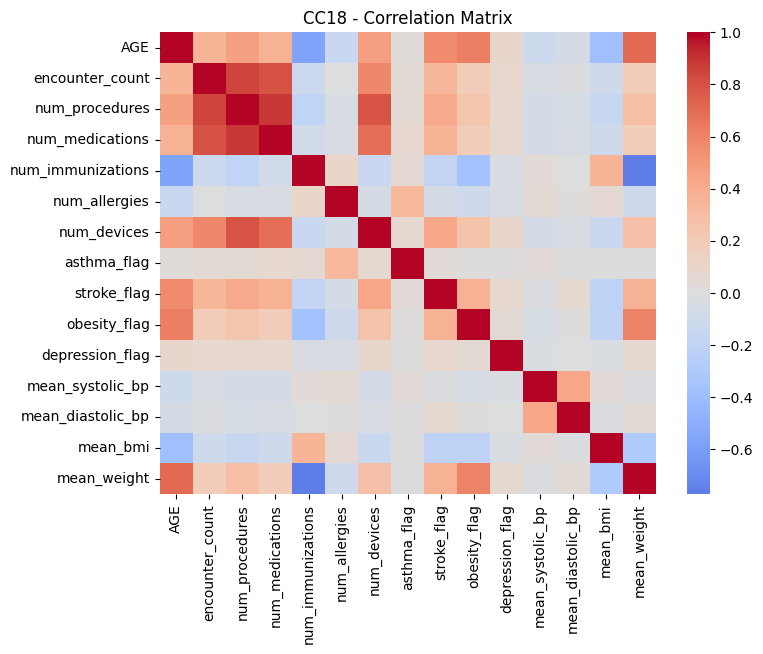

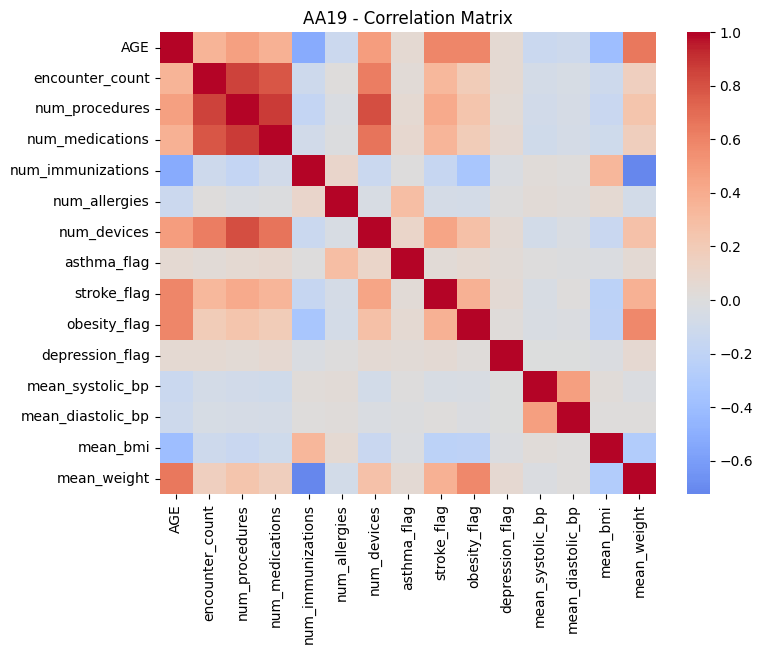

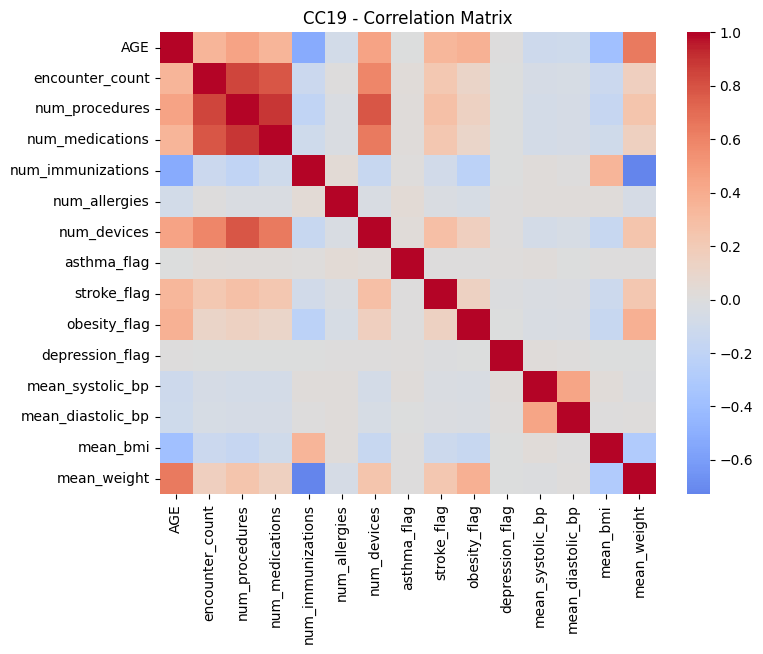

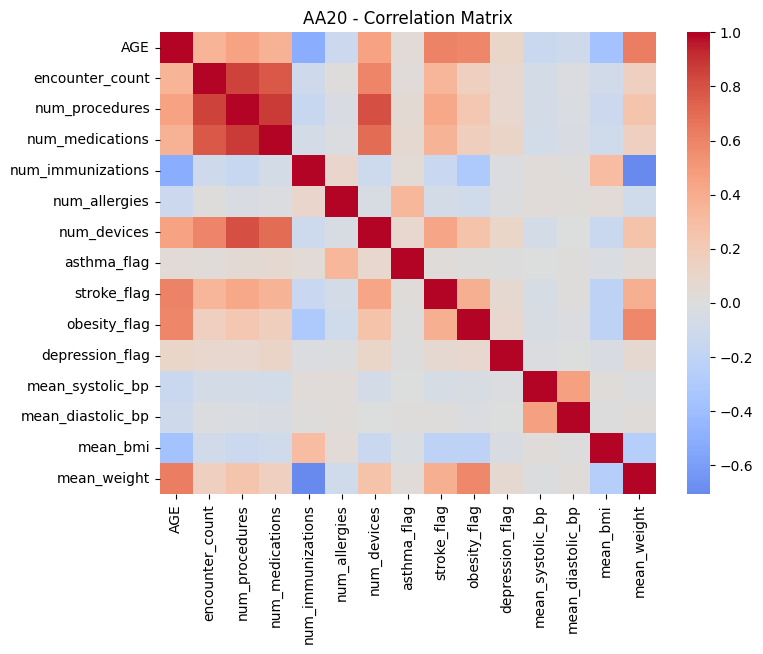

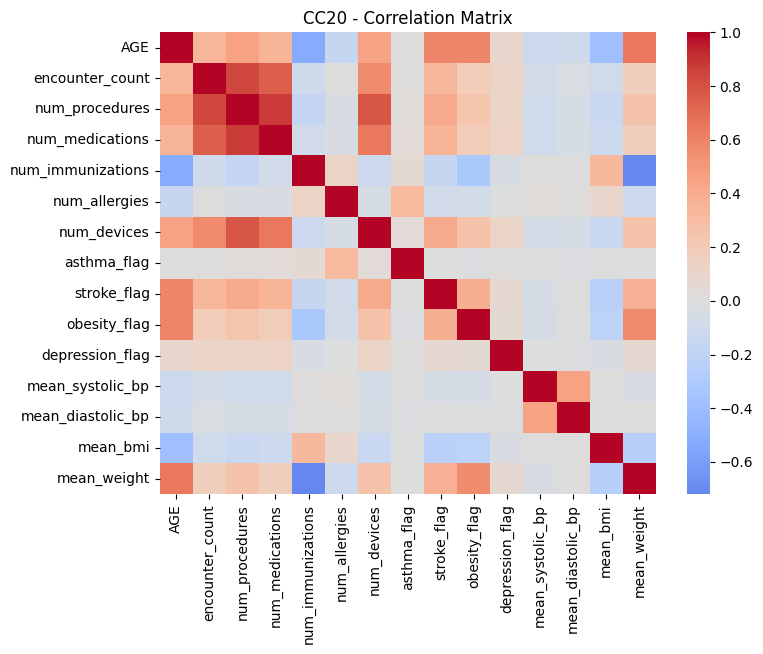

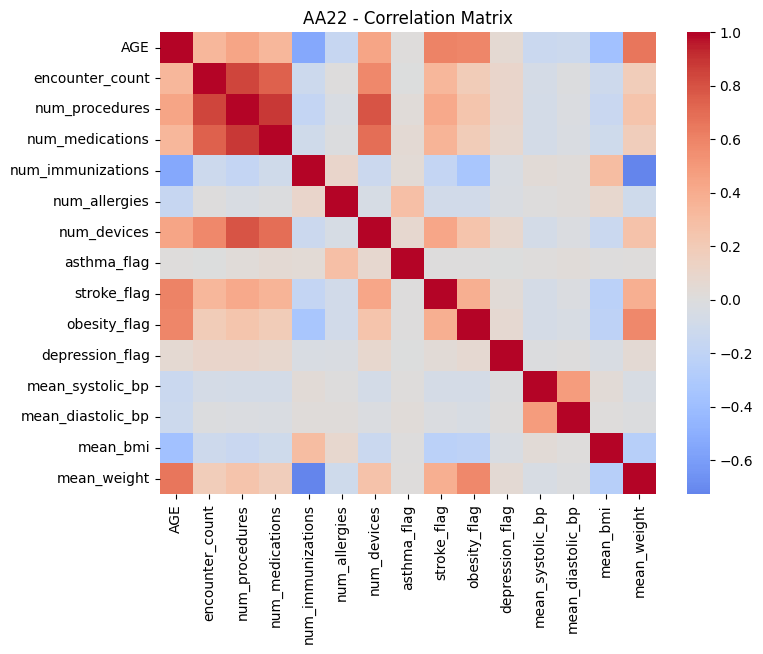

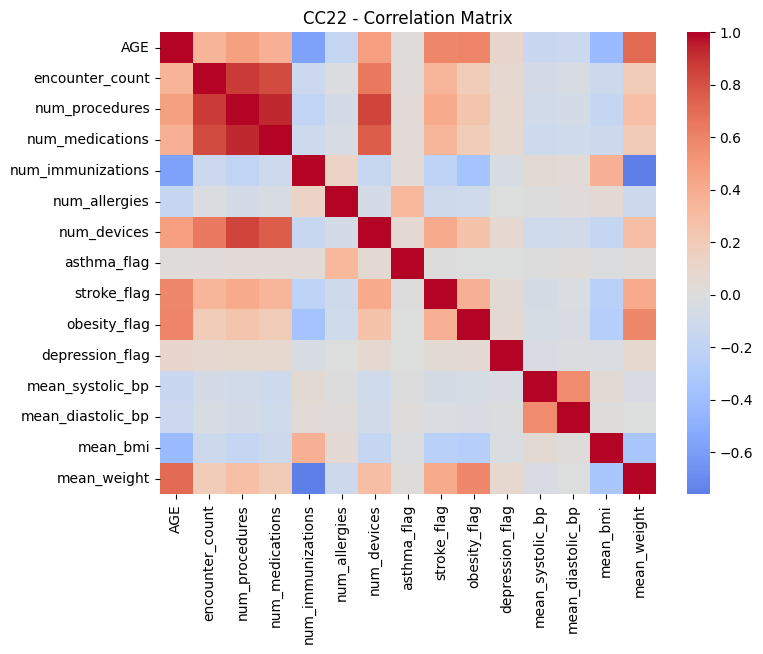

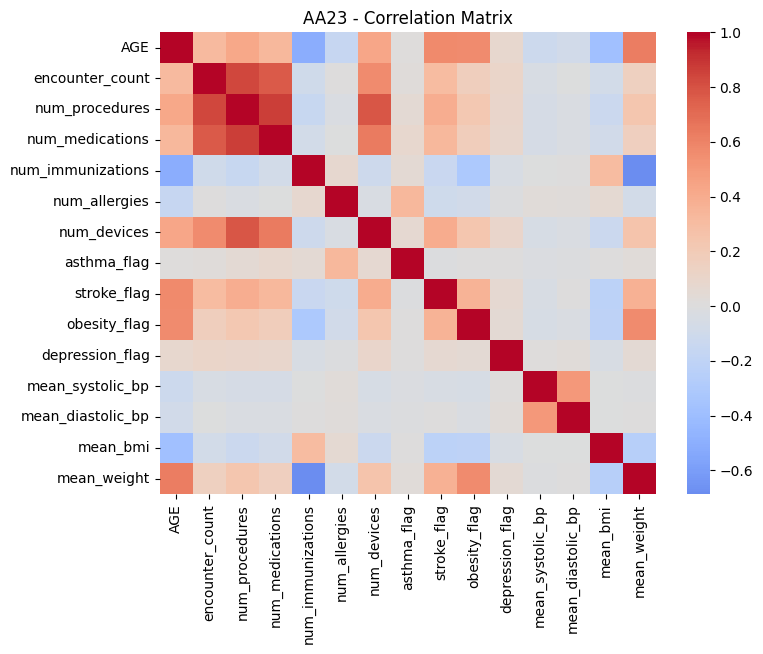

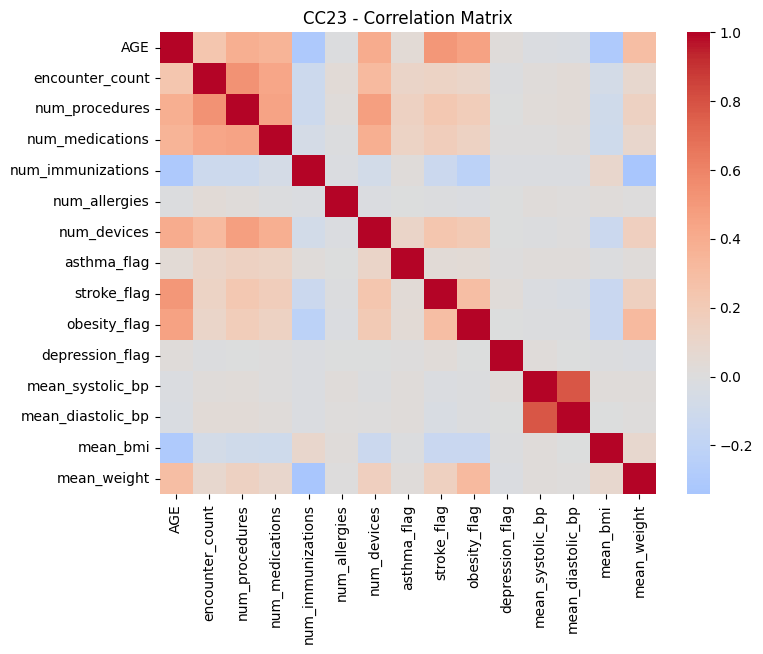

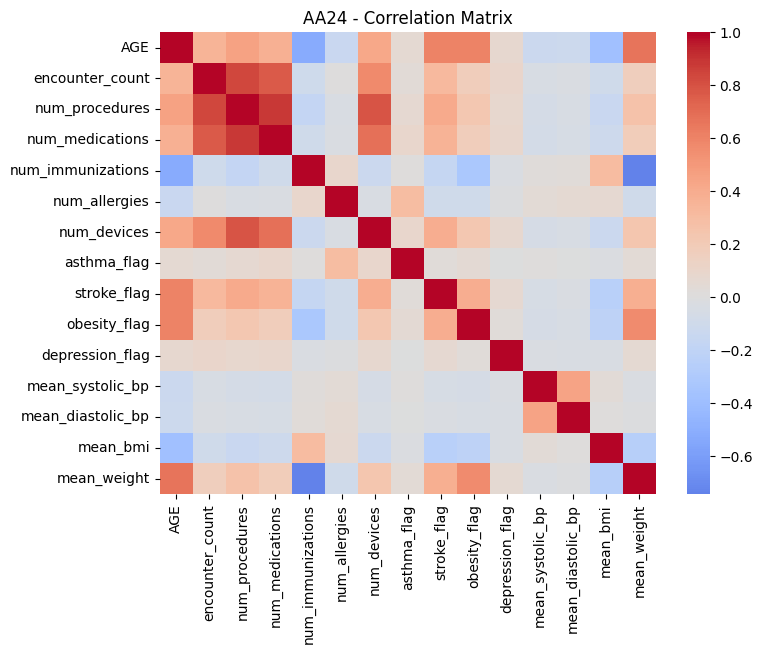

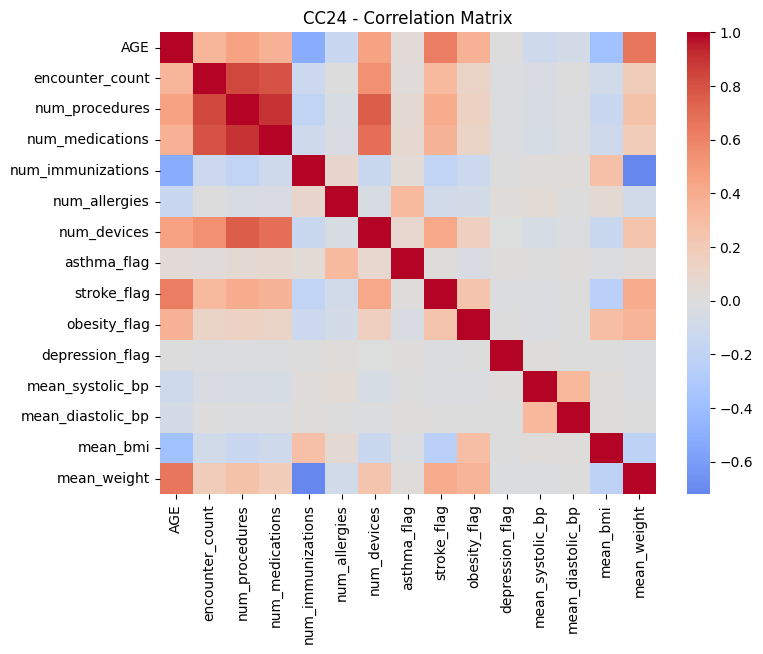

In [6]:
# %% 2. 相関構造の比較
for (name_aa, name_cc), (df_aa, df_cc) in zip(dataset_names, datasets):
    corr_aa = df_aa.corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_aa, annot=False, cmap="coolwarm", center=0)
    plt.title(f"{name_aa} - Correlation Matrix")
    plt.show()

    corr_cc = df_cc.corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_cc, annot=False, cmap="coolwarm", center=0)
    plt.title(f"{name_cc} - Correlation Matrix")
    plt.show()


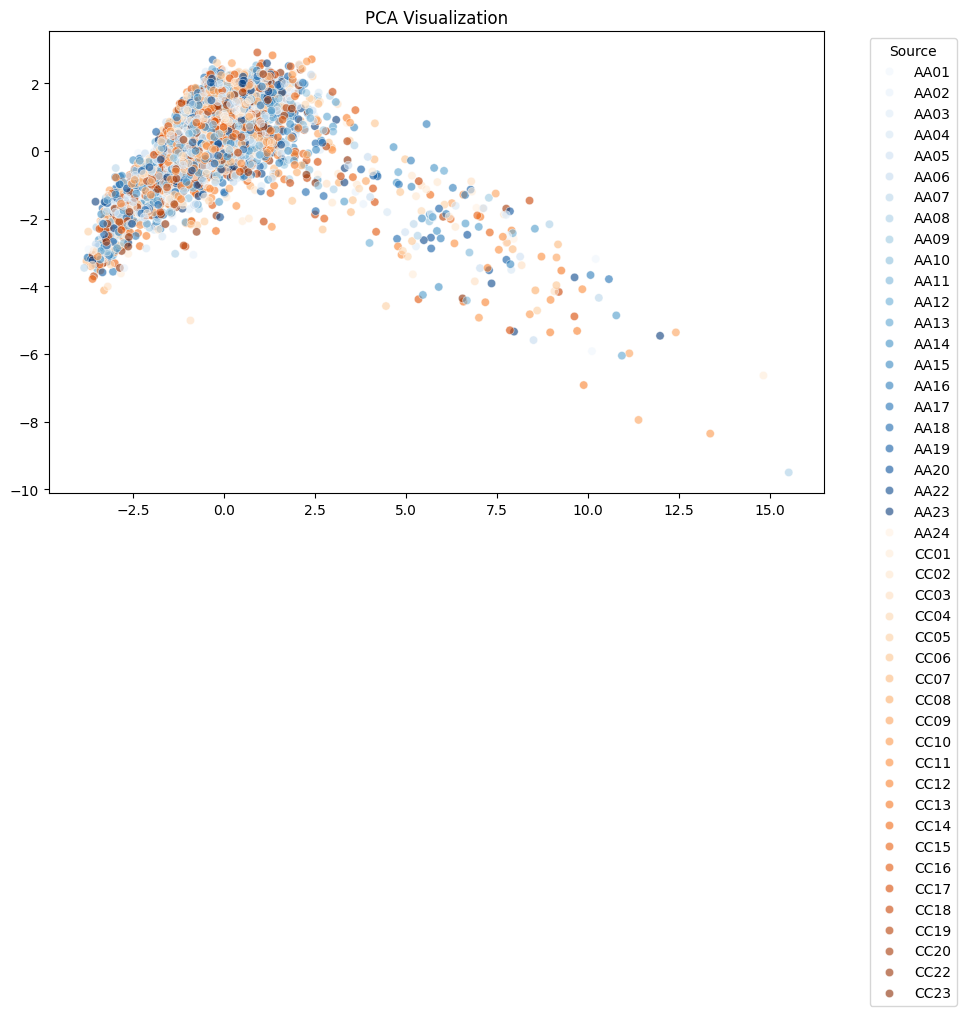

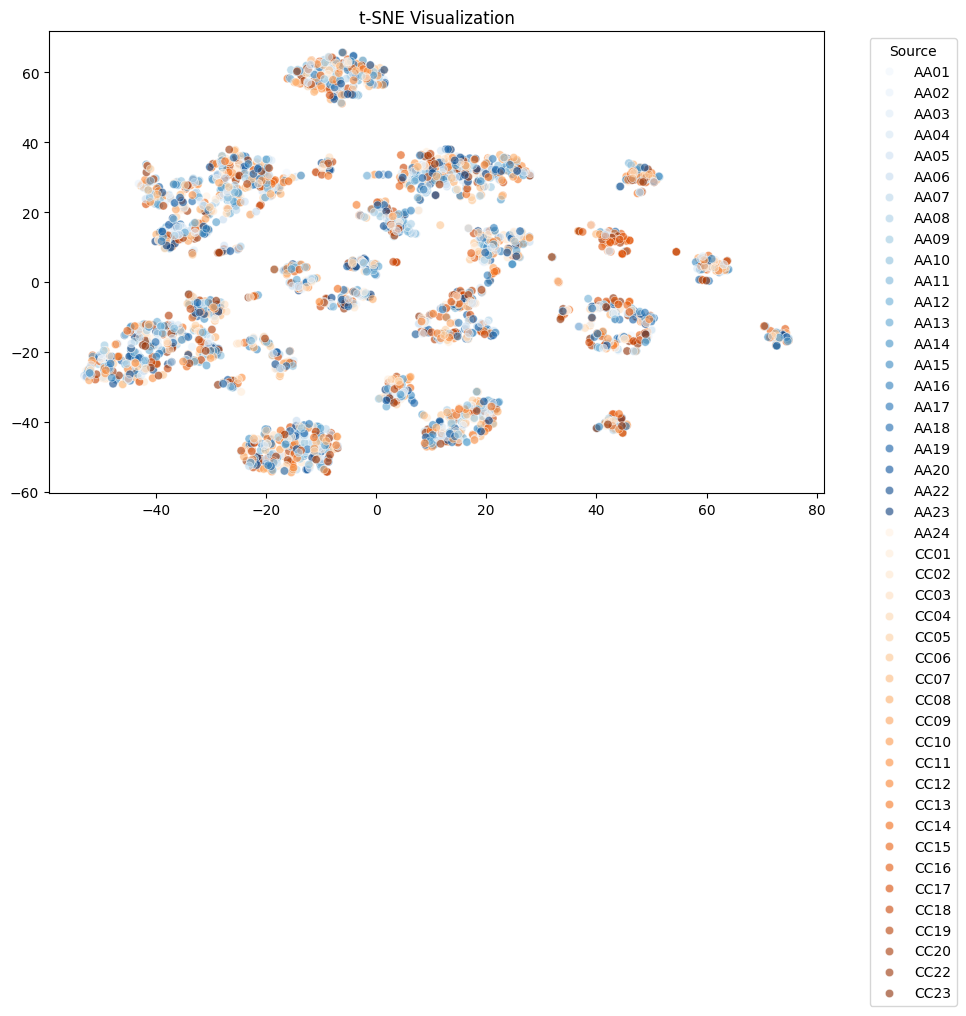

In [15]:
# %% 3. 次元削減による可視化 (PCA, t-SNE)
combined = []
combined_names = []
for (name_aa, name_cc), (df_aa, df_cc) in zip(dataset_names, datasets):
    temp_aa = df_aa.copy()
    temp_aa["source"] = name_aa
    temp_cc = df_cc.copy()
    temp_cc["source"] = name_cc
    combined.append(temp_aa)
    combined.append(temp_cc)
    combined_names.extend([name_aa, name_cc])
combined_df = pd.concat(combined, ignore_index=True)

feature_df = combined_df.drop(columns=["source"])
encoded_df = pd.get_dummies(feature_df, drop_first=False)
if encoded_df.empty:
    raise ValueError("特徴量が存在しません。入力データを確認してください。")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(encoded_df)
y = combined_df["source"]

rng = np.random.default_rng(42)
viz_sample_size = min(3000, X_scaled.shape[0])
if viz_sample_size < X_scaled.shape[0]:
    sample_idx = rng.choice(X_scaled.shape[0], viz_sample_size, replace=False)
else:
    sample_idx = np.arange(X_scaled.shape[0])

X_viz = X_scaled[sample_idx]
y_viz = y.iloc[sample_idx].reset_index(drop=True)

# legend順を番号順にするためのソート
def sort_names(names):
    def key_func(name):
        # AA/CCの後ろの数字部分を抽出してint化
        prefix = name[:2]
        num = int(name[2:]) if name[2:].isdigit() else 0
        return (prefix, num)
    return sorted(names, key=key_func)

palette = get_palette(combined_names)
sorted_labels = sort_names(list(set(y_viz)))

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_viz)
plt.figure(figsize=(10,6))
ax = sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_viz, alpha=0.6, palette=palette)
handles, labels = ax.get_legend_handles_labels()
# sorted_labelsに従ってlegendを並べ替え
label_to_handle = dict(zip(labels[1:], handles[1:]))  # [0]はタイトル
sorted_handles = [label_to_handle[l] for l in sorted_labels if l in label_to_handle]
plt.legend(sorted_handles, sorted_labels, title="Source", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("PCA Visualization")
plt.show()

# t-SNE
perplexity = min(30, max(5, viz_sample_size - 1))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X_viz)
plt.figure(figsize=(10,6))
ax = sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_viz, alpha=0.6, palette=palette)
handles, labels = ax.get_legend_handles_labels()
label_to_handle = dict(zip(labels[1:], handles[1:]))
sorted_handles = [label_to_handle[l] for l in sorted_labels if l in label_to_handle]
plt.legend(sorted_handles, sorted_labels, title="Source", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("t-SNE Visualization")
plt.show()


In [8]:
# # %% 4. 判別モデルによる識別精度
# clf = RandomForestClassifier(n_estimators=200, random_state=42)
# scores = cross_val_score(clf, X_scaled, y, cv=5, scoring="accuracy")
# print("\n=== 判別モデル精度 ===")
# print(f"平均精度: {scores.mean():.3f} (± {scores.std():.3f})")
# print("※ 精度が低ければ区別できない → データの特徴は類似")


In [9]:
# %% 5. 統計的検定
print("=== 分布の統計的検定 ===")
for (name_aa, name_cc), (df_aa, df_cc) in zip(dataset_names, datasets):
    print(f"\n--- {name_aa} vs {name_cc} ---")
    numeric_cols = df_aa.select_dtypes(include=[np.number]).columns.intersection(df_cc.select_dtypes(include=[np.number]).columns)
    for col in numeric_cols:
        data_aa = df_aa[col].dropna()
        data_cc = df_cc[col].dropna()
        if data_aa.empty or data_cc.empty:
            continue
        stat, pval = ks_2samp(data_aa, data_cc)
        print(f"{col}: KS検定 p={pval:.4f}")

    categorical_cols = df_aa.select_dtypes(include=["object", "category"]).columns.intersection(df_cc.select_dtypes(include=["object", "category"]).columns)
    for col in categorical_cols:
        combined = pd.concat([df_aa[col], df_cc[col]], ignore_index=True)
        labels = ["AA"] * len(df_aa[col]) + ["CC"] * len(df_cc[col])
        contingency = pd.crosstab(combined, labels)
        if contingency.empty:
            continue
        chi2, pval, _, _ = chi2_contingency(contingency)
        print(f"{col}: カイ二乗検定 p={pval:.4f}")

# （高度な手法）MMDによる分布差の測定 (RBFカーネル)
def mmd(X1, X2, gamma=1.0):
    XX = np.exp(-gamma * np.square(np.linalg.norm(X1[:,None]-X1[None,:], axis=2))).mean()
    YY = np.exp(-gamma * np.square(np.linalg.norm(X2[:,None]-X2[None,:], axis=2))).mean()
    XY = np.exp(-gamma * np.square(np.linalg.norm(X1[:,None]-X2[None,:], axis=2))).mean()
    return XX + YY - 2*XY

def sample_subset(arr, size, rng):
    if len(arr) > size:
        idx = rng.choice(len(arr), size, replace=False)
        return arr[idx]
    return arr

rng = np.random.default_rng(42)
mmd_sample_size = 500

print("=== MMDによる分布距離（AA** vs CC**ペアのみ）===")
for (name_aa, name_cc) in dataset_names:
    mask_aa = (y == name_aa).to_numpy()
    mask_cc = (y == name_cc).to_numpy()
    X_aa = sample_subset(X_scaled[mask_aa], mmd_sample_size, rng)
    X_cc = sample_subset(X_scaled[mask_cc], mmd_sample_size, rng)
    if len(X_aa) == 0 or len(X_cc) == 0:
        continue
    val = mmd(X_aa, X_cc)
    print(f"{name_aa} vs {name_cc}: MMD={val:.4f}")

=== 分布の統計的検定 ===

--- AA01 vs CC01 ---
AGE: KS検定 p=0.0001
encounter_count: KS検定 p=0.0018
num_procedures: KS検定 p=0.0004
num_medications: KS検定 p=0.0316
num_immunizations: KS検定 p=0.1294
num_allergies: KS検定 p=0.9874
num_devices: KS検定 p=0.9926
asthma_flag: KS検定 p=0.9229
stroke_flag: KS検定 p=1.0000
obesity_flag: KS検定 p=1.0000
depression_flag: KS検定 p=1.0000
mean_systolic_bp: KS検定 p=0.0265
mean_diastolic_bp: KS検定 p=0.9325
mean_bmi: KS検定 p=0.0420
mean_weight: KS検定 p=0.0031
GENDER: カイ二乗検定 p=0.0277
RACE: カイ二乗検定 p=0.0000
ETHNICITY: カイ二乗検定 p=0.0004

--- AA02 vs CC02 ---
AGE: KS検定 p=0.1701
encounter_count: KS検定 p=0.3928
num_procedures: KS検定 p=0.4807
num_medications: KS検定 p=0.3399
num_immunizations: KS検定 p=0.6441
num_allergies: KS検定 p=0.1123
num_devices: KS検定 p=0.6609
asthma_flag: KS検定 p=0.8643
stroke_flag: KS検定 p=1.0000
obesity_flag: KS検定 p=0.9700
depression_flag: KS検定 p=1.0000
mean_systolic_bp: KS検定 p=0.5280
mean_diastolic_bp: KS検定 p=0.1294
mean_bmi: KS検定 p=0.0081
mean_weight: KS検定 p=0.1939
GENDER: 

c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


GENDER: カイ二乗検定 p=0.5754
RACE: カイ二乗検定 p=0.0019
ETHNICITY: カイ二乗検定 p=0.0001

--- AA06 vs CC06 ---
AGE: KS検定 p=0.3399
encounter_count: KS検定 p=0.3036
num_procedures: KS検定 p=0.3527
num_medications: KS検定 p=0.0000
num_immunizations: KS検定 p=0.0000
num_allergies: KS検定 p=0.0836
num_devices: KS検定 p=0.0000
asthma_flag: KS検定 p=1.0000
stroke_flag: KS検定 p=0.9700
obesity_flag: KS検定 p=0.9753
depression_flag: KS検定 p=1.0000
mean_systolic_bp: KS検定 p=0.9014
mean_diastolic_bp: KS検定 p=0.5442
mean_bmi: KS検定 p=0.1701
mean_weight: KS検定 p=0.7279
GENDER: カイ二乗検定 p=0.6312
RACE: カイ二乗検定 p=0.5237
ETHNICITY: カイ二乗検定 p=0.7017

--- AA07 vs CC07 ---
AGE: KS検定 p=0.6104
encounter_count: KS検定 p=0.9874
num_procedures: KS検定 p=0.7605
num_medications: KS検定 p=0.6609
num_immunizations: KS検定 p=0.5120
num_allergies: KS検定 p=1.0000
num_devices: KS検定 p=0.7921
asthma_flag: KS検定 p=1.0000
stroke_flag: KS検定 p=1.0000
obesity_flag: KS検定 p=1.0000
depression_flag: KS検定 p=1.0000
mean_systolic_bp: KS検定 p=0.4210
mean_diastolic_bp: KS検定 p=0.4355
mea

c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: Run

GENDER: カイ二乗検定 p=0.3681
RACE: カイ二乗検定 p=0.0000
ETHNICITY: カイ二乗検定 p=0.0149

--- AA11 vs CC11 ---
AGE: KS検定 p=0.0000
encounter_count: KS検定 p=0.2392
num_procedures: KS検定 p=0.0154
num_medications: KS検定 p=0.7605
num_immunizations: KS検定 p=0.0105
num_allergies: KS検定 p=0.9014
num_devices: KS検定 p=0.0924
asthma_flag: KS検定 p=0.8223
stroke_flag: KS検定 p=0.9960
obesity_flag: KS検定 p=0.8508
depression_flag: KS検定 p=1.0000
mean_systolic_bp: KS検定 p=0.6609
mean_diastolic_bp: KS検定 p=0.4962
mean_bmi: KS検定 p=0.4503
mean_weight: KS検定 p=0.2392
GENDER: カイ二乗検定 p=0.3368
RACE: カイ二乗検定 p=0.0000
ETHNICITY: カイ二乗検定 p=0.0000

--- AA12 vs CC12 ---
AGE: KS検定 p=0.0000
encounter_count: KS検定 p=0.0000
num_procedures: KS検定 p=0.0008
num_medications: KS検定 p=0.0000
num_immunizations: KS検定 p=0.0000
num_allergies: KS検定 p=1.0000
num_devices: KS検定 p=0.0007
asthma_flag: KS検定 p=1.0000
stroke_flag: KS検定 p=1.0000
obesity_flag: KS検定 p=0.9572
depression_flag: KS検定 p=1.0000
mean_systolic_bp: KS検定 p=0.0012
mean_diastolic_bp: KS検定 p=0.0098
mea

c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


ETHNICITY: カイ二乗検定 p=0.0000

--- AA16 vs CC16 ---
AGE: KS検定 p=0.0004
encounter_count: KS検定 p=0.0000
num_procedures: KS検定 p=0.0000
num_medications: KS検定 p=0.0000
num_immunizations: KS検定 p=0.0000
num_allergies: KS検定 p=0.0000
num_devices: KS検定 p=0.0000
asthma_flag: KS検定 p=0.0076
stroke_flag: KS検定 p=0.0000
obesity_flag: KS検定 p=0.8643
depression_flag: KS検定 p=0.9926
mean_systolic_bp: KS検定 p=0.0105
mean_diastolic_bp: KS検定 p=0.0000
mean_bmi: KS検定 p=0.0000
mean_weight: KS検定 p=0.0000
GENDER: カイ二乗検定 p=0.2300
RACE: カイ二乗検定 p=0.0000
ETHNICITY: カイ二乗検定 p=0.0000

--- AA17 vs CC17 ---
AGE: KS検定 p=0.5280
encounter_count: KS検定 p=0.3791
num_procedures: KS検定 p=0.2595
num_medications: KS検定 p=0.0000
num_immunizations: KS検定 p=0.0000
num_allergies: KS検定 p=0.0000
num_devices: KS検定 p=0.0000
asthma_flag: KS検定 p=0.0000
stroke_flag: KS検定 p=0.0924
obesity_flag: KS検定 p=0.9999
depression_flag: KS検定 p=0.0000
mean_systolic_bp: KS検定 p=0.0000
mean_diastolic_bp: KS検定 p=0.0000
mean_bmi: KS検定 p=0.0000
mean_weight: KS検定 p=0.339

c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


AA01 vs CC01: MMD=0.0041
AA02 vs CC02: MMD=0.0043
AA03 vs CC03: MMD=0.0047
AA04 vs CC04: MMD=0.0051
AA05 vs CC05: MMD=0.0040
AA06 vs CC06: MMD=0.0042
AA07 vs CC07: MMD=0.0047
AA08 vs CC08: MMD=0.0040
AA09 vs CC09: MMD=0.0062
AA10 vs CC10: MMD=0.0041
AA11 vs CC11: MMD=0.0042
AA12 vs CC12: MMD=0.0043
AA13 vs CC13: MMD=0.0041
AA14 vs CC14: MMD=0.0046
AA15 vs CC15: MMD=0.0048
AA16 vs CC16: MMD=0.0047
AA17 vs CC17: MMD=0.0048
AA18 vs CC18: MMD=0.0041
AA19 vs CC19: MMD=0.0058
AA20 vs CC20: MMD=0.0041
AA22 vs CC22: MMD=0.0041
AA23 vs CC23: MMD=0.0052
AA24 vs CC24: MMD=0.0046
